#### Bag-of-Words representation

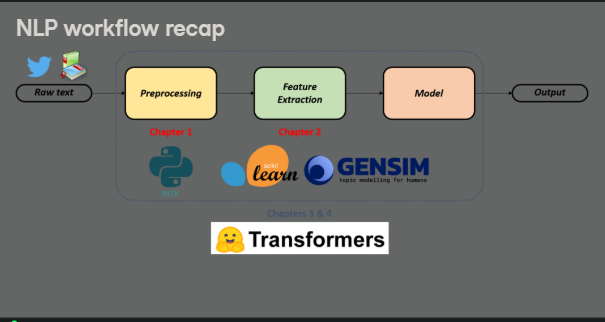

### Bag-of-Words (BoW)
- Foundational technique to represent text as numbers
- Represent text by counting how often each words appears
- Throws words in a bag and counts them
- Ignore grammar and order

BoW example
- Build a vocabulary of all unique words
- Count how many times each word from the vocabulary appears

BoW with code

In [3]:
from nltk import word_tokenize
import string
reviews = ["I love the movie. It was amazing!",
"The movies was okeay.",
"I hated the movie. It was boring."]

def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in string.punctuation]
    return " ".join(tokens)

cleaned_reviews = [preprocess(review) for review in reviews]
print(cleaned_reviews)

['i love the movie it was amazing', 'the movies was okeay', 'i hated the movie it was boring']


In [4]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
vectorizer.fit(cleaned_reviews)
print(vectorizer.get_feature_names_out())

['amazing' 'boring' 'hated' 'it' 'love' 'movie' 'movies' 'okeay' 'the'
 'was']


In [5]:
X = vectorizer.transform(cleaned_reviews)
# OR
X = vectorizer.fit_transform(cleaned_reviews)

print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (3, 10)>
  Coords	Values
  (0, 4)	1
  (0, 8)	1
  (0, 5)	1
  (0, 3)	1
  (0, 9)	1
  (0, 0)	1
  (1, 8)	1
  (1, 9)	1
  (1, 6)	1
  (1, 7)	1
  (2, 8)	1
  (2, 5)	1
  (2, 3)	1
  (2, 9)	1
  (2, 2)	1
  (2, 1)	1


In [6]:
print(X.toarray())

[[1 0 0 1 1 1 0 0 1 1]
 [0 0 0 0 0 0 1 1 1 1]
 [0 1 1 1 0 1 0 0 1 1]]


### Word Frequencies

In [7]:
import numpy as np
word_counts = np.sum(X.toarray(), axis=0)
words = vectorizer.get_feature_names_out()

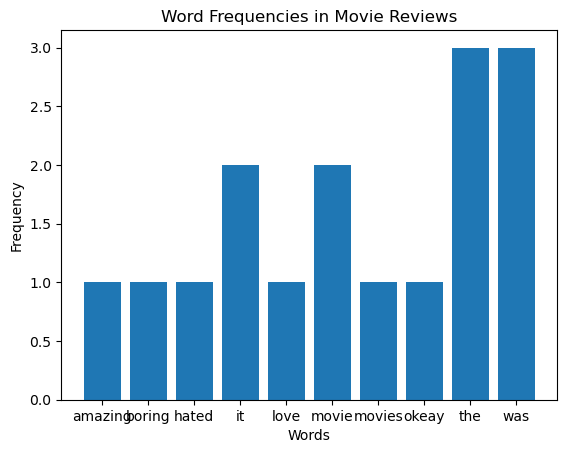

In [8]:
import matplotlib.pyplot as plt

plt.bar(words, word_counts)
plt.title("Word Frequencies in Movie Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [9]:
reviews = [
    "The product is fantastic! It works like a charm.",
    "I hated the product. It broke after one use.",
    "Product was okay, not the best, but fine overall."
]
# Preprocess the reviews
cleaned_reviews = [preprocess(review) for review in reviews]

vectorizer = CountVectorizer()
# Fit the vectorizer
vectorizer.fit(cleaned_reviews)
# Print the vocabulary 
print(vectorizer.get_feature_names_out())

['after' 'best' 'broke' 'but' 'charm' 'fantastic' 'fine' 'hated' 'is' 'it'
 'like' 'not' 'okay' 'one' 'overall' 'product' 'the' 'use' 'was' 'works']


### Transforming text to numbers with BoW


In [10]:
# Transform the reviews
bow_matrix = vectorizer.transform(cleaned_reviews)

# Print the BoW representation
print(bow_matrix.toarray())

[[0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 1 1 0 0 1]
 [1 0 1 0 0 0 0 1 0 1 0 0 0 1 0 1 1 1 0 0]
 [0 1 0 1 0 0 1 0 0 0 0 1 1 0 1 1 1 0 1 0]]


### Frequency analysis of product reviews

In [12]:
product_reviews = ['I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.',
 'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".',
 'This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy treat.  If you are familiar with the story of C.S. Lewis\' "The Lion, The Witch, and The Wardrobe" - this is the treat that seduces Edmund into selling out his Brother and Sisters to the Witch.',
 'If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.',
 'Great taffy at a great price.  There was a wide assortment of yummy taffy.  Delivery was very quick.  If your a taffy lover, this is a deal.',
 'I got a wild hair for taffy and ordered this five pound bag. The taffy was all very enjoyable with many flavors: watermelon, root beer, melon, peppermint, grape, etc. My only complaint is there was a bit too much red/black licorice-flavored pieces (just not my particular favorites). Between me, my kids, and my husband, this lasted only two weeks! I would recommend this brand of taffy -- it was a delightful treat.',
 "This saltwater taffy had great flavors and was very soft and chewy.  Each candy was individually wrapped well.  None of the candies were stuck together, which did happen in the expensive version, Fralinger's.  Would highly recommend this candy!  I served it at a beach-themed party and everyone loved it!",
 'This taffy is so good.  It is very soft and chewy.  The flavors are amazing.  I would definitely recommend you buying it.  Very satisfying!!',
 "Right now I'm mostly just sprouting this so my cats can eat the grass. They love it. I rotate it around with Wheatgrass and Rye too",
 'This is a very healthy dog food. Good for their digestion. Also good for small puppies. My dog eats her required amount at every feeding.',
 "I don't know if it's the cactus or the tequila or just the unique combination of ingredients, but the flavour of this hot sauce makes it one of a kind!  We picked up a bottle once on a trip we were on and brought it back home with us and were totally blown away!  When we realized that we simply couldn't find it anywhere in our city we were bummed.<br /><br />Now, because of the magic of the internet, we have a case of the sauce and are ecstatic because of it.<br /><br />If you love hot sauce..I mean really love hot sauce, but don't want a sauce that tastelessly burns your throat, grab a bottle of Tequila Picante Gourmet de Inclan.  Just realize that once you taste it, you will never want to use any other sauce.<br /><br />Thank you for the personal, incredible service!",
 "One of my boys needed to lose some weight and the other didn't.  I put this food on the floor for the chubby guy, and the protein-rich, no by-product food up higher where only my skinny boy can jump.  The higher food sits going stale.  They both really go for this food.  And my chubby boy has been losing about an ounce a week.",
 "My cats have been happily eating Felidae Platinum for more than two years. I just got a new bag and the shape of the food is different. They tried the new food when I first put it in their bowls and now the bowls sit full and the kitties will not touch the food. I've noticed similar reviews related to formula changes in the past. Unfortunately, I now need to find a new food that my cats will eat.",
 'good flavor! these came securely packed... they were fresh and delicious! i love these Twizzlers!',
 'The Strawberry Twizzlers are my guilty pleasure - yummy. Six pounds will be around for a while with my son and I.',
 "My daughter loves twizzlers and this shipment of six pounds really hit the spot. It's exactly what you would expect...six packages of strawberry twizzlers.",
 'I love eating them and they are good for watching TV and looking at movies! It is not too sweet. I like to transfer them to a zip lock baggie so they stay fresh so I can take my time eating them.',
 'I am very satisfied with my Twizzler purchase.  I shared these with others and we have all enjoyed them.  I will definitely be ordering more.',
 'Twizzlers, Strawberry my childhood favorite candy, made in Lancaster Pennsylvania by Y & S Candies, Inc. one of the oldest confectionery Firms in the United States, now a Subsidiary of the Hershey Company, the Company was established in 1845 as Young and Smylie, they also make Apple Licorice Twists, Green Color and Blue Raspberry Licorice Twists, I like them all<br /><br />I keep it in a dry cool place because is not recommended it to put it in the fridge. According to the Guinness Book of Records, the longest Licorice Twist ever made measured 1.200 Feet (370 M) and weighted 100 Pounds (45 Kg) and was made by Y & S Candies, Inc. This Record-Breaking Twist became a Guinness World Record on July 19, 1998. This Product is Kosher! Thank You',
 'Candy was delivered very fast and was purchased at a reasonable price.  I was home bound and unable to get to a store so this was perfect for me.',
 "My husband is a Twizzlers addict.  We've bought these many times from Amazon because we're government employees living overseas and can't get them in the country we are assigned to.  They've always been fresh and tasty, packed well and arrive in a timely manner.",
 'I bought these for my husband who is currently overseas. He loves these, and apparently his staff likes them also.<br />There are generous amounts of Twizzlers in each 16-ounce bag, and this was well worth the price. <a href="http://www.amazon.com/gp/product/B001GVISJM">Twizzlers, Strawberry, 16-Ounce Bags (Pack of 6)</a>',
 "I can remember buying this candy as a kid and the quality hasn't dropped in all these years. Still a superb product you won't be disappointed with.",
 'I love this candy.  After weight watchers I had to cut back but still have a craving for it.',
 "I have lived out of the US for over 7 yrs now, and I so miss my Twizzlers!!  When I go back to visit or someone visits me, I always stock up.  All I can say is YUM!<br />Sell these in Mexico and you will have a faithful buyer, more often than I'm able to buy them right now.",
 'Product received is as advertised.<br /><br /><a href="http://www.amazon.com/gp/product/B001GVISJM">Twizzlers, Strawberry, 16-Ounce Bags (Pack of 6)</a>',
 'The candy is just red , No flavor . Just  plan and chewy .  I would never buy them again',
 'I was so glad Amazon carried these batteries.  I have a hard time finding them elsewhere because they are such a unique size.  I need them for my garage door opener.<br />Great deal for the price.',
 "I got this for my Mum who is not diabetic but needs to watch her sugar intake, and my father who simply chooses to limit unnecessary sugar intake - she's the one with the sweet tooth - they both LOVED these toffees, you would never guess that they're sugar-free and it's so great that you can eat them pretty much guilt free!  i was so impressed that i've ordered some for myself (w dark chocolate) to take to the office so i'll eat them instead of snacking on sugary sweets.<br />These are just EXCELLENT!",
 "I don't know if it's the cactus or the tequila or just the unique combination of ingredients, but the flavour of this hot sauce makes it one of a kind!  We picked up a bottle once on a trip we were on and brought it back home with us and were totally blown away!  When we realized that we simply couldn't find it anywhere in our city we were bummed.<br /><br />Now, because of the magic of the internet, we have a case of the sauce and are ecstatic because of it.<br /><br />If you love hot sauce..I mean really love hot sauce, but don't want a sauce that tastelessly burns your throat, grab a bottle of Tequila Picante Gourmet de Inclan.  Just realize that once you taste it, you will never want to use any other sauce.<br /><br />Thank you for the personal, incredible service!",
 "I have never been a huge coffee fan. However, my mother purchased this little machine and talked me into trying the Latte Macciato. No Coffee Shop has a better one and I like most of the other products, too (as a usually non-coffee drinker!).<br />The little Dolche Guesto Machine is super easy to use and prepares a really good Coffee/Latte/Cappuccino/etc in less than a minute (if water is heated up). I would recommend the Dolce Gusto to anyone. Too good for the price and I'am getting one myself! :)",
 'This offer is a great price and a great taste, thanks Amazon for selling this product.<br /><br />Staral',
 "McCann's Instant Oatmeal is great if you must have your oatmeal but can only scrape together two or three minutes to prepare it. There is no escaping the fact, however, that even the best instant oatmeal is nowhere near as good as even a store brand of oatmeal requiring stovetop preparation.  Still, the McCann's is as good as it gets for instant oatmeal. It's even better than the organic, all-natural brands I have tried.  All the varieties in the McCann's variety pack taste good.  It can be prepared in the microwave or by adding boiling water so it is convenient in the extreme when time is an issue.<br /><br />McCann's use of actual cane sugar instead of high fructose corn syrup helped me decide to buy this product.  Real sugar tastes better and is not as harmful as the other stuff. One thing I do not like, though, is McCann's use of thickeners.  Oats plus water plus heat should make a creamy, tasty oatmeal without the need for guar gum. But this is a convenience product.  Maybe the guar gum is why, after sitting in the bowl a while, the instant McCann's becomes too thick and gluey.",
 "This is a good instant oatmeal from the best oatmeal brand.  It uses cane sugar instead of high fructouse corn syrup, so not only does it have a better sweetness, but some doctors now say that this form of sugar is better for you.  Great on a cold morning when you don't have time to make McCann's Steel Cut Oats.  The apple cinnamon is the best but the maple and brown sugar or the regular are good too.  Plus they don't require doctoring to actually tell the three flavors apart.",
 "Instant oatmeal can become soggy the minute the water hits the bowl. McCann's Instant Oatmeal holds its texture, has excellent flavor, and is good for you all at the same time. McCann's regular oat meal is excellent, too, but may take a bit longer to prepare than most have time for in the morning. This is the best instant brand I've ever eaten, and a very close second to the non-instant variety.<br /><br />McCann's Instant Irish Oatmeal, Variety Pack of Regular, Apples & Cinnamon, and Maple & Brown Sugar, 10-Count Boxes (Pack of 6)",
 "McCann's Instant Irish Oatmeal, Variety Pack of Regular, Apples & Cinnamon, and Maple & Brown Sugar, 10-Count Boxes (Pack of 6)<br /><br />I'm a fan of the McCann's steel-cut oats, so I thought I'd give the instant variety a try. I found it to be a hardy meal, not too sweet, and great for folks like me (post-bariatric surgery) who need food that is palatable, easily digestible, with fiber but won't make you bloat.",
 "For those of us with celiac disease this product is a lifesaver and what could be better than getting it at almost half the price of the grocery or health food store!  I love McCann's instant oatmeal - all flavors!!!<br /><br />Thanks,<br />Abby",
 "What else do you need to know? Oatmeal, instant (make it with a half cup of low-fat milk and add raisins;nuke for 90 seconds). More expensive than Kroger store brand oatmeal and maybe a little tastier or better texture or something. It's still just oatmeal. Mmm, convenient!",
 'I WAS VISITING MY FRIEND NATE THE OTHER MORNING FOR COFFEE , HE CAME OUT OF HIS STORAGE ROOM WITH ( A PACKET OF McCANNS INSTANT IRISH OATMEAL .) HE SUGGESTED THAT I TRY IT FOR MY OWN USE ,IN MY STASH . SOMETIMES NATE DOSE NOT GIVE YOU A CHANCE TO SAY NO , SO I ENDED UP TRYING THE APPLE AND CINN . FOUND IT TO BE VERY TASTEFULL WHEN MADE WITH WATER OR POWDERED MILK . IT GOES GOOD WITH O.J. AND COFFEE AND A SLICE OF TOAST AND YOUR READY TO TAKE ON THE WORLD...OR THE DAY AT LEAST..  JERRY REITH...',
 'I ordered this for my wife as it was reccomended by our daughter.  She has this almost every morning and likes all flavors.  She\'s happy, I\'m happy!!!<br /><a href="http://www.amazon.com/gp/product/B001EO5QW8">McCANN\'S Instant Irish Oatmeal, Variety Pack of Regular, Apples & Cinnamon, and Maple & Brown Sugar, 10-Count Boxes (Pack of 6)</a>',
 "The variety packs taste great!<br /><br />I have them every morning. At $0.30 cents per meal, I don't understand why everyone on earth isn't buying this stuff up.<br /><br />Maple and brown sugar is terrific, followed by apples and cinnamon, followed by regular. You don't get tired of the same ole thing, and they taste great.<br /><br />I just boil water from a small pot, empty the packet or 2 in a bowl, pour in boiling water, and watch it expand to 2x its size!<br /><br />Taste really good and takes minutes to prepare.<br /><br />Not sure why everyone on earth isn't this. Convenient, healthy, very quick, excellent quality, and extremely cheap...",
 "McCann's makes oatmeal for every oatmeal connoisseur, whether one likes it from the raw pellet state that cooks for half an hour, to the sloth addled instant, which can be done in the microwave for under three minutes. It's all good, that's for sure, and the beauty of the instant variety is that it is available in different flavors as well as regular.<br />  This variety pack allows different tastes to be explored, as well as giving you a chance to experience the difference between McCann's and other well-known oatmeals. What I personally like about McCann's is that it cooks up thicker and with more body than the top brand here in America. The Apples & Cinnamon, though, tends to be a little liquidy so you may want to experiment with the amount of water you add. In my 1300watt microwave the oatmeal cooks up in about one minute and twenty-seven seconds, so you should also watch that to get a handle on how much time and water to use.<br />  The only bad thing -- if you can consider it a bad thing -- about this offering is that you have to buy in lot so you'll end up with six ten-count boxes. This is good if you have a whole family of oatmeal-eaters, but if you're a single person alone -- well, love oatmeal.",
 "I have McCann's Oatmeal every morning and by ordering it from Amazon I am able to save almost $3.00 per box.<br />It is a great product. Tastes great and very healthy",
 "McCann's Oatmeal is a good quality choice.  Our favorite is the Apples and Cinnamon, but we find that none of these are overly sugary.  For a good hot breakfast in 2 minutes, this is excellent.",
 "We really like the McCann's steel cut oats but find we don't cook it up too often.<br />This tastes much better to me than the grocery store brands and is just as convenient.<br />Anything that keeps me eating oatmeal regularly is a good thing.",
 "This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't buy it again.",
 "Good oatmeal.  I like the apple cinnamon the best.  Though I wouldn't follow the directions on the package since it always comes out too soupy for my taste.  That could just be me since I like my oatmeal really thick to add some milk on top of.",
 'The flavors are good.  However, I do not see any differce between this and Oaker Oats brand - they are both mushy.',
 "I really like the Maple and Brown Sugar flavor. The regular is fine with brown sugar added. The Apples and Cinnamon flavor is OK. This is a very quick, easy and satisfying breakfast and I'll order this brand again, but not the variety. I'll get all Maple and Brown Sugar.",
 'This is the same stuff you can buy at the big box stores.  There is nothing healthy about it.  It is just carbs and sugars.  Save your money and get something that at least has some taste.',
 "This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go.",
 'Got a free package of these with a bottle of bloody mary mix I bought from the seller, and the advertising worked..lol,  I tried them, and shared them with 2 buddies, and we all loved them...  So im here to buy more, and noticed there were no reviews yet,...  well now there is.  They are Hot,  but not "burn your mouth forever hot"  its a nice temp...  Perfect for us..',
 "This wasn't in stock the last time I looked. I had to go to the Vermont Country Store in Weston to find it along with a jaw harp, Cranberry Horseradish Sauce, Fartless Black Bean Salsa, Apple Cider Jelly, Newton's Cradle Art in Motion and the staple Vermont Maple Syrup.<br /><br />Back to the Ass Kickin Peanuts. They are hot. They will activate the perspiration glands behind your ears and under your arms. It requires a beverage as advertised, a glass of very cold milk, and a box of Kleenex since it will make your nose run. They look like ordinary peanuts which is already giving me ideas for work. I suspect that some people have been hitting my goodies in my absence, especially my colleague Greg. I'm going to take this to work at earliest opportunity and empty the contents of this can into an ordinary Planters Peanuts can, and then see whose crying or whose nose is running when I return.<br /><br />The can should be shaken to ensure the spices are evenly distributed. It is important to wash your hands after consumption and not touch the eyes.<br /><br />You'll go nuts over these Ass-Kickin' Peanuts.<br /><br />P.S. I'm not sharing the peanuts, not deliberately, and I'll probably give Greg the jaw harp for Christmas. He'll be so insulted.",
 "we're used to spicy foods down here in south texas and these are not at all spicy.  doubt very much habanero is used at all.  could take it up a notch or two.",
 "I roast at home with a stove-top popcorn popper (but I do it outside, of course). These beans (Coffee Bean Direct Green Mexican Altura) seem to be well-suited for this method. The first and second cracks are distinct, and I've roasted the beans from medium to slightly dark with great results every time. The aroma is strong and persistent. The taste is smooth, velvety, yet lively.",
 "We roast these in a large cast iron pan on the grill (about 1/3 of the bag at a time).  The smell is wonderful and the roasted beans taste delicious too.  More importantly, the coffee is smooth; no bitter aftertaste.  On numerous occasions, we've had to send the roasted beans home with friends because they like it so much.",
 "Deal was awesome!  Arrived before Halloween as indicated and was enough to satisfy trick or treaters.  I love the quality of this product and it was much less expensive than the local store's candy.",
 'It is chocolate, what can I say.  Great variety of everything our family loves.  With a family of six it goes fast here.  Perfect variety.  Kit Kat, Reeses, take five and more.',
 'Great product, nice combination of chocolates and perfect size!  The bags had plenty, and they were shipped promptly.  The kids in the neighborhood liked our candies!',
 'Halloween is over but, I sent a bag to my daughters class for her share. The chocolate was fresh and enjoyed by many.',
 'Watch your prices with this.  While the assortment was good, and I did get this on a gold box purchase, the price for this was<br />$3-4 less at Target.',
 'This bag of candy online is pretty expensive, it should be cheaper in order to compete with grocery stores, other than that, its a good combination of my favorite candy',
 'Arrived in 6 days and were so stale i could not eat any of the 6 bags!!',
 'I have used the endurolyte product for several years in both pill and powder form.  Long desert rides on the dirt bike always found my camelbak water heavily laced with the endurolyte powder, not overly tasty, but quite effective, as I never got a cramp on these several hundred mile rides.  Same for desert racing in the buggy, the camelbaks were always laced with the powder.  Now we have the Fizz...what a great product!  Firstly, its Hammer\'s endurolyte product so it\'s great, endurance athlete\'s the world over use their products. Second its convenient, handly tablets that dissovle in a fizz.  Third it tastes great! Imagine getting a nice cool drink when your body is starving for hydration and electrolytes and rather than getting a "salty" taste, you get a refreshing lemon-lime or mango!  The camelbaks always get the Fizz now.  I also drop a tablet in my bottled water whenever I exercise and have a nice flavored water chock full of electrolytes. I cannot recommend this product or any hammer product highly enough.',
 'This product serves me well as a source of electrolytes during and after a long run or bike ride.<br />I have tried all of the flavors but really do like the grapefruit flavor... no after-taste and I actually like the slight carbonation.<br />I use other Hammer products and really like their whole product line.',
 "This stuff really works for preventing cramping during the middle to latter stages of your rides. Pop 1 into each water bottle and you're set. Flavor is fine and goes down easy.",
 'For those of us on a low carb diet these little tablets are just the thing.<br /><br />Two years ago I started cycling again after many years but was having heart arrhythmia after longer rides in high heat.  I was drinking plain water but did a little research and thought electrolytes might be the issue.  Gatorade wasn\'t an option because it is so loaded with carbohydrates so I looked around for a low-carb alternative.  The "zero carb" sports drinks didn\'t help so what to do?  One day I ran across these at my bike shop so tried a tube of them.....voila!...problem solved!!<br /><br />I\'ve shared them with two friends in particular whose problems with leg cramps were resolved while using these.<br /><br />These guys got it right -- they are superbly formulated and simply work.....',
 "I purchased the Mango flavor, and to me it doesn't take like Mango at all.  There is no hint of sweetness, and unfortunately there is a hint or aftertaste almost like licorice.  I've been consuming various sports nutrition products for decades, so I'm familiar and have come to like the taste of the most of the products I've tried.  The mango flavor is one of the least appealing I've tasted.  It's not terrible, but it's bad enough that I notice the bad taste every sip I take.",
 "If you're impulsive like me, then $6 is ok. Don't get me wrong, the quality of these babies is very good and I have no complaints. But in retrospect, the price is a little ridiculous (esp. when you add on the shipping).",
 'this was sooooo deliscious but too bad i ate em too fast and gained 2 pds! my fault',
 "These Albanese gummi bears and rings and so on are very good and tasty and high quality. The bears even have little faces. At my local candy store this type of gummi stuff (bears, rings, snakes, balls, worms, whatever) are about $10/lb. These twin packs of 4.5 or 5 pound bags is a screaming deal as far as I'm concerned. I'm probably 50 pounds deep in these friggin' things. Consumed!",
 "Grape gummy bears are hard to find in my area. In fact pretty much anyone I talk to about grape gummy bears they think I'm lying. So I bought 10lbs... : ) These bears are a little bit bigger then the other brands and have kind of sour kick, but nothing to strong. I love grape flavored candy/soda and these are pretty good. There is another company that makes grape gummy bears that are a little bit better in my opinion, but these are well worth it for the price. I like to use the gummy bears in home made Popsicles with flavored sports drink. The salt in the sports drink makes for softer popsicles, and the gummy bears are awesome frozen. They are delicious!",
 "I ordered two of these and two of raspberry latice tarts directly from FantasiCakes website for a dinner party I was hosting. It arrived fresh and intact. Very good size. I froze half for later use. I am a pastry lover and these were the best I've ever tasted. The pastry was soft, the jam was really good and the taste was great. They were gone in no time. My guests were really impressed.",
 'Buyer Beware Please! This sweetener is not for everybody.  Maltitol is an alcohol sugar and can be undigestible in the body.  You will know a short time after consuming it if you are one of the unsuspecting many who cannot digest it by the extreme intestinal bloating and cramping and massive amounts of gas a person can experience. Nausea, diarrhea & headaches can also be experienced. I learned my lesson the hard way years ago when I fell in love with the sugar-free chocolates suzanne sommers used to sell.  I thought I\'d found sugar-free chocolate nirvana at first taste but the bliss was short lived when the terrible side effects of maltitol kicked in.  The discomfort was unlike anything I had ever felt before.  I blew up like a balloon and had very painful abdominal cramping.  As the symptoms passed, this too was very unpleasant.  Though hard for me to believe a low calorie sweetener could be the culprit, all symptoms were gone when I stopped eating the chocolate. My hunch it had something to do with the maltitol were unfortunately confirmed for me about a year later when I purchased some delicious sugar-free popcorn at my local market.  The taste was amazing and while I was looking at the label wondering what could possibly make this yummy, new sugarfree treat taste so good, my heart sank when I followed the little asterisk next to sugarfree sweetener* down to the very bottom of the label and read "maltitol" in tiny little letters! Thank goodness I\'d eaten only a little. I still ended up with all the same side-effects but for a much shorter duration. Some people can use maltitol to their heart\'s content but others, like me, can have a bad reaction to it. In case you\'re like me, ... it\'s not you ...it\'s the maltitol!',
 'It is okay.  I would not go out of my way to buy it again',
 'No tea flavor at all. Just whole brunch of artifial flavors. It is not returnable. I wasted 20+ bucks.',
 "These looked like a perfect snack to through in with my trail mix.  Unfortunately, they arrived in a solid mass of melted chocolate.  I left them in my pantry for a few days, and when I opened them at room temperature they were still gooey.  I through them in the fridge and I've been breaking off hunks ever since.  They taste good to me, but the chocolate is all grainy after melting and then solidifying again.  I won't order them online again, but if I see them in a store I would pick them up.",
 'These taste really good. I have been purchasing a different brand and these are very similar in taste and texture. I agree with the other reviewer regarding ordering in the summer. There is no insulating packaging with ice packs so they will melt in warm weather like all chocolate food items. Order in cold weather and buy enough to last!!!',
 'The taste was great, but the berries had melted.  May order again in winter. If you order in cold weather you should enjoy flavor.',
 'i know i cannot make tea this good.  granted, i am not from the south but i know i have never enjoyed tea that was this sweet without being too sweet.  it tastes crisp.',
 "This peppermint stick is delicious and fun to eat.  My dad got me one for Christmas because he remembered me having a similar one when I was a little girl.  I'm 30 now and I love it!",
 'Great gift for all ages! I purchased these giant canes before and the recipients loved them so much, they kept them and would not eat them.',
 'I know the product title says Molecular Gastronomy, but don\'t let that scare you off.  I have been looking for this for a while now, not for food science, but for something more down to earth.  I use it to make my own coffee creamer.<br /><br />I have to have my coffee blonde and sweet - but the flavored creamers are full of the bad kinds of fat, and honestly, I hate to use manufactured "food" items.  I really don\'t think they are good for the body.  On the other hand, I hate using cold milk or cream, because I like HOT coffee.<br /><br />I stumbled across this on Amazon one day and got the idea of making my own creamer.  I also bought low-fat (non-instant) milk powder and regular milk powder. The non-instant lowfat milk is a little sweeter and tastes fresher than regular instant low-fat milk, but does not dissolve good in cold water - which is not a problem for hot coffee.  You will have to play with the ratios - I would not do just the heavy cream, it made the coffee too rich. Also, I think the powder is too expensive to just use on it\'s own. I like mixing 1/3 of each together.<br /><br />For flavoring, I bough cocoa bean powder, vanilla bean powder, and caster (superfine) sugar.  I mix up small batches along with spices like cinnamon and nutmeg to make my own flavored creamers.  If you wanted, you could use a fake sweetner powder instead.  I make up small amounts that I store in jelly canning jars. I also use my little food chopper/food processor to blend everything, so the sugar is not heavier and sinks to the bottom.  Let it settle for a bit before opening the top though.<br /><br />This stuff tastes WAY better than the storebought creamers and it is fun to experiment and come up with your own flavors.  I am going to try using some essential oils next and see if I can get a good chocolate/orange mix.<br /><br />All of the ingredients I mentioned are here online.  Take the time to experiment.  Maybe you don\'t use any low-fat milk. Or don\'t add any flavorings.  It is up to you.  Also, would make great housewarming/host(ess) gifts.<br /><br />I am sure other molecular people will be able to tell you more of what you can do with it, and I am sure I will experiment with it in cooking - but the main reason I bought it was to make my own creamer and it worked out great.',
 'While my dogs like all of the flavors that we have tried of this dog food, for some reason their itching increased when I tried the lamb and rice. I have some very itchy dogs and am giving them a limited ingredient dog food to try to help. The duck and sweet potato cut down on the itching significantly, but when we tried lamb and rice they started itching more once again. I like Natural Balance for the quality ingredients.',
 'Awesome dog food. However, when given to my "Boston", who has severe reactions to some food ingredients; his itching increased to violent jumping out of bed at night, scratching. As soon as I changed to a different formula, the scratching stopped. So glad Natural Balance has other choices. I guess you have to try each, until you find what\'s best for your pet.',
 'We have three dogs and all of them love this food!  We bought it specifically for one of our dogs who has food allergies and it works great for him, no more hot spots or tummy problems.<br />I LOVE that it ships right to our door with free shipping.',
 "My dog has a ton of allergies both environmental and food. She was on a prescription dog food before we had her tested to see what allergies she has. After we got the test back, we learned she was allergic to something in the prescription brand. So I finally found this dog food and she has done so well on this! She still has her environmental triggers, but I am happy she can finally eat something I know won't cause her pain.",
 "My shepherd/collie mix has IBS.  Our vet recommended a limited ingredient food.  This has really helped her symptoms and she likes it.  I will always buy it from Amazon...it's $10 cheaper and free shipping!",
 "Natural Balance Dry Dog Food Lamb Meal and Brown Rice Recipe did wonders for my Jack Russell. She has awful food allergy's and this food was our last hope because it was the last food we could find that didn't have SOMETHING in it that she was allergic to. She has no problem eating it dry but normally I mix the Natural Balance Dry Lamb and Brown Rice with the Natural Balance Wet Lamb and Brown Rice.. she seems to like that better. We started feeding it to our other dog (a Bichon) too and she loves it. If your dog has allergy's or stomach issue.. or if you want your dog to eat better food-- this is it! You will see a difference in your pet.",
 "Great food! I love the idea of one food for all ages & breeds. Ît's a real convenience as well as a really good product.  My 3 dogs eat less, have almost no gas, their poop is regular and a perfect consistency, what else can a mom ask for!!",
 'I have a standard poodle and pomeranian who both do wonderful on this food. I have switched them to a different food (due to price) a couple of times and end up going right back to natural balance.',
 'This is great dog food, my dog has severs allergies and this brand is the only one that we can feed him.',
 'This food is great - all ages dogs.  I have a 3 year old and a puppy.  They are both so soft and hardly ever get sick.  The food is good especially when you have Amazon Prime shipping  :)',
 "My golden retriever is one of the most picky dogs I've ever met.  After experimenting with various types of food, I have found she loves natural balance.  What I really like about natural balance is the fact that it has multiple flavors in dry and wet varieties.  I mix her dry food with a little wet food and my golden loves it.  Furthermore, I do like mixing up the flavors each time as I think the same meal day over day might get a little boring, so I figured why not.  I tend to stay away from the fish type though as it smells...<br /><br />Additionally, I started purchasing off Amazon because Petco didn't have the wet food box and only had a couple of cans.  I came home and to my surprise realized that I could save $20 each time I bought dog food if I just buy it off Amazon.<br /><br />All in all, I definitely recommend and give my stamp of approval to natural balance dog food.  While I have never eaten it, my dog seems to love it.",
 "This is the same food we get at pet store. But it's delivered to my door! And for the same price or slightly less.",
 "I've been very pleased with the Natural Balance dog food. Our dogs have had issues with other dog foods in the past and I had someone recommend Natural Balance grain free since it is possible they were allergic to grains. Since switching I haven't had any issues. It is also helpful that have have different kibble size for larger/smaller sized dogs.",
 'My 1-1/2 year old basenji/jack russell mix loves this dog food. He\'s been noticeably healthier and more energetic since I switched him over from the standard dog foods earlier this year. Despite the higher cost of natural dog foods, I find that he eats significantly less of the Natural Balance dog foods and still stays happy and full. On the normal dog foods, he\'d eat up to 3 cups of dog food a day (the recommended serving for his size), whereas he only eats about 1 cup to 1-1/2 cup of the Natural Balance dog food a day. When you take this into account, you\'re actually getting more "bang for your buck" with the natural dog foods since you don\'t have to buy as much to last just as long as the normal dog foods... and a healthier, happier dog, to boot! Add in the fact that you can get free, 2-day shipping with Amazon Prime... I\'m sold!!',
 "Our pup has experienced allergies in forms of hotspots and itching from other dog foods. The cheap 'you can buy it anywhere' food not only have crazy preservatives in them but can cause health problems for your pets.  This food works wonders on reducing allergies and our dog loves the food.<br />This message is RAMSEY FrAnkenSteiN approved.",
 "My English Bulldog had skin allergies the summer we got him at age 3.  The vet recommended we wean him off the food his previous owner gave him (Iams Lamb and Rice) and onto a new kind.  This was the second one we tried, and it has been working ever since.  It's for dogs that need a limited diet who can be sensitive to additives and proteins commonly found in commercial dog food (like chicken or beef).",
 "I fed this to my Golden Retriever and he hated it.  He wouldn't eat it, and when he did, it gave him terrible diarrhea.  We will not be buying this again.  It's also super expensive.",
 'The mouth says, "How do I love thee, let me count the ways..."<br />If you like apple products a must have item.  The only draw back, shipping cost.  These are very heavy.',
 "Arrived slightly thawed. My parents wouldn't accept it. However, the company was very helpful and issued a full refund.",
 "The crust on these tarts are perfect.  My husband loves these, but I'm not so crazy about them.  They are just too sour/tart for my taste.  I'll eat the crust and hubby takes my filling.  My kids think they're great, so maybe it's just me.",
 'These are absolutely scrumptuous!  My husband and I both love them, however, as another customer put it, they are expensive to ship!  The cost of shipping is more than the tartlets themselves are!',
 'What a nice alternative to an apple pie. Love the fact there was no slicing and dicing. Easy to prepare. I also loved the fact that you can make them fresh whenever needed.',
 'I like Creme Brulee. I loved that these were so easy. Just sprinkle on the sugar that came with and broil. They look amazing and taste great. My guess thought I really went out of the way for them when really it took all of 5 minutes. I will be ordering more!',
 "not what I was expecting in terms of the company's reputation for excellent home delivery products",
 "I first bought pickled asparagus at an Amish market and it was love at first bite. Hence, when I saw these on the discount rack at the local Safeway I cleaned it out.  These are even better than the ones from the Amish market. They are fantastic, and some of the jars have a bonus clove of garlic at the bottom. I'm going to order the six pack and I'm a household of one. They wont go to waste!",
 "I love asparagus.  Up until very recently, I had never had pickled asparagus.  Oh my goodness, when a friend introduced me to this exact brand, I couldn't believe how great stuff tasted.  I loved it so much I bought the six pack.  I've got 2 jars left.  Gonna need more!!",
 'I\'m presently on a diet and I was at my Fresh and Easy Neighborhood Grocery looking over possible diet foods. I wanted things that were tasty, non-fat and low in calories. I came home with about a dozen items. That\'s how I discovered the Tillen Farms Pickled Crispy Asparagus. Well, I\'ve always liked asparagus anyway and I\'ve enjoyed several brands of pickled asparagus. This Tillen Farms brand is really, really good! It\'s the best I can recall. There\'s an excellent flavor and a big clove of garlic down in  the bottom of the jar which I\'m looking forward to eating. I can\'t believe how good this asparagus tastes and right on the front it says "only 60 calories per jar!" Now this is my idea of a good diet food!<br /><br />Gary Peterson',
 'I was diappointed in the flavor and texture of this mix.  I usually like most of the Low Carb things I have tried, but was diappointed in this specific one.',
 "I have been drinking this tea for a long time now.  I used to have to purchase it at a doctor's office because it wasn't available elsewhere.  I'm so glad that I can buy it now from Amazon.com.  I drink this tea throughout the day like other folks drink coffee.  Wonderful taste.",
 'I have been drinking Royal King 100% Natural Organic Green Tea (100 tea bags x 2g each) as my every day tea for several years now.  I buy 12 boxes at a time to save on shipping.  For many years I used to drink coffee from morning till night.  But finally I realized that drinking so much coffee was not healthy for me.  I finally resolved to improve my health and stopped drinking coffee all together.  I tried many alternative drinks to replace my coffee habit.  I found that green tea was not only good tasting it also has health benefits.  Green tea is one of the few drinks that actually makes you healthier (coffe and other drinks do not) - the only healthier drink is quality cold water.  In my opinion, for the price, Royal King 100% Natural Organic Green Tea is one of the best tasting teas.  This green tea has a beautiful golden color, the taste is bright and fresh.  I recommend adding a tiny amount of Y.S. Organic Bee Farms RAW HONEY to the tea to add sweetness and health benefits too.  I also give myself a treat once in a while by having a much more expense tea (Tribute Xi Hu Long Jing) but this fantastic tea is not practical for me to drink as my every day tea (although I would if I could afford it).<br /><br />Cons:  On my latest shipment the package shown on the Amazon page is different than the one shipped.  The one shipped displays "NATURALLY HIGH IN POLYPHENOL CATECHINS" (a key contributive element to the possible health effects of tea), whereas the Amazon package displays "CAFFENE FREE".  So I am not sure if this green tea is Caffene free or not.  The other con is that sometimes the tea bag rips open when I unwrap the string from around the tea bag. So if the string seems stuck to the tea bag I put the bag in the hot water to unstick it.',
 "this has to be one of the best teas I have ever tasted... it's clean, bright, fresh...<br /><br />great delivery...again quality... just try it...",
 "I love, love this green tea.  It is very hard to find in our area and some places on the internet charge a big price and I usually don't get as many boxes as I did with this merchant.  I will definitely order from this seller again!! Thanks!!  I depend on my green tea fix everyday!",
 'I love this tea. It helps curb my eating during the day. My Mom and I have given it all friends to try.',
 "I'm Italian and I lived in Italy for years. I used to buy these cookies for my everyday breakfast with an Italian espresso. I couldn't find them anywhere here in the Bay area, so it's great to have them again.",
 'In the 1980s I spent several summers in Italy. This biscotti is often given as a breakfast food or mid-day snack. They are simple and delicious and were not sold in the US back then. They are so good that I brought back two bags from a recent trip to Italy. It is great to see that they may now be found on Amazon!<br /><br />Note: it is great to open a bag, smell the contents, pour a glass of milk, then dip the Macines in the milk. Great routine and treat for kids!',
 "I had heard a little about this product from the local pet store, then tried a small bag for our 2 cats of about 3 and 6 years respectively. The female, younger one took to it right away, and the older male, who was unfortunately weaned on the junk cat food with all the corn meal and etc... in it, and would usually refuse a diet change, actually liked it too. The older male is overweight and we were trying to switch him to soft food on the doctor's request, but he totally refused it. He is a posh cat after all. He still consumes too many calories, the fatty, but at least I know he's eating good food. Of course, I know this product seems to cost more than most other feline food on the market, but I just can't see feeding our animals the lousy alternatives that are out there, marketed as being healthy. Why do commercials show cats eating a vegetarian diet which is mostly corn meal? Is that right? I'll stay with this for now, but stay tuned.<br /><br />I'm updating this review after 9 months of using this cat food for our two cats. I upgraded the stars from 4 to 5 as it really has been a good food for the two of them. Garfield still eats a little too much, but he's just a big cat who doesn't exercise much, let's face it. Our female cat will be 4 years old in a couple months and she's so healthy. She's tiny, but happy and agile. I tried the chicken version of Holistic Select, but Garfield seemd to miss this sardine version so we went back to this one. I've ordered the duck version and will update this once they try it.",
 'I started buying this after I noticed my 1 year old cat was already starting to lose his "spunk" so I decided it was time to start buying him "real" cat food...not the garbage in the super markets. I found this at the pet store out of the other million choices, and I\'m sure there are other brands that are just as good but this is the one I went with to try first and it was a great purchase. My cat has been on this for the past 8 months and he\'s now just has active as he was when he was a kitten and his coat has became sooo soft. Mainly, he loved the taste even more! I highly recommend this brand to all my friends and family for their animals!',
 'I have done a lot of research to find the best food for my cat, and this is an excellent food.  That is also according to my holistic veterinarian.  They put probiotics on the kibble as the last step, which is very important to me.  The best thing is that my cat loved it immediately and I had to stop mixing it with the old food because she only would eat Holistic Select.',
 "This cat food was recommended by my vet because my 13 year old Cleo Cat was having trouble keeping any food down and was loosing weight.  It stopped her problems.  She doesn't eat as much as before since she seems to be more satisfied after eating which helps justify the added price.  It aids in digestion since the...ok sorry...smells are gone if ya know what I mean.  Had to add that so anyone experiencing problems with their cats can see there are a lot of benifits from this cat food.",
 "I have a 4 year old male cat who has chronic urinary tract infections.  I feed him this dry food in combination with wet food (with water added to it) and Uri Ease.  The combination seems to keeps his UTI's under control.  If I switch to another type of dry food, his UTI gets worse.  The other cats seem to enjoy this food as well.  It's expensive but it seems to be the best solution for me.",
 "Before I was educated about feline nutrition, I allowed my cats to become addicted to dry cat food. I always offered both canned and dry, but wish I would have fed them premium quality canned food and limited dry food. I have two 15 year old cats and two 5 year old cats. The only good quality dry foods they will eat are Wellness and Innova. Innova's manufacturer was recently purchased by Procter&Gamble. I began looking for a replacement. After once again offering several samples (from my local holistic pet store) Holistic Select was the only one (other than the usual Wellness and Innova) they would eat. For finicky cats, I recommend trying Holistic Select. It is a good quality food that is very palatable for finicky eaters.",
 "My holistic vet recommended this, along with a few other brands. We tried them all, but my cats prefer this (especially the sardine version). The best part is their coats are so soft and clean and their eyes are so clear. AND (and I don't want to be rude, so I'll say this as delicately as I can) their waste is far less odorous than cats who eat the McDonalds junk found in most stores, which is a definite plus for me! The health benefits are so obvious - I highly recommend Holistic Select!",
 'One of my cats is allergic to fish and beef. This formula is one of the few she can eat, and it has much better ingredients than the prescription diets available at the vet. Both of my kitties are very active, have soft shiny fur, and neither are fat. Dry food reduces tartar buildup on teeth, also.',
 'Our cats thrive extremely well on this dry cat food.  They definitely have much less hair ball throw ups and their fur is great.  They are fit and not over weight.  This vendor ships extremely fast.  Is one of the top Amazon suppliers in our book!',
 "I've been a fan of Hot & Spicy Maruchan Ramen for a long time. If you enjoy spice, and love ramen, you'll love this product. Too bad it's way too expensive here on Amazon. It's only $3.36 per 12 at my Walmart.",
 "I've been eating Ramen noodles since I was a little kid, and I've never found a better flavor than Hot & Spicy Chicken!  It isn't hot at all to a chilihead like me, but it sure is good!",
 "I LOVE spicy ramen, but for whatever reasons this thing burns my stomach badly and the burning sensation doesn't go away for like 3 hours! Not sure if that is healthy or not .... and you can buy this at Walmart for $0.28, way cheaper than Amazon.",
 'Always being a fan of ramen as a quick and easy meal, finding it on amazon for a decent price and having it delivered to your door by the case is an amazing situation for anyone to find themselves in.',
 "I must be a bit of a wuss, because this soup tastes to me how I imagine fire might taste. Typically I like spicy food if it has a good flavor.  I don't find this to be the case with this soup. Any flavor is killed off by the burn.",
 "I really loved the spicy flavor these had.  I found myself liking the broth more than the noodles which is usually the opposite.  If you aren't used to the heat this might bother you and if you like hot hot foods this might not be enough.",
 "Got these on sale for roughly 25 cents per cup, which is half the price of my local grocery stores, plus they rarely stock the spicy flavors. These things are a GREAT snack for my office where time is constantly crunched and sometimes you can't escape for a real meal. This is one of my favorite flavors of Instant Lunch and will be back to buy every time it goes on sale.",
 'i have bought allot of different flavors and this happens to be one of my favorites and will be getting more soon',
 "I love this flavor of ramen! I don't eat other flavors anymore because they taste too bland by comparison. For the convenience of having it delivered to my home (I have prime, so I get it in two days and don't have to pay for the shipping), the price on amazon isn't bad at all, but it is still cheaper to run down and pick up a case of this at the grocery store.",
 "The BEST investment I've ever made for ginger. It's unbelievable! It's fibrous like the real ginger, has that spicy kick to it, but it's perfect with the sugar - calms it down.  It's very worth the $40 for 5lbs of it!  I'll be getting more soon - I use these as a topper for my ginger cupcakes and cookies :)",
 "Delicious. I cannot get Australian ginger where I live. This compares favorably to Australian Ginger I've purchased in other cities. Now I can enjoy it without traveling.",
 'I keep trying other brands.... cheaper brands. Stupid me! This ginger IS soooo worth the money. Tender, moist and never a let down.',
 'My son has had acid reflux since birth and has been on every medication available with no improvement, Until an older gentleman came into his work place and told him about this product and I automatically ordered it for him. I was really not expecting any better results than the 1000 other things we have tried. What a surprise! He has not had any heartburn or symptoms since day 2 of starting eating one piece of this Ginger each morning. He can now eat anything and actually enjoy it. This product was a God send for him. Thank you all for it!',
 "I bought this for our office to give people something sweet to snack on.  Because it's bite size it's easier for people to grab a couple a pieces rather than an entire licorice stick. My only complaint is that one of the bags broke open in shipping.",
 "Twizzlers brand licorice is much better than that other well known brand.<br />If you can get these for $2 to $2.50 a package with free s/h it's a good deal.<br />The black and cherry have good taste; but the strawberry taste was too delicate and barely there",
 'I love these.........very tasty!!!!!!!!!!!  Infact, I think I am addicted to them.<br />Buying them in packs of 6 bags - is very reasonable than going to Target and getting a bag.  Savings are about a $1.00 a bag.  I use subscribe and save on these and several other product.  I love subscribe and save!!!!!!!!!!!',
 "If you are looking for a less messy version of licorice for the children, then be sure to try these!  They're soft, easy to chew, and they don't get your hands all sticky and gross in the car, in the summer, at the beach, etc. We love all the flavos and sometimes mix these in with the chocolate to have a very nice snack! Great item, great price too, highly recommend!",
 'I might be mistaken, but it appears that the pieces in this bag were reduced in size.  If they did do that, it was doubtlessly done to make it appear that the buyer got a better deal, having so many pieces after all.  The problem is that the pieces have to be a certain size in order to have enough flavor for your eating experience.  As it is, you have to use 2 or 3 pieces to match the old piece size;  it is not the same.',
 "Being a fan of Newman's Pineapple salsa for quite a while, I was looking for a comparable salsa.  This is one of the best tasting salsas I've ever had.  My daughters love it too.  They don't like super chunky salsa and the Berry Mango has a nice smooth texture with small mango pieces.  The salsa is not too sweet, just sweet enough and although it's mild, it has a nice little kick to it.  At this price, it's a steal!",
 'The SALSA smelled delicious, as I think it probably was - but, unfortunately, the person, at AMAZON, that is a packer (there is probably several) had very little "stuffing" to work with, especially on the bottoms.  Therefore, the bottoms were broken on all three bottles. As I reached for my computer; I was told NO RETURNS (cause it\'s a food item).  I then looked for a CUSTOMER SERVICE tag; and I found "none" on their NEW FACE LIFT.  THEY SEEM TO BE PROUD OF THEIR NEW FACE LIFT BUT...THEY SHOULD AT LEAST HAVE A PLACE TO CONTACT THEM IN EMERGENCIES!  LIKE: I BUY A LOT OF "STUFF" AND IT ALL COMES IN STYROFOAM BOXES.  NEVER WOULD I SHIP THINGS<br />ESPECIALLY SALSA - IN A CARDBOARD BOX WITH JUST A STRIPE OF LARGE BUBBLE WRAP ON IT.  NO MATTER HOW MUCH THE CARRIER (FED EX) IS CAREFUL, IT\'S GOING TO BREAK SOMEWHERE ALONG THE LINE.  ESPECIALLY IN AN ALL GLASS CONTAINER!  BARBARA L. S.',
 'This is one of the best salsas that I have found in a long time but stay away from the variety pack. The other two that come with it are not worth your money.',
 "These remind me of dog treats I made once using pumpkin and cinnamon. They're kind of bland and not my favorite Back To Nature product. But my finace really loves them so that's where the three stars come from.",
 'This is the best cornmeal. I made regular cornbread and hot water cornbread with this meal and both were outstanding. Also fried some oysters with this meal, it gave them a great texture and flovor.',
 "This is a fabulous marinade!  I love to use it for chicken, either baked in the oven OR on the grill.  This has enough flavor & flair, I've even used it for dinner parties, only to receive rave reviews from my guests!! DEFINITELY worth the price! Super cheap and super easy! Love it!",
 'Works with chicken fish beef or pork. Fast easy and makes it taste excellent. Plus buying in bulk is more than 50% off from box stores',
 'Got this for my brother who is on Jorge Cruise diet and decided to try one for myself.  It actually tastes pretty good.',
 "These singles sell for $2.50 - $3.36 at the store for 1 box of 24 singles. I'm not sure why Amazon is selling it for $9.99 for a box of 24 singles.  Hazelnut coffee creamer is my favorite, but truly this is not a good buy.",
 'AWESOME!!! such a yummy flavor I got it as a healthy alternative to the desserts we normally eat and I am so glad that I did there are so many things you can do with Jello desserts and still have them taste good and be good for you. I will definitentally be purchasing this product again the flavor was so wonderful.',
 "I went to 4 grocery stores looking for this flavor of Jello for my green tomato jam recipe and finally found it here. This jello is wonderful! Evidently it's only carried in the stores during the summer but with harvest time in the Fall, I couldn't find it anywhere in town. This Jello tastes like watermelon and the jam recipe I made with it takes like watermelon jam! Great made as regular Jello too. Yummy!",
 'What a deal this is the healthiest salt you can use.  This box should last our family the year no problem.  Iodized sea salt will not raise your blood pressure as regular salt will.',
 'Perfect size sea salt for the table or the picnic basket.  We love it. Shakes well, no clumping and flows freely.',
 '<span class="tiny"> Length:: 0:26 Mins<br /><br /></span>The expiration date is 21 months from the day I bought this product. The tuna, tomato combination is delicious. This is one of the many items I re-order on Amazon every month or so.<br />edit: added a short video, so you see what this combination looks like.<br /><br />I was wearing one of those headlamps, but I didn\'t do a good job focusing on the tuna.<br />I should film it over, but it doesn\'t look like many people view this product anyway.',
 "I've never heard of the SAFCOL brand before but I was tired of only trying the typical pouches; Starkist and Chicken of the Sea. I was really surprised as I thought it was a bit better than the other brands and with less seasoning.",
 'these are the best tasting tuna pack they make in my opinion - make a great on the go snack, and really satisfying with the tomato',
 'I have always purchased Star-Kist tuna but thought I would try this brand for a change of pace. The taste of the tuna was not pleasant, too much basil and other spices for me.',
 "I'm not familiar with the Safcol brand but being a tuna addict, gave this a shot. The tuna tastes like it's good quality but I found the tomato basil flavor to be a bit bland. It's better than something plain but it didn't pack the punch I was hoping for. It's still a great option for a low calorie, low fat meal.",
 "I found it much tastier than the plain tuna pouches out there. Excellent quality, and no need to 'dress it up'.<br /><br />I put it the micro on about 20% power for 1 minute and Shazam!<br /><br />I believe a little heating brings out the flavor.",
 'Seriously this product was as tasteless as they come. There are much better tasting products out there but at 100 calories its better than a special k bar or cookie snack pack. You just have to season it or combine it with something else to share the flavor.',
 "I read about pomegranate molasses so I had to try it! I haven't made anything with it yet, just eaten a little bit at a time but WOW is it decadent! It's dark, syrupy, sour, and a little sweet. A dab of this and I forget about dessert. It's just a really unique flavor with a pleasing metallic undertone. Yum!! I'm going to try making fesenjan next :-)",
 'Used this in Moroccan recipes, as a syrup in a brilliant mixed beverage and as a swirled topping on sliced oranges soaked in orange water.  Wonderful, wonderful stuff!',
 "I don't know how long these sat on the back of a shelf somewhere, but they were so old that they wouldn't cook.  I had to throw half of them out, because the skins were damaged, a clear sign of dried beans past their prime.  I can't even return these or ask for a refund, because food is not returnable.  Will find a different brand to use.  For now, I have about fifty servings of beans to throw away.",
 'Besides being smaller than runts, they look the same and have the same consistency.  Unfortunately, they taste nothing like banana runts...nor do they even taste good.  Yucky stuff.  Trying to return with vendor.',
 'The item over all was fine, but the Banana Heads are not just like Banana Runts they are alot smaller. Also when I received the item, the packaging was not great. The Banana Heads had come open during shipping and were all over the packing envelope.',
 'I purchased as a giveaway for a baby shower with Jungle theme! They worked out perfect for 25 small bags of candy. I purchased 5#. If you want more than 25 small bags, I would purchase a larger bag.',
 "I have drunk Ricore since my mother allowed be to drink caffeine. I love this stuff in milk.<br />It's much smoother and tastier than instant coffee with milk. I am French and live in the US,<br />and bring back boxes of Ricore at every opportunity. Savora is another hidden gem you can bring<br />back. Check it out.",
 'I first had this drink when my mother brought it back with her from a visit to her home in Brittany France and thought it was delicious!  I wish it were a bit cheaper but other than that, I love this product!',
 'I couldn\'t wait to try the 8&#8243; Cinnamon Coffee Cake because it is made with fresh eggs, creamy sour cream, Madagascar Bourbon Vanilla and is topped and filled with cinnamon streusel. This 8&#8243; Cinnamon Coffee Cake is available online for only $18.95. Now, I have had my fair share of cinnamon coffee cakes, but, let me just tell you that the FantasiCakes Cinnamon Coffee Cake really "takes the cake" with size, price, quality and taste.<br />The cake arrived very fast and was carefully packaged so that it arrived in almost perfect condition. It also comes with a large tub of white icing that you can drizzle over the top, before serving. I couldn\'t believe how large the size was and it actually fed my family of 5 for us to enjoy during breakfast, for three days. The cake itself is thick and almost has a solid but sponge cake type consistency that is really moist and very filling. The flavors are to die for with the sticky cinnamon outside and sweet cinnamon and vanilla swirled throughout the inside of the cake. The icing really tops it off beautifully and gives it that moist and sticky sweet flavor. Pair the cake with your morning coffee and you\'ve got the perfect breakfast treat!',
 'I used to love these growing up and stopped drinking water and lemon juice from this brand about 5-6 years ago. This stuff used to be so strong i used to just pour some in my mouth and get that alive feeling going. It feels like the product went through changes which added more water or something to make it not so strong. The stronger it is the less you use as well. The product is still really good but the taste is the same quality as the cheaper brand names almost. I thought  these would go fast but hey all lemon stuff i love unless it goes bad. This is a good product just wish it still had that hit me in the mouth chug sensation it used to be like.',
 'One of the best lemon juice that I have tried. I am recurring customer due to the high quality of this product. When the season for fresh lemos is out, this one supplement our need for the citrus on the kitchen or refreshments.<br /><br />I will continue buying it.',
 "This lemon juice is a must in my kitchen year-round. It has a powerful flavor and you don't need much of it to zest up a dish. I add a spritz of it to my water nearly every day.<br /><br />I will buy this product again and again.",
 "Fast delivery and good product. This is the same lemon juice concentrate you can find in stores and it's really handy to have around to add to sauces, dressings, etc. Such a pain to squeeze fresh juice everytime you need it, nevermind having the lemons on hand to begin with.",
 'This is not as good as the Frozen Lemon juice, but it is good. It has a slightly odd flavor, perhaps from a preservative. Sure wish I could order the frozen juice!',
 "Couldn't believe it when told how relaxing this beverage was. Seriously, drink it only if you are getting ready for a nap or bedtime. If you have plans to drive or perform any other activity not recommended.<br /><br />I feel my arms and legs almost tingle with relaxation. After a short time my eyes start to get droopy and I am in another place.<br /><br />Love this stuff.",
 'I bought these at Grocery Outlet here in the Seattle Tacoma are for $4.00 a case of tweleve not paying $38.00 Yes 3 for a dollar. I like the taste not great but not bad either low calorie will buy more but not at this whacked out price.',
 'This is an great product. The taste is great, and it works exactly as described. Superb natural sleep aid. AMAZING!',
 'WE have been looking for "natural" ways to help us sleep since we always seem to be overloaded with stress and a busy schedule. Yes, we\'d probably be better served taking a yoga class, but this is a good second choice. This helps you fall asleep and stay asleep. I drank half the first night and that was plenty for me. After about 30 minutes, I was ready for bed! I woke up refreshed and with no sleepy-drug hangover, so that is a huge bonus.<br /><br />I gave the product 3 stars (instead of the 5 it deserves) as their packing job was marginal at best. The product arrived with 2 broken bottles, which at this price is a $6 loss! The bottles are glass and all they did was wrap one layer of the small-bubbled bubble wrap around the case and placed it in a larger box with extra room to move around in that box. Big packing fail, but the product is awesome.',
 "We made chocolate chip cookies with BRM Garbanzo Bean Flour and the results were fantastic!  The brown sugar and chocolate mask any bean taste that other reviews have mentioned.  Our friends couldn't discern any difference from classic CCCs.  The texture, body, and elasticity (meaning reduced tendency to fall apart that occurs with most other gluten-free flours) is nice and chewy -- the same as CCCs made with regular flour.  And an added bonus -- the high protein and fiber level (I calculate 2-3 g fiber/cookie) fills you up so that you are satisfied with smaller servings and the glycemic index is significantly lower.<br /><br />I highly recommend this flour even if CCCs are the only thing you make with it.",
 'This  is great stuff.  Made some really tasty banana bread.  Good quality and lowest price in town.',
 'We had trouble finding this locally - delivery was fast, no more hunting up and down the flour aisle at our local grocery stores.',
 'This packet of glaze is the secret to making those European style fresh fruit tarts. I am about to make one for a pie auction at church, after a friend requested that something "strawberry" should be offered. You can make the most amazing and relatively "healthy" fruit tarts by baking a base, layering it with uncooked, fresh, sliced fruit, then pouring over the made-up contents of one of these packets. They harden up at room temperature, hold the fruit together so you can slice the tart, and they let the beauty of the arranged fruit show through. I\'ve also seen this glaze used over cheesecakes, to hold a fruit topping in place. Personally, I do not like cheesecake (too rich for me) but a fruit glazed cheesecake is gorgeous, I will admit. To do this, slice fruit and layer it on the cheesecake while it\'s still in the springform pan. Pour on the glaze, let it set up and then remove the springform. You\'ll have a clear layer of fruit on top of the cheesecake. Cherries, strawberries or sliced mangos are nice, but the best one I ever had used thin slices of lemons, that had been gently poached in sugar syrup before they were layered on the cake.<br /><br />I use a base of sponge cake, baked in a shallow form, but other bases can be pate sucre  (a kind of French pastry that is a bit like a sugar cookie) that works well in those fluted, straight-sided forms. You can also make mini-tarts in a muffin pan, pre-baking each mold with a layer of pie crust (even commercial crust works, though again, I prefer pate sucre, it holds its shape better and is more substantial and has a better crumb.) Just blind-bake the muffin tins lined with pate, then pop them out and fill with fresh fruits (berries are great) and pour over the glaze. Some people put a layer of creme patisserie, which is a pastry cream like custard but stabilized with flour,  below the fruit and I happen to think these taste best.<br /><br />If you get into baking, this glaze is a must-have on the shelf. The ingredients are vegan: tapioca starch, carrageenan, dextrose, cream of tartar, locust bean gum, so if you are looking to make a vegan tofu cheesecake, you can use this on top, as well as use it for fruit tarts with a nut crust base.',
 "My Scotties were full of hot spots and when I used this within a week all the hot spots were gone. The smell is kinda strong, but not bad. It's tolerablel.",
 "I bought this coffee because its much cheaper than the ganocafe and has the organic reishi mushroom as well as other healthy antioxidants.  I didn't expect it to taste good, but it actually does!  I've only had it for a few days and for $5 its totally worth it.  My sisters all take ganocafe but now I'm introducing them to this less expensive similar coffee.  I will follow up on this product in a few weeks.  :)",
 'The coffee is very finely processed and the flavor is just alright.  Nescafe and Mount Hagen are better - I bought this to try something other than these two, but I probably won\'t get this again.  There is just a slight "vitaminy" taste, but it\'s not overwhelming.  It\'s also a bit pricey for what you get.',
 "This coffee is great because it's all organic ingredients!  No pesticides to worry about, plus it tastes good, and you have the healing effects for ganoderma.",
 "Like the other people mentioned, this coffee has a great taste. I've tried different instant coffees before, but this one is one of the better ones. Another one of my favorites, if you want to try it out (though NOT organic), is 'Africafe pure instant coffee'",
 'Tastes great, and gives me energy without the jitters. Love this product.<br />However, I do wish it came in some sort of resealable jar or hard plastic container instead of a zip-lock pouch because the zip-lock ripped off and quit working after awhile. But the product is fantastic, just not crazy about the packaging.',
 "These little guys are tasty and refreshing.<br /><br />I usually eat salads for lunch which can do terrible things to breath.  I eat 2 of these after lunch (because they are so small) and I find this sufficiently resolves the problem.<br /><br />They're sugar free (sugar can actually help the smelly bacteria grow) which is great and they're tasty enough that I almost think of them as part of my lunch.<br /><br />This is a good bulk value buy and I'd highly recommend the mints themselves.  Cheers!",
 "I like these better than the regular Altoids, but they're even more costly, so you'd better like them.",
 'These little tins of sugar free mine mints were a great deal.There perfict for on the go.Fifty mints per tin is just the right amount to cary along.And there safer for your teeth than the ones with sugar.The price of twelve dollars was very resonable.Also there great for shareing.If you are looking for a mint try these ones.Youll be glad you did.',
 'Pros:<br />+packaging, shipping, price<br />+sold about a year before its expiration date (enough for me to eat/share 9 boxes)<br />+not too "fresh" like the regular wintergreen and not in a powdery form. it\'s a real mint!<br /><br />Cons: none!',
 'Be careful not to eat too many of them in one day, as one of the chemicals in it is the same as that of a LAXATIVE!!! LOLOLOL!!!',
 'These mints are really strong and have a great taste. They are also a convenient size to carry in a pocket or purse.',
 "This is a huge supply of them. I'm still working on these and have plenty to spare. Much more effective than buying one from the grocery store or 7-11 every time you want a mint.",
 "Even with small containers, they don't fill them up.  These little tins are less than half filled and at the price charged it seems a rip-off. Is there some exotic ingredient as costly as gold contained in those tiny squares?  Or how about the cereal ploy, they were filled at the factory but settled in transport.<br />Can manufacturers be honest in their dealings?",
 'I love, and use the empty containers for medicine/advil in my purse, desk, suitcase. Also line with felt to keep earrings. Perfect little size to disguise small valuables when traveling and LOVE the mints. Tiny and powerful without burning my mouth.',
 'Received as shown. My mother in law likes these and Walgreens quit carrying them. It was great i could get them on Amazon.',
 "I keep a case of these in my office and always have at least a tin or two on my desk for visitors to help themselves to. Some folks stop by just to grab some mints and others pop them like candy while we meet. When I find someone who keeps coming back for more I just give them their own tin! One co-worker asked me to save the tins for her so she could use them as pillboxes and safety pin boxes. Like I said, theyre a real hit. Since I wouldn't be able to keep my hands off a candy dish, this is a good alternative to have around and it's nice to have them around if I have garlic for lunch! I gave the item 4 stars because they aren't as tasty as the sugar version of the mints  but what sugar free item is as good as it's full sugar counterpart?) and because of the fact that each tin is wrapped in plastic which seems like a waste and is irritating to remove (although I totally get why they wrap it - it still doesn't make it easy to deal with).",
 "The tiny Altoids are great for a quick breath freshening and the small box is great for portability. It's full, but compact.<br /><br />I haven't run out yet, and probably won't for a couple months, but I can't wait to buy it again.",
 'I loved these Wintergreen Altoid Smalls so much, I had to come write a review. The packaging is small for convenience, and the Altoids are smaller as well with a square shape, blue hue, and even more delicious taste in my opinion. I definitely prefer them over the regular-size Altoids and will continue purchasing them! Highly recommended!',
 'Fresh scent and taste. Easy to eat one tin in few hours. I use them as favors and everyone loved them.',
 'Hard to find the wintergreen smalls [sugar free] as stores only have the red smalls [peppermint --such a common flavor]. The wintergreen is refreshing and absolutely delicious. Driving cross country, if someone cuts me off, I turn to my daughter with my hand out and say "Wintergreen Me!" She pulls one out, puts it in my hand, and all is right with the world.',
 "To me, these are nothing like the regular Altoids and are not breath mints. They are pleasant-tasting little candies in a cute convenient tin, and that's as far as it goes. The mintiness is just not strong, and the wintergreens are definitely weaker than the peppermint minis. I'm not a dragon-breath person, but still, one of these mints is too small to have any effect on my breath. Four or five will freshen my breath for a short while - maybe 15 minutes. At this point, I think the Icebreakers Frost mints are the best as sugar free breath mints.",
 "we have fed our cats a lot of stuff. These 2 boy cats are not picky eaters. They loved the Purina. They loved the Nutro. They loved the Iams. They love whatever we feed them.<br /><br />This review is based on what we, their affectionate owners love. After a certain age, we were instructed by the vet to consider senior foods- and lower carb foods, because the catties were fatties. We tried a few types of food. Some evinced no change. Some made the litter super-stink.  Some had too small a kibble and the cats barfed it up because they didn't have to chew it to swallow it...<br /><br />This Felidae has done the trick. No problems to speak of. It is consistent in the litter and bearable on the nose. The cats love it. The kibble is sized appropriate to chewing. And here's the kicker:<br />After feeding the cats Felidae, their demeanor improved. Their coats are super soft and lush- both are new improvements we can directly attribute to this food. We're now loyal Felidae consumers.<br /><br />Additionally, the absence of corn product in the feed seems to lessen or remove the reactions of our friends with cat-allergies.",
 "I started my cat on Felidae Platinum about 3 weeks ago and she loves it. She's an older cat, somewhat overweight, and had a grouchy temperament. I first mixed it with her previous food and she figured out which was which -- she ate the Felidae and left the old food! She's now been on just the Felidae for about ten days now, off the old food entirely, and she is a much sweeter, happier cat. I think it must agree with her better or be more easily digested, or something. In any case, I am a happy purchaser of Felidae. I don't agree with the previous reviewer that cats don't like it. Clearly, mine does.",
 'We have three cats, the youngest is about eleven years old, another is fifteen and our oldest is, well ancient.  That is what the vet told us ten years ago.  The youngest is a blob.  When he lays down, he looks like a footstool. The other two are arthritic and skinny.<br /><br />Since we had such success with Canidae Platinum for senior dogs, I figured that we\'d give it a try for our cats.  I\'d had them on low ash Purina One Urinary tract formula for their entire lives and thankfully we had no UT problems.<br /><br />Buster, the youngest, is still a blob after six months plus on Felidae for Senior and Overweight cats.  However, the other two are now much more active and we can tell that they are really "feeling better" since we changed their food to Felidae.  Even Prissy, the ancient one has started to play and tease the dogs by getting them to chase her, where before when she was on Purina One, all she wanted to do was to sleep.<br /><br />I think that if you can get your cat on this fairly early in their weight problems, it\'ll be more effective.<br /><br />However, the glucosamine will certainly help your older fur balls have a happier life.',
 "Too much of a good thing? We worked this kibble in over time, slowly shifting the percentage of Felidae to national junk-food brand until the bowl was all natural. By this time, the cats couldn't keep it in or down. What a mess. We've moved on.",
 'As with canidae, Felidae has also changed their formula.  Cats do not like change when it comes to their food.  And they just had to change it without putting it on their label.  We noticed the color of the food had changed and so did the smell.  (As you will notice I have also reviewd the Canidae, and this all happened the same time the dogs were having issues.)<br /><br />Prior to the change in food we had almost lost two of our cats because we had moved to a new home.  If cats get "upset" because of a change in enviorment, or a loud noise they can stop eating.  It depends on the cat.  Two of them had stopped eating and had lost a lot of weight.  We took them to the vet and it took months to get them back to normal.  It has been a year since then and they are better.  Then the formula for this food changed.<br /><br />We started to noitce they were not eating as much and it started to bug us.  We asked the shop owner of the feed store and she had no knowledge of any change to the food.  It wasn\'t until the we were in there with other customers yelling about their dogs food making their dogs sick.  Right away we changed the cats food and they started chowing down and haven\'t suffered one bit like our dogs have.<br /><br />Cats are sensitve animals and changes to thier food could cause them to stop eating.  Anyone thinking of purchasing this food should not do it!  We have 5 rescued and fixed cats, none of which are picky eaters and the change in this formula could have been the death of them had we not found out about the change in their formula.<br /><br />I urge anyone that has had these problems to go to the consumer affairs website and also the FDA website and write a letter to them to let them know how this has affected your animal.  As with canidae they do not care how the change has affected my animals, and tell me not to buy it.  This is just horrible!',
 "Don't buy just a few of these!  I order these by the case.  I can't even remember the first time I tasted an anchovy stuffed olive but I have tried several of the brands online and this brand is my favorite.",
 'I order these olives a lot. They are un-like any other olives out there. The subtle flavors of the brine go great with cheeses. One of my favorite appetizer treats for guests.',
 'Hey, the description says 360 grams - that is roughly 13 ounces at under $4.00 per can. No way - that is the approximate price for a 100 gram can.',
 "My husband and I are both kind of wimpy when it comes to hot things and this seasoning is just a bit too spicy for us. It definitely makes you sweat a bit when you're eating it. It was still edible to us by adding a good sized dollop of sour cream but I don't think I would buy it again due to the heat. We prefer the milder McCormick's brand of Fajita mix. I've also had fajitas in a couple of different restaurants and it wasn't as spicy as this mix is.<br /><br />If you like super spicy then this is not burning hot so you might want to keep that in mind. To me it was more than medium hot but not by too much.<br /><br />I gave it three stars because it was pretty easy to make and it's versatile in that you could vary the veggies you put in it. You take a plastic bag, a couple of tbs of vegetable oil, 1/4 cup water and mix the seasoning, water and oil together then add the chicken strips to the bag and let it marinate for 5 minutes. In the meantime, it says to stir fry your veggies (peppers and onion) but I found it easier to just cook the chicken and veggies together and I don't think it affected quality or taste. I also used extra virgin olive oil rather than vegetable oil.<br /><br />I have one more package of this to use and next time I'm going to add more veggies and maybe some chopped tomato to cut the heat a bit more.",
 "A friend who'd been drinking tea for 80 of his 84 years introduced me to this tea a few months ago. Even took me over to the store and bought me a pound. At $7/lb. in a retail store or a little over $9 with shipping from an online merchant, I think it's great. I've been drinking Earl Grey, English Breakfast, Irish Breakfast, Lapsang Souchong, Assam, etc. Most of them were over $30/lb. with shipping. Aside from the Lapsang Souchong, I think this is a great replacement for all the rest. Has everything I'm looking for in a strong, full-bodied black tea with enough character to keep it from becoming boring. My current favorite afternoon tea. Unless you're extremely jaded or a tea snob, you'll love it.",
 "I love strong, full bodied quality tea and typically drink assam, irish breakfast or early grey tea, but as the other reviewer noted the price per pound can be discouraging. So I have been searching for a quality full bodied tea that wasn't bitter at a more palatable price point, and this certainly fits the bill. And unlike some other teas where they tend to be better in one form or another, i.e. iced vs. hot, this tea is excellent in both forms. I would certainly recommend this to anyone who prefers that smooth full bodied quality tea that doesn't cost an arm and leg.",
 'I drink this tea plain (without sugar or milk), and it has a pleasant aroma.<br /><br />The price from Amazon is cheaper than my local grocery store.  One reviewer is right, I think it has some herbal smell to make up the aroma.  So the label "Imperial Blend" kind of implied the herb.<br /><br />I am not exactly a black tea drinker, so this tea is a surprise, and affordable too.  I usually prefer White Chinese tea, like White Peony, but it is more expensive, and requires lower temperature water.  But this is black tea, and this aroma kind of remind me the \'softness\' of white tea.',
 "I've tried a variety of Ahmad tea. Not because I particularly like this brand, but they are just easier to come across.  The Imperial blend, I believe, is the most complex yet well balanced of all the ones I've tried. It's full body like a good cup of Assam, which by no means overpower the delightful, clean taste of Darjeerling, complete with a long lasting note of bergamot. I enjoy it best in the evening. It gives a satisfying and relaxing finish to a busy day.<br /><br />For those interested in the specifics: I use about 3 teaspoons of lose tea in a stainless steel infuser in a 16 oz mug, let it steep in 208F water for 2-3 min, take the infuser out, and drink it without sugar or milk to savor its sophistication.",
 'I have tried literally dozens of teas since being introduced to the Russian custom of preparing and drinking tea, and the Ahmad Imperial blend is probably my favorite of all of these due to the fact that it is equally delicious hot or iced.  I buy the three-packs as needed from Amazon and go through them rapidly. My family loves it and my friends have it in their homes now too, try one box of it and you will love it too.',
 'This is an excellent tea.  One of the best I have ever had.  It is especially great when you prepare it with a samovar.',
 "Herbal additives in this blend destroy real tea taste. It is only for people who like herbal taste. I don't.",
 'Makes a tasty, super easy meal, fast. BUT high in calories.<br /><br />The instructions say to saute the veggies first but I recommend cooking the chicken first. The chicken takes longer to cook and the raw chicken ontop of veggies just makes a slimy mess. I made it with snow peas and carrots only. I dont like the little corn.  Added some red pepper flakes for heat and served ontop of rice.  It came out wonderful! Dinner on the table in less than 30mins.',
 'I think I have tried just about every Bloody Mary mixer on the market at one time or the other.  Most have too much sugar or worst, corn syrup.  This mixer is all natural ingredients and very tasty. It does have a little kick. Enjoy.',
 'Might be a little spicy for some, but this stuff rocks. I use 1/2 and1/2 with V8 for a milder version , or the best is a Bloody Caesar!<br />Half mix ,half clamato!',
 'Took me one or two to get used to the pickle taste.  But now aim hooked and have to keep a bottle on hand',
 "This candy is not as described. The middle is almost hard it is not a silky or smooth filling as described.<br />Looks and tastes like it's way past it's expiration date.<br />Would never reccommend this. Paid a good chunk of cash for nothing",
 'I started drinking the power slim tea when I was on the HCG diet to help curb cravings. Since I liked it so well, I tried some of the others and I am now hooked!  They are so satisfying that I drink them all the time.  The Energy gives you that extra pick-me-up in the afternoons that helps keep me going all day, no matter how long.',
 "I'm trying several of the Wu Yi teas. I like this one particularly because of the subtle citrus taste. It also has a natural sweetness.<br /><br />The ingredients include Organic Wu-Li Cliff Oolong Tea (700 mg), Organic Black Tea (600 mg), Organic Green Tea Extract (100 mg), Proprietary blend (600 mg), plus some Ginseng (panax), Orange Peel, Lemon Grass, and Guarana. Other Ingredients: Natual Orange and Citrus flavors.<br /><br />My goal is to drink more tea and less coffee. I am enjoying trying a different kind of tea every day. I'll be coming back to this one.",
 'i cannot live without this citron falksalt, it is wonderful on watermelon, fish, almost any food requiring salt and in my world it all does.  just try it on red juicy watermelon, wonderful experience.',
 "Terrible! Artificial lemon taste, like Pledge Lemon Furniture Polish. Don't do this to yourself. Just use plain flake salt and some fresh grated lemon zest.",
 "These things are huge! I love the way the crystals crunch, and the flavor is not too overpowering or too subtle. This lemony flavor is my favorite--it's good on almost everything. You'll have plenty of flavored salt for a long time if you buy this.",
 'The taste of these white cheddar flat breads is like a regular cracker - which is not bad, except that I bought them because I wanted a cheese taste.<br /><br />What was a HUGE disappointment? How misleading the packaging of the box is. The photo on the box (I bought these in store) makes it look like it is full of long flatbreads (expanding the length and width of the box). Wrong! The plastic tray that holds the crackers is about 2" smaller all around - leaving you with about 15 or so small flatbreads.<br /><br />What is also bad about this is that the company states they use biodegradable and eco-friendly packaging. FAIL! They used a HUGE box for a ridiculously small amount of crackers. Not ecofriendly at all.<br /><br />Would I buy these again? No - I feel ripped off. The other crackers (like Sesame Tarragon) give you a little<br />more bang for your buck and have more flavor.',
 "This is the ultimate puppy food.  The kibbles are great for small breeds.  High in digestible nutrients as opposed to fillers some companies use.  Less waste results from the high quality ingredients.  I have been hunting, training, showing and handling various breeds of dogs for nearly 40 years, with multiple National Champions.  I have been highly satisfied with Eukanuba's quality and the results I have obtained feeding their foods.  My recent purchases are with WAG, through AMAZON.com.  Their prices are the best I have found and they are very good at shipping immediately on items in stock.",
 "The recommendation when we bought our puppies (lhasa/bichon mix and lhasa/poodle mix) was that we continue them on the food that they have had since being weaned. This is a somewhat expensive food so I can't say that we were terribly pleased but we loaded up on the stuff and headed home.<br /><br />Let me just say this, I have had small dogs before. Never have I seen such gas issues. Both of them consistently had foul gas. Consistently. Usually when they're sitting on our laps but, you know. They're dogs.<br /><br />When we got through the first bag of this stuff, we purchased more on amazon. It was a great price for it since we got a 40 lb bag for the price of (I think) a 15 lb bag at Petco. But, they continued to have gas. I mean, they loved the food, don't get me wrong and they loved it more when we'd mix in some water and it would be like soft food. Somehow that made their gas worse but I think I'll have to give that responsible to the speed with which they chowed down- can't blame the food itself for gluttony.<br /><br />Eventually, we switched their food. No more farting. I think it was due to the high fat content which undoubtedly is necessary for very small puppies. They just need that in their diet. I think that we were advised to keep them on it for much longer than was useful (they said up until 1 year). Yeah right, you try dealing with gas for that long. Around 6 mos of age we switched to PuppyChow. Much better. Granted, they don't like it as much, but we humans like it a whole lot better.",
 'A very delicate green tea with a smooth light taste and an subtle floral tones and no bitter aftertaste.<br /><br />In the 20+ years we have been drinking Ahmad teas not even once have we been disappointed. The superb quality of Ahmad teas has remained consistent throughout the years.<br /><br />I am so happy to find Ahmad teas available here (thanks Amazon!) because only a few stores carry it in my area and they are quite a few miles away. The current deal for the pack of 6 is superb (much cheaper than I can find locally).<br /><br />This is a great tasting tea, which I am happy to recommend.',
 'Fresh,a great way to get a little chocolate in my life without a million calories. They taste just like chocolate pudding.',
 "If you like the Ceylon tea variety, you will certainly enjoy and appreciate this tea.<br /><br />I am so happy to find Ahmad teas available here (thanks Amazon!) and very surprised at the negative review from 2009 because in the 20+ years we have been drinking Ahmad teas not even once have we been disappointed. The superb quality of Ahmad teas has remained consistent throughout the years.<br /><br />The current deal for the pack of 4 is very good (cheaper than I can find locally).<br /><br />Highly recommended.<br /><br />NOTE: This listing's description is confusing. Each packet of tea weighs 500 grams, which equals 1.1 pounds or 17.6 ounces.",
 "I've been enjoying this tea for years.  This tea is good mornings, afternoons or evenings.  My local store went out of buisiness....Thanks Amazon!  I use a bodum tea press to prepare a pot.",
 "Hi, I have to have black tea everyday. I have done it in the past 25 years and it's a habit of mine. Ahmad tea is one of my favorite brands and I highly recommend it if you like black tea. I think this is going to remain my favorite for the next 100 years or so :)",
 'I have tried it out despite the other review and I found that this is exactly the same tea i buy in either Russian or Italian groceries.',
 'Ahmad Tea is an excellent looseleaf tea eith hot or for making iced tea. Great flavor with no lingering aftertaste.',
 "I've been drinking this tea for the past 8 or 10 years, usually buying a box or two when visiting large metropolitan areas, where many Middle-Eastern stores carry loose Ahmad teas, usually at $5-7 for a pound box.  I've always considered it an unremarkable but robust tea, with enough aroma and taste, and beautiful reddish color, perhaps not good enough a tea to drink on its own, but a decent base for mixes.<br />This tea, however, is nothing of the sort. Freshly opened package has almost no characteristic tea smell, and the brewed tea is weak, flat and tasteless.  Somehow it just does not seem to be the same product anymore. So, you get a lot of tea for the money, but the quality is such that you might as well drink Lipton bags, they are not that much worse.",
 "I love love love this deal - it's way fun to pick from so many! Teas and chocolates and ciders as well as many coffees. The other outfits that assemble samplers are boring - they do the choosing, and from a much narrower range. The sellers here are very nice, also, and will answer questions via email about the slightly confusing ordering method (it's easy). If you want great packaging, forget it - they ship fast, and the kups are just tossed loose in a box. Who cares?",
 "Once you've tried some random sampler packs (and now are overloaded with decafs,extra bolds, or teas), this is a great way to get exactly the brands or style that you want.  Received the order in a couple of days and was exactly what I ordered.  This was my second order and I'll be ordering this item again.",
 'good products and fast shipping equals a happy me. a little pricey but you can hand pick a few good flavors...a few i cant find anywhere else so def worth the price',
 'If used on a daily basis you will keep your gums healty and between your teeth clean and free of plack.',
 "WOW!  This product is very impressive. I bought the 8oz blueberry and was pleased with packaging, price and shipping.  The powder dissolves instantly.  Even in water!  I've just been mixing a 1/4 tsp in a small glass of water for now and drinking it down and it tastes great!, but will add it to my smoothies and juiced fruit juices next. This product is so economical compared to purchasing fresh blueberries, especially because there is no waste due to mold or overripe berries thrown away.  I think you could add this to baked or unbaked foods as well.  I'm excited to add more of the SuperFoods to my diet in this fast and easy way. I definitely will being trying the other flavors soon.",
 'The pork chops from Omaha Steaks were very tasty but at the same time exceptionally dry. Pork is usually dry meat but these were to the extreme. Possibly shipping them frozen and keeping them frozen was partly the problem.',
 'Five minutes in, one tentacle was bitten off, ball inside cracked in half. Not durable enough to be a dog toy. Disappointed :(. So is the dog :(.',
 "I am chemical sensitive as well as sugar-free. I have been using this product for over a year. I use it maybe once a week at the most. I drink 1/2 the bottle and then boost my energy after an hour or two depending on how I feel. IMO this doesn't replace my a.m. coffee but is sweet in the early afternoon when I start to fade. Once in a while I drink a full bottle before a workout. I've been drinking Guayaki Yerba Mate teas for years. Compared to the many toxic energy boosters out there I highly recommend this. This product is clean and doesn't leave nasty chems behind in the body. Try it before you judge from a review - everyone's body reacts differently.",
 'I felt energized within five minutes, but it lasted for about 45 minutes. I paid $3.99 for this drink. I could have just drunk a cup of coffee and saved my money.',
 "Yes, it's probably healthier than 5-Hour Energy or Starbucks shots but if you're looking to avoid a caffeine overload, this is still not for you. Most energy drinks cannot be made w/ out a high dosage of caffeine. I believe the caffeine content of 1 Guayaki shot is 150 mL - probably lower than other un-healthy energy shot drinks but I believe most other people avoid the top brands b/c they contain too much caffeine and/or sugar. If you do not react well to caffeine, Guayaki is not a good buy either. I definitely feel an energy boost w/ 1 full Guayaki shot but not w/ out all the other caffeine side effects - irritability, nervousness, mood-swings. Caffeine overdose is why I stopped drinking coffee. But it looks even organic energy drinks are still not safe.<br /><br />Now you're NOT sensitive to caffeine, then it's a great buy. It's not loaded w/ sugar. The taste is easy and pleasant. It's not loaded w/ a bunch of chemicals like 5-Hour shots or Starbucks drinks. And the energy boost lasts for about 4 to 5 hours. Takes about 5 to 7 minutes to kick in but all this probably depends on your body/weight.<br /><br />Side note - if you want to feel energized during the day, have a protein drink first thing in the morning and stay away for heavy, fattening foods during the day that will make you feel sluggish and sleepy!",
 "These Nature Valley Nut Lovers Variety Pack was perfect. Although I wasn't sure about the peanut butter bar, it was excellent. I loved the Roasted Almond, Roasted Pecan and the Peanut Butter.<br /><br />I will definately buy from this seller again. Quick shipping and very fresh.",
 'I so wish I would have read this review before purchasing TWO gallons of this oil for my health issues. It reeks like a chemical rubber smell. This smell is coming from the black rubber gasket in the lid. When I called to report the situation to the company, Sabrina told me I would have to pay to send them a sample to have tested by a lab. Unbelievable. Good customer service would indicate that they would pay for the product to be returned and give me a full refund, including shipping. The product is faulty. Period. I will never order anything from this company again and do not recommend it to anyone based on this horrible customer service and lack of responsibility and ownership.',
 'This product has a strong after-taste of Crayola crayons!<br /><br />I am in the process of trying different brands of coconut oils for cooking purposes.  Upon opening the plastic container, the aroma of crayons immediately fills the room, and this flavor permeates the food that is cooked in it.<br /><br />I suspect the source of the problem is the plastic used in the plastic container as I have not experienced this with any of the other brands purchased.<br /><br />To date, my favorite coconut oil is distributed by Barleans.  The flavor is fantastic.  However, they do not supply a gallon-sized tub,and Dr. Mercola has the best product in that size category.',
 'Had this shipped to my sister who follows a gluten-free eating plan and she reports that it is very versatile and easier than grinding almonds for a crispy crust on chicken and fish filets. Also uses it in place of bread crumbs in meatloaf and meatballs.  Stays moist when added in place of wheat flour in baking, too. Good product, good value.',
 "These are healthy and my mixed Llasa, Tibetan Terrier adores them. And they are healthy and his breath doesn't smell and his teeth are in good shape because of such products. A great healthy product.",
 'A great healthy chew for my 9 wk old beagle, Rio. He loves the taste and it sure beats my arm.',
 "I really enjoy this product. I had such a hard time finding it affordable in the store. Once I found it I look no further, it's the only sugar I use.  Thanks so much.",
 'I have used and liked Sugar in the Raw for many years, after being introduced to it in a Starbucks. My most recent purchase, however, was disappointing. The sugar was lighter in color and had a crystal size maybe 1/4th of the regular size. Having large crystals was something I always really liked about Sugar in the Raw. It enhanced the quality of mixed drinks and of lattes. I called their hotline to complain and was told that they had had a problem with their recent sugar crop and that the result was less molasses in the sugar. They have had many complaints of a similar nature. This, they claimed, also reduced the crystal size. They said this problem should go away with their newer crop. The representative said that the new-crop sugar will have a 6-10 digit date code (without ANY spaces) that ends with a "1" and no letters. The trailing digits are a date code using the Julian calendar. (My recent bad-purchase had a space after the initial sequence of numbers and then ended with a "51A"). Bottom line: their current product is not much better than much cheaper products. When they get a better crop, I\'ll go back to purchasing Sugar in the Raw.',
 '"Sugar in the Raw"(tm) Please Harvest Cane w/o Burning<br />To be delivered to: HC&S<br />Dear "Sugar in the Raw" folks,<br /><br />We who buy your product care about the environment. And we\'d like to know that you care too. When you burn the cane fields on Maui, it adds to the CO2 and worsens climate change. And the smoke from your burning is damaging the lungs of your workers, your workers\' children and the residents of Maui.<br /><br />We love your product and want you to change to no-burn harvesting so we can continue to buy it, knowing we aren\'t contributing to Global Warming and lung disease.<br /><br />[...]',
 'Love this sugar.  I also get muscavado sugar and they are both great to use in place of regular white sugar. Recommend!',
 'Product is exactly as advertised.  What a savings!  At least half the retail price. Easy to store because of the individual packaging.',
 "I used to buy this sugar for years. I do not eat much sugar, but still. This sugar is called turbinado sugar, but is misleading. I picked this brand just because it says real turbinado sugar, and other brands (in the local food store) that their sugar is brown because it is colored with caramel or something.<br /><br />HOW did i find out? I needed just a sweet water few days ago. I put this Sugar in The Raw in the glass. The water became brown and on the bottom of the glass i got just PURE WHITE SUGAR CRYSTALS!!!!! What a shame on the producer! U can try to put this sugar in your mouth and after few seconds you will spit out pure white crystals as well.<br /><br />I'm just wondering if the consumers can hold the company liable for such a practice.",
 "It's just sugar in the raw, it's flavor profile is much better then white sugar and it's suppose to be better for you or something. I just wish the bags were resealable.",
 'This is a delicious sugar. It has a pretty light brown color and delicious aroma. But the granules are quite big, however -- bigger than plain refined sugar. This makes is difficult to cream butter and sugar together. But if you use it in a recipe where you will melt the sugar first before baking it, or if you use it to brew beer and plan to boil it to melt it, it is a great product. It would be the perfect sugar if only the granules were a bit finer.',
 'I only use raw sugar, it did seem a little smaller than the normal crystals but it is still good. Will buy again.',
 "This sugar is very good.  Use this in your coffee, cereal, etc for a week and you'll never go back to white sugar, white sugar will taste terrible.  Plus from what I've read, this Raw sugar contains a lot of minerals that are missing in our diets.<br /><br />The product was delivered fast and well-packaged.  My only complaint is the price.  I wish I could find Raw sugar cheaper.  I would be happy to buy in bulk, but this is the cheapest I have found.",
 'I thought this was a great buy, but as noted by Scott D., the molasses content was not up to par.  I loved the higher molasses content "Sugar in the Raw".  Unfortunately what I purchased recently does not have the higher molasses content and I have twelve 24 ounce bags.  I guess I\'ll watch for the next crop.',
 "I really love this sugar and price-wise it's much cheaper to buy it here on amazon compared to anywhere else.",
 'Love this sugar. It tastes so much better and isn\'t as overly sweet tasting as "regular" sugar. We\'ve used it in quite a few baking items and they always turn out very good. The price that Amazon has this set at is very good to and makes it easy to use this for everyday stuff.',
 'Can\'t say anything bad about Sugar in the Raw.  I like it better than the other "natural" sugars. Better consistency and - I know it doesn\'t matter - but better color. Unfortunately, one of the "natural" paper bags got torn a bit in the box.  It didn\'t look like the box was damaged so I can\'t tell how it happened, but it was sort of pain to clean up half a bag that spilled all over the inside of the box and our kitchen when I opened it.  Not sure what the solution is and I\'d order it again, but if it happens again, I\'d switch to one of the brands that ship in an unnatural plastic bag.',
 'Great service! Items arrived faster than expected. Very efficient! Will use this seller again. I highly recommend this seller! Thank you for the excellent service!',
 'Please ignore the one-star comments, if you check the bag the main ingredient IS in fact whole grain brown rice and the second is rice flower. With anything that is gluten free you have to add another "binder" which is where the corn flour comes in. For someone who has celiac disease and cannot have Sunchips, because they contain wheat (a key binder to any chip, cookie or cereal) this is an excellent product. My spouse and I buy these a lot because they are gluten free and absolutely delicious!',
 "Best flavor ever!  I'm addicted!  They are all good but these are by far the best.  I could live on these!  And there is no need for anymore to say....",
 'So many "healthy" products don\'t taste very good.  Or taste good when you first try them and then go downhill.  I\'ve had these chips on more than one occasion and they are very tasty.  I\'ve served them to guests twice and both times they wanted to know what they were and where to get them. It\'s also nice to have something gluten-free for friends who are borderline diabetic...but I would eat them anyway.',
 'I found these crisps at our local WalMart & figured I would give them a try. They were so yummy I may never go back to regular chips, not that I was a big chip fan anyway. The only problem is I can eat the entire bag in one sitting. I give these crisps a big thumbs up!',
 "This is one of the best tasting crisps I have ever eaten! I only buy it on special occassions because I know I'll eat the whole bag.",
 'I paid $1.79 for a 2 ounce pkg of these at lunch today. I bought them because brown rice is a "good" carb.  As soon as I tasted one and it tasted like a corn chip I checked the ingredients.  The name is deceptive - these have "Masa corn flour" listed in the ingredients and it overwhelms the taste.  I won\'t buy these again - I can get Sunchips for less money and similar taste.',
 'I use the Rotel Mild and I LOVE this product so much--it saves me on a daily basis.  If you\'re trying to cook lower fat, healthier foods and in a HURRY, this stuff makes it so much easier.  Ever notice that some canned tomatos have a weird "tin can" taste when you make spagehetti sauce or whatever?  For some reason this product doesn\'t have that.  It tastes so good you can just dump it in with a can of beans, heat and eat.<br /><br />or add some chili powder and now you have chili soup.  I also make indian dishes with this, and spicey spaghetti sauce.  I also prefer this to most canned salsas, so it works for things like quesadillas if you drain the liquid off.<br /><br />None of my local grocery stores carry it at all, nor do they carry anything like it.  So I have to pay Amazon\'s inflated price to order this by the case.  I don\'t like that I\'m paying a higher price, but I LOVE LOVE LOVE the product.',
 'the price on this product certainly raises my attention on compairing amazon price with the local stores. i can get a can of this rotel at my local kroger for $1. dissapointing!',
 "howdy y'all,<br /><br />the actual product is VERY good - i'd rate the item a 4 on it's own. however, it's only ONE dollar at the local grocery and - @ twenty eight+ dollars per twelve pack - these are running almost two and a half dollars each.<br /><br />as i said, TOO EXPENSIVE. [*sigh ...*] i was really hoping to get them at something approaching the local cost.<br /><br />take care,<br />lee",
 'Nothing wrong with the product, but I sure had to mix it with *lots* of other ingredients to make it edible to me. (In Texas I was called a "baby-mouth" - not into very spicy-hot foods.)<br /><br />For comparison, I\'m comfortable with Tostitos medium chunky salsa. 1 can of this milder Rotel, mixed with 2 slightly larger cans of diced tomatoes, was still way too hot for me to use as salsa for chips. I used some of this to make a sort of southwestern cornbread that was good though.',
 "This is a fantastic product, and I wish it was readily available in most stores. It's taste is not the greatest, but it's a 2.5 oz. shot, and it's gone in a second. It tastes, more or less, like a concentrated sweet tea. For the record, I've had 5 hour energy, and that tastes FAR worse. I will put up the taste for the results. It's got 150mg of caffeine, which is the equivalent of the big red bulls and monsters. I can't stand sucralose and sugar substitutes, and this is one of the only shot sized energy drinks that has only sugar in it. The sugar is at 9g, which isn't horrible. I used to drink 4 16oz. Red Bulls a day for the caffeine, and this gives me far better energy, and is much more subtle. My preference is black coffee, but I can't drink 8-12 cups a day anymore. Overall, Steaz does it right; real organic ingredients in moderate amounts, and they create big results.",
 "I have to get up really early to work out before work and I get super tired by the middle of the afternoon. I was drinking one 5 hour energy, usually extra strength, each day. It worked well, but gave me a jittery feeling, almost headachy but not quite. My husband got me to try this and I was skeptical, but for me it works as well if not better than the 5 hour energy and doesn't give me that jittery almost-headache feeling.<br /><br />I don't mind the taste--it reminds me of the inside of a fig newton (mmm). And the price is ok, on Amazon anyway. At my grocery store they were almost $3 each, yike!<br /><br />And it's organic--so I can feel good about it, right? It's all about me feeling good!",
 'I bought these for my husband and he said they are the best energy shots out there. He takes one in the mornings and works hard all day. Good stuff!',
 "I am a energy junkie and I'm not sure if this works or not, but what I do know is that the taste is not the greatest. I do drink the steaz energy drink and I think I get the same results. I like this products because it is  more natural then the others.",
 'If you want an organic energy shot, your choices are this one from Steaz and the assorted flavors from Guayaki. Guayaki Yerba Mate is actually in the Steaz energy shot and energy drinks, and they both use Sambazon Acai, so there are some similarities in ingredients.<br /><br />Great energy burst for 4+ hours on a Steaz Energy Shot, and no withdrawals or headaches afterwards. Plan on drinking one every day at lunch at work. This will help me cut down on my iced coffees, which are not helping my calorie intake.<br /><br />Already ordering 12-packs on subscribe and save, 2 per month. Great value.',
 "I was looking for a natural energy shot that works, and I found it. Steaz energy shot is my favorite!<br /><br />I recently had gastric bypass surgery, so tons of sugar is a no-no. And I'm also allergic to Sucralose (Splenda) so most other energy drinks are out.<br /><br />I tried Bazi energy shots and they didn't work as well as Steaz, and definitely didn't taste as well. These have a taste that's almost like Coca-Cola--not bad at all.<br /><br />If you're looking for natural energy, give these a try.",
 "I had tried both of the Guayaki energy shots and I don't like the taste of either of them! This one has more natural caffeine and tastes much better. I like them cold for sure. My husband and I take these on road trips in a little cooler with ice and waters and we don't have to make stops for coffee! Especially on the turnpikes where it's just way too expensive. It's worth the $[...] per shot. We normally split them. I'm really sensitive to caffeine, even the natural kind so I get a little weird if I drink the whole thing but that's the same for coffee too for me. My husband drinks the whole shot and gets a nice wake up boost. I would recommend these over any of the sinthetic shots out there. You can feel good about putting this in your body! I'll be ordering again soon for sure =)",
 'I purchased it because it was on sale. In terms of the energy it provides, it works, but the taste leaves something to be desired. I tried mixing it with some water to make it more drinkable.',
 "I've been feeling extremely tired around the late afternoon. As a software engineer, this is entirely unacceptable! So, I asked the nice lady at the counter of my local Whole Foods Market, for something that will give me that extra energy I need to get through the day.<br /><br />She excitedly returned with a suspicious little green bottle. Over three hours after drinking whatever that was, my brain is still working at unnatural speeds. To summarize my experiences: I believe this works.<br /><br />She did explain that I needed to drink plenty of water with it, which I personally feel helped the energy level. So if you're feeling tired during the day and hate coffee, give this a shot - preferably before you eat anything.<br /><br />Woot!",
 "The energy shot truly does work! It had a terrible after-taste at first, but now that I know what to expect, I am getting used to it. I always have some water handy as a chaser...which helps! I am so glad to have found something that gives me the energy I need without all the chemicals found in other beverages. It's helped me kick my addiction to Diet Coke and other aspartame-laced caffeinated beverages. Yay!!!",
 "I've tried 5-hour energy, red rain, NOS, and other energy shots.  This is my favorite in terms of taste and effect.  Plus, it's somewhat reassuring to know that natural ingredients are used.  Sometimes I wonder what I'm really putting into my body with some of the other brands.  I purchase a box about once every 2 months for the past 2 years.",
 "If you're looking for an energy boost without artificial sweeteners and other chemicals, this is a great option.  The taste is decent and it is a nice smooth uplift without jitters.",
 'I first found Steaz Berry Energy Shots at a local organic market. I bought two bottles, which cost just under three dollars each. I fell in love instantly. The drink is delicious -- I can taste the yerba mate and the acai juice, like a slightly bitter fruity chocolate honey tea. I am very sensitive to sucralose (Splenda) which is in so many energy drinks these days; I also hate the taste. I love that Steaz has actual sugar and no artificial sweeteners. The rush it gives me is slow and even. I have several medical conditions, including fibromyalgia, which saps me of energy and causes intense pain. I like how Steaz helps clear away the fatigue and fog so I can get things done. No caffeine jitters, even though there are 150 mg of caffeine in each bottle.<br />It was becoming expensive for me to buy the bottles separately at stores, so I started looking online for a bulk price. I am so thrilled to have found the Pack Of 12 on Amazon. I signed up for Amazon Prime specifically for this product, hah!',
 'I have tried other energy shots and this one is the only one that really makes me feel good and energized without any other sides effects at all, its also the best taste, others taste like medicine, this one has a tea fresh taste. I love it.',
 "I drive OTR...Over the Road truck and this helps to keep me alert. It has no sugar high & no crash. I'm on a autoship which i like. The price is very good. I've seen it over 2 bucks in the store.",
 "Products takes pretty good, and it doesn't leave you gittery.  With subscibe and save as well as Prime membership I pay below $ 2 a shot.  My wife tried them and now she drinks them like they are going out of style.  I moderate mine and they make for more effective use before weight training.  I recommend this product to anyone who is looking for a healthier alternative to high sugar and unnatural products that are everywhere that still gives you the results of an AWESOME Energy Drink.",
 'I use this product daily, and it provides a steady stream of energy.  I do not get jittery or crash.  It also helps me practice portion control because it acts as a slight appetite suppressant.',
 "I've been buying and drinking this for over a year now, and the energy boost is excellent, with a continuous, ~6-hour effect. The most recent shipments seem to have improved the flavor slightly as well, or perhaps I'm getting more used to it. I don't drink it for the flavor, but it's not as heinous as the fake flavors found in the other, non-organic energy shots.",
 "This is the first time I've really been misled by other reviews on amazon. I like 5-hr Energy, I find Rain ok and so I thought I'd try this product based on the reviews. Boy am I sorry! I gagged getting one bottle down even with my nose pinched (really). And it leaves the worst medicinal taste in your mouth afterwards. 8 tic tacs at once did not get rid of it! But worst of all, within an hour I was yawning and drowsy. Unless you really like things that taste of a weird tea-flavored cough syrup and don't work, don't buy this! I don't know what to do with the other 11 bottles. big fail",
 "I loved this mold!  I wished I could have used it for more than one occasion, but it didn't last.  I did use it to make 30+ suckers for my daughter's first birthday. But there was going to be no way that the mold could be salvaged after that.  I would have liked to have kept to use on other occasions, but for the price it didn't matter to me that much.  It served it's main purpose :)",
 'You HAVE to try the VANILLA Tootsie Rolls!  The regular chocolate ones are good, but THESE are the BEST EVER!!',
 'Try this you might like it. I did and I am quite addicted, it is too easy to prepare, it tastes great and it absorbs the flavors you cook it with. The price is really good and well worth the purchase. If you like this type of Couscous like I do, then give this one a try.It can be eaten hot, room temp or in a cold salad with a variety of greens and other flavors, it takes on the other flavors very well when mixed. I cooked the Couscous with a broth and oilive oil for added flavor and it rocked my taste buds big time. I will be back for more.',
 'This tri-color couscous is really good...full of flavor and fun to eat.  I love the texture.  I cook in chicken broth and add some minced garlic and chopped herbs (parsley, cilantro,) along with some red pepper flakes.  At the end of cooking, I add some olive oil and this makes a wonderful side dish...Highly recommend',
 'I tried to find israeli couscous in a number of upsacale grocery stores and no luck.  So I decided to try good ole Amazon.com and selected this product.  It is so good..add a few herbs and it\'s a great side dish, or add more and make a "pasta type" salad.so very good.  I am hooked.  Great flavor and so easy to prepare!',
 'The package came with the label torn off and no cooking instructions. I know how I normally cook Couscous so tried 3/4 cup water to 1 cup couscous-brought to a boil and let sit, covered for 5min. It was mushy and tasteless.We have thrown out the rest of the container.',
 "I wouldn't even think of buying this product unless I know the price per unit. How can I compare other items online or in a store?",
 "I love ordering whole bean coffee on Amazon.  I like this so much that this my first product review.  I have to say that I'm usually not a big fan of flavored coffee, but I thought I would give it a try.  When my husband started grinding it up, I could smell it throughout the house.  Sometimes with flavored coffees, the smell is there but the taste isn't.  However, not with this one.  I'm now going to order another flavor from this company and will give it a try.",
 "I love this coffee. I do wish it came already ground as I don't have a grinder and use a blender instead. But it's worth it. Many flavored coffees I've tried only seem to have a flavored odor that doesn't reach the coffee, but this one manages both.",
 "This brand of coffee has been available in my local stores for some time -- I've believe the company is local.  I've been drinking it for quite some time and have not tired of it.  I'm particularly fond of the Turtle Sundae but all the flavors are good.  I can't say that I've had a bad one.<br /><br />As it turns out, it's less expensive to order it from Amazon and have it show up at my front door than it is for me to run out to the local Walmart to get it.  It's a no brainer.  Try it, if you like rich, flavored coffee, you'll like it.",
 'It is hot! I love it, tasty and a little sweet. I usually scoff at salsas labeled as hot, but this one lives up to its billing.',
 'I consume about a jar every two weeks of this, either adding it to fajitas or using it as a corn chip dip.  It is hot, but after awhile the medium Salsa Suprema was too mild for me; I thought maybe I\'d cut down how much I ate by going to the hot Salsa Ranchera.  It\'s hot enough that people who aren\'t used to it will say "That\'s hot!".<br /><br />Flavor: bright and forward.  The similarly hot Salsa Victoria is a duller taste to me, I guess earthy.  This salsa is much brighter in the mouth.  I don\'t like to go hotter than this because the sauces I\'ve tried lose any resemblance to yummy salsa and just taste hot (this happens to me with Tabasco sauce, for example).<br /><br />A drawback is La Victoria doesn\'t make a larger bottle of Salsa Ranchera nor Salsa Victoria, nor do they sell them in [...] or Sam\'s Club.  To get a good deal you have to watch for sales.',
 'service was great, but I meant to buy Swiss Chalet chicken SAUCE not the Marinade :)<br /><br />Love the sauce - have yet to try the marinade',
 'Use frequently as we like to do Asian dishes at least once a week.  Love this product.  Fast shipping, as usual.  Would buy again.',
 'These individually wrapped pieces are delicious (although I wish there were a few more). Mildly sweet with no sugar-free aftertaste, even a traditional "marzipan-aholic" should enjoy these.',
 'Put this in my husbands stocking for Christmas and it was a hit.',
 'I was amazed at how quickly it arrived!  It is a cute stocking stuffer, but only OK as far as user appeal.  You get what you pay for.',
 'Toy was typical quality I expected.  I got taken for a major ride on the shipping!',
 'So we cancelled the order.  It was cancelled without any problem.  That is a positive note...',
 'i love the convenience of the singles. The best creamer around.Taste is just like the big bottle. I can stick them in my purse and take them to work.',
 "These creamers come in 4 packs of 25. I have taken one to work and opened one for home so far, and haven't found a single broken or leaking creamer yet. I usually have way too much cream and sugar in my coffee, but with these it is easy for me to cut down on the sweetness because I won't allow myself more than 2 creamers per cup. I think this is definitely the best option for buying creamers from Amazon since all the other listings have a lot of complaints about creamers breaking in shipping!",
 'Even though we are International Delight fans we were not completely dissapointed by this product. We had no problem with the shipment, but the creamer itself is thinner than International Delight. Other than that we are happy :D',
 "Besides the obvious convenience and portability of the individual creamers, I liked this item specifically because of packaging. I couldn't believe how many reviews I read about coffee creamer cups; but many of the Amazon creamer options (both Coffeemate and International Delight) had multiple negative reviews due to the shipment arriving with broken cups thanks to sloppy packaging.<br /><br />That was not an issue here. The shipment arrived in four dispensing boxes of 50 each (as shown in the photo); those boxes were tightly packed in a thick cardboard box which could take a good beating before damaging the inner boxes. Thus, none of my cups were broken, no waste and no sloppy drippy mess. Plus the four boxes means I could put one in the kitchen, one in the bathroom (we moved our mini Keurig there when we upgraded the kitchen Keurig - best idea my husband ever had), and one at work, with a reserve for whichever runs out first.<br /><br />If you are looking for these mini creamers but deterred like I was by the negative packaging reviews on other options, this is your best bet. As a bonus, the auto delivery price is very reasonable.",
 "This seller is very nice.  And the price is very good.  The only reason I stop ording is bacause I went to sugar free, and at that time he did not have it.  But for those of you that don't have to watch there fat in take, I would get this product from them.",
 'I purchased these coffee mate singles to use at work along with the coffee "tea" bags.  They\'re great because they don\'t require refrigeration.',
 'I received the items in a timely manner. Upon receipt, I removed a pack to consume. The pop-tart was STALE and left an awful taste in my mouth.',
 'I found these new spring Pop-Tarts and bought them on a whim.  My kids and I were amazed and delighted at the fun, colorful, amazingly detailed artwork on these Pop-Tarts.  Fantastic for after school snacks, lunch boxes, and school treats. Tie with a ribbon for a bright "thinking of you this spring" gift.  The only challenge is finding more in stores.  Way to go Kellogg\'s - fantastic product!',
 'Yes, I am having a cup right now.  I went all over town looking for this coffee after been invited to a non profit organization to a banquet and besides the delicious food they top it off with this amazing delicious coffee.  I paid and extra 20 bucks to get it right way and it is worth the money. Highly recommend.',
 'Taste like it is stale.  Will not order this again.  I had this coffee at a 50th year annerversery at a reception hall and had to have it.  This stuff tasted NOTHING, like the Douwe Egberts at the hall.  This is possibly stale coffee.',
 'Serveice delivery with the seller was excellent. The product was not. Will not order again. Bad taste. Iam not sure if it was old or that how it tastes. I throw it right away, i coudl not drink it.',
 "This is honestly THE BEST seasoning salt in all the land.  It tightens up any dish; not spicy, just perfectly seasoned.  It's perfect, hence, my purchase of this 35 oz. mamma jamma.",
 'The order arrived as advertised. I have had only a few chances to use it, but it is awesome. The flavor is exactly what I hoped for! It may take me a while to finish the entire gallon, but I will definnantly order again!',
 "I like a lot of sesame oil and use it in salads regularly.  Great quality, flavor and aroma.  Can't beat that its organic!",
 "Bought a set of two when my son was about 6 months, and we started taking them with us whenever we went out to eat.  I cut up cantaloupe, apple, banana (even used sweet potatoes a few times)-- just whatever I could get at the restaurant-- and it would keep my son busy long enough that I could actually eat!  It's great because I didn't have to be overly worried about him choking on big chunks, and he got to try out new foods.  I wouldn't hesitate to buy this again.",
 'I have a slightly different version of this - different brand.  My son started using it around six months, and he really enjoys it.  He DOES get messy if he eats something sticky or juicy like banana or watermelon, but whatever...  Anyway, I also had trouble cleaning it, until I tried scrubbing it with a nail or vegetable brush.  That works pretty well.  It takes some time, but not as much as it would take to run food through a food mill or blender, or cut it up, then clean it up off him, the chair, the floor, the dog, me, well you get the picture.',
 "What a GREAT idea!!!! My daughter love it.<br />I don't think is difficult to wash, I mean, is not like just toss water and that's it... but, come on!!!!<br />Absolutely recommend it!",
 "This product is impossible to wash and actually get cleaned.  I couldn't get the food pieces out to save my life. I tried scrubbing them out and even washed it in the dishwasher as it suggests.",
 "I loved this product for fruits and other food that I didn't want my new baby to choke on.  I also used it to put ice in when my baby was teething. It worked great for this, as well as for the food. I didn't like bananas in it though-impossible to get clean!",
 "I love, love, love the idea of this product and my little one loves, loves, loves to use it.  She gets fresh fruit and other tasty things and I don't have to worry about her choking.  The only drawback is that bits of food get stuck in the mesh and the seams and are impossible to get out.  Granted, some foods are more difficult than others and some don't cause that much of a problem.  Bananas however, have pretty much destroyed a couple of them.  While I love this product, I think that next time I will get the one that has the removable and replaceable mesh bags.",
 "The Munchkin fresh food feeder is an okay product, it's kind of like sucking on food through a cloth. While my daughter was interested in it for a little while, she eventually lost interest. I may introduce it back to her again and see how she reacts.",
 "This product is amazing. I know a few people with little ones that use these and they LOVE them!! Super easy to clean and use. When ordering these, I was under the impression that there were 2 per package...FYI-they're not!! Only one per...",
 "I ordered these for my coffee themed wedding. When they arrived I had to fight off friends because they smelled and tasted so good. I literally had to hide the box to the wedding! They were a big hit on my wedding day and there were none left over that we put on the tables. It was a great tasting product for the lowest price I've seen!",
 '"These are delicious! The chocolate is excellent and the espresso bean was the perfect roast for this purpose. Crunchy and not bitter."<a href="http://www.amazon.com/gp/product/B00067AD4U">Chocolate Covered Espresso Beans 5 Pounds</a>',
 'The product was exactly as advertised and fresh.  Unfortunately, I keep them in a candy dish in the office and they are going fast.  We need to reorder to keep up with "demand"',
 'These chocolate covered espresso beans are wonderful!  The chocolate is very dark and rich and the "bean" inside is a very delightful blend of flavors with just enough caffine to really give it a zing.',
 'Popchips are so good.  I have been following Weight Watchers and lost 50 pounds and am at my goal.  These Popchips are my salty crunchy indulgence.  They taste so  good,',
 "I've purchased dozens of bags of this pancake mix (which is a great product, by the way).  This is the highest price I've seen.  Whole Foods carries this item and it's been on sale there for $9.99 (that's Canadian dollars, too, as I'm in Canada).  It's even cheaper on Baker's Box's own website, and they're the company selling this product through Amazon. For a two-pack they should be charging $20 or less.  What gives?  I thought Amazon was where you could find competitive prices.",
 "The Sugar was sweet, that can not be denied.  As advertised, It didn't melt when baked either.  However, it will not do for your Liege Waffles/Gaufres what the larger pebbles of Belgian pearl will do.  These grains are smaller, think pretzel salt, or seed pearls.",
 "That's exactly what I was looking for to bake some chouquettes (puffs with small sugar pearls on top). Works great, yum!!",
 'This is what I was looking for and was missing it. The taste is exactly the taste as the one made in India so just loved it and remember my days back in India. Definitely recommend it.',
 "I bought this strawberry extract hoping to spruce up a strawberry wine that ended up with less flavor than I'd original expected. (A common problem in some fruit wines.)<br /><br />This is, indeed, good strawberry flavor!  Just add to your sugary concoction (be it a baking good, a dessert or a drink) to either give strawberry flavor (or add to existing flavor), and presto, just about everyone will be licking their lips (and maybe fingers).<br /><br />For those interested, I found the right addition to a liquid volume to be 4 oz of extract per 1 gallon of liquid.",
 'Great stuff and dependable, especially when there are a million brands "out there" to choose from.  I love the stuff.  For really high end desires, I go with the Apollo Olive Oils from California.  But I buy a whole lot more of this stuff and will buy it again and again.',
 "I hadn't tried (or heard of) till recently Weavers not it's my favorite. I am running through the list of types they have looking for a favorite and haven't found one yet, they're all so darned smooth. No bite, no after taste, a little pricy but still worth it. No worse price wise than starbucks or peets. Will keep running through the list here and see what happens. Love them all so far.",
 "Having always been a strict Peet's Coffee lover, I was reticent to switch brands but Weaver's won my heart!! The taste is clean and strong, the ethos is correct (organic, baby) and even the packaging is very zen and appropriate. Be still my caffeinated heart!",
 "Go ahead and drink the other brands served at your neighborhood cafe if you must but make sure you have a stash of Weaver's Peru Organic Whole Bean at home to serve up to your friends and family who deserve the best coffee.  And when you go back to that corner cafe where people drink average coffee because they don't know better, take along a travel mug filled with Weaver's coffee from home and enjoy a real Cup of Joe.  Er, Weaver's.",
 'A very bitter tasting coffee even when enhanced with cream and/or honey. Definately not my cup of coffee. Oh, did i say it was bitter?',
 'Im learning that Latin American and South American coffees have this distinct "coffee" caramelish finish.  As a Peets Coffee fanatics we learned that Weavers roaster was the roaster for Peet\'s and we are hooked !  I already reviewd the French and Organic blend, but I must say this coffee here is a perfect afternoon drink.<br />Met the weavers team at the Warner Brothers party and they gave me a half a pound of french roast.  Since them we are fans.<br />You wont be dissapointed !',
 'I like eating these whenever I need an energy boost.<br />It has everything that I am searching for in a, "To Go Snack".<br />Fiber plus Chocolate is never a bad thing!!!',
 "These are my favorite bars ever. The combo of raisons and dark choc is wonderful! Very filling! These are hard to find in the stores. I'm thankful for subsrcibe and save!",
 "My fiance loves these dark chocolate and nut granola bars and all the grocery stores around us don't carry them anymore!  Once again, Amazon came through and he couldn't be happier.",
 "I was buying Quaker Oats granola bars but these Nature Valley chewy bars are better tasting, they make a great snack when I'm on the go. Chocolate, peanuts and raisins...it doesn't get any better.",
 "Hard to get husband to eat breakfast before school.  He takes two bars now and is very happy to do so.  It is often hard to find flavor in local grocery stores.  So again, Amazon.com came through with a reasonable price.  Now, I came keep the husband's breakfast ready as he runs out the door in the mornings.  I often like to have a bar in the evening as a night snack.",
 '"Nantucket Blend coffee is one of my favorites.  I was suprised that it was a single box.  every time I ordered before it was a 2 pack.  My fault for not reading closer.  I will not order any more at this price for 1 (24 count)',
 'Green Mountain "Nantucket Blend" K-Cups make a very good cup of coffee in my <a href="http://www.amazon.com/gp/product/B000AQPMHA">Keurig B-40 B40 Elite Gourmet Single-Cup Home-Brewing System</a>. This is a very smooth tasting brew that my wife prefers over the <a href="http://www.amazon.com/gp/product/B0029XDZIK">Coffee People, Donut Shop K-Cups for Keurig Brewers (Pack of 50) [Amazon Frustration-Free Packaging</a>] I generally drink in the morning.<br /><br />These are good on both "Small" and "Large" cup settings as well.<br /><br />Highly Recommended!<br /><br />CFH',
 'When we received our Keurig Elite for Christmas, we were so excited to break open the sample pack of pods to try out different blends and flavors. Of the 12 pods we had in the box, four were Green Mountain Coffee brand. I\'d never tried anything from this company before, but from what I had researched online, they have the largest range of Keurig pods and have even bought out competitors to produce coffee under their brand names as well.<br /><br />Unfortunately, I was immediately disappointed by the quality of the coffee. We tried their Dark Magic, Decaf and Breakfast Blend and all were underwhelming, to say the least. I was almost completely set on writing off Green Mountain altogther.<br /><br />We had one GM pod left and being of the mindset of waste-not-want-not, I figured I\'d give it one last go around before forgetting about them completely. And I\'m glad I did.<br /><br />The Nantucket Blend is a perfectly pleasing cup of coffee. It is nice and flavorful without being thick and pungent (unlike some of the other GM blends we tried). I added some flavored creamer to it and it almost measures up to our go-to Caribou Blend pods. Almost. All in all, this is a very standard cup of coffee which, while it isn\'t anything new or exciting, is very pleasing and definitely one of the better Keurig options we\'ve been able to test out. When we run out of all the pods we\'ve accumulated, I\'ll probably pick up a box of these as well.<br /><br />Now that I know Green Mountain isn\'t completely disappointing I\'ll definitely be open to trying a few more of their coffees (with our promotion for getting the bewer we ordered <a href="http://www.amazon.com/gp/product/B004I3Y4IE">Green Mountain Coffee Golden French Toast,  K-Cup Portion Pack for Keurig K-Cup Brewers, 24-Count</a> to try as well) and see how it goes from there.<br /><br />If you\'re looking for a go-to choice, this is your cup!',
 'Green Mountain is my favorite brand. Nantucket is my favorite coffee from Green Mountain. Very smooth flavor. Not too strong and not too weak.',
 "I was looking for a replacement for Timothy's Kona Blend which is no longer carried on Amazon.  This coffee from Green Mountain is very nice, but not strong enough for me.  If you like milder coffees, then this one is for you.",
 'One of Green Mountains best blends of coffee in my opinion,love it for your everyday blend, perfect stregnth, excellent blend!',
 "This is just Fantastic Chicken Noodle soup, the best I have ever eaten, with large hearty chunks of chicken,and vegetables and nice large noodles. This soup is just so full bodied, and is seasoned just right.  I am so glad Amazon carries this product.  I just can't find it here in Vermont.",
 "I have used this oil for several years and it is the best for eating with bread or cooking,  I love the regular, I use it on everything. You won't be sorry you tired it, great for dipping bread and cooking omelet, and green beans.",
 "Oh my gosh, is this good!  Like most people, I've been eating ketchup my whole life and never really thought anything about it.  Then Hubby brought a jar of this home.  The tomato flavor is amazing.  I will never buy store ketchup every again.",
 "Sir Kensington's did a great job of updating the classic ketchup with this wonderful product. The refreshed taste of this Ketchup is a great update, and now leaves me disappointed when I'm given Heinz while out at a restaurant.<br /><br />For you Heinz die hard fans out there, this is not the ketchup for you. But for those of you who wish you always knew what ketchup could be without the chemical aftertaste found in Heinz, be sure to give this Ketchup a try.<br /><br />Don't forget the spiced variety. Purchasing the pack with both the classic and spiced variety for your first Sir Kensington experience is definitely the way to go.",
 'This is ridiculous.  The best gourmet ketchup I have ever tasted.  It is pricey, but wow..love this stuff.  It would make a great gift for someone who is hard to buy for but loves their ketchup.  Yummy!',
 'The tomatoes are the star of the classic flavor.  It is clean and really fresh!  Perfect on an avocado chicken sandwich.<br /><br />The spicy flavor is more complex and is the best ketchup I have ever tried.  It is so good I have now used it on foods that would make me seem crazy!',
 "The spicy version of this ketchup isn't bad, but it is too expensive.  The regular version is sweet as dessert.  Horrible.  Annie's Organic has a much better flavor and costs a lot less.  Even Heinz organic is a better deal.  I gave it three stars instead of two because it is in glass, not plastic.",
 'These condiments are overpriced and terrible. The classic is disgustingly sweet. The spiced tastes like a bad spicy marinara sauce from a chain restaurant.',
 'I have been using porcini mushrooms in my cooking for twenty plus years. The Roland extra fancy porcinis that I purchased from you are the best that I have ever used, including the mushrooms that I bought in Italy and transported back to the USA.',
 "I was pretty pleased with these mushrooms. They were mostly large pieces, re-hydrated well and had good flavor. I'd estimate about 25% of the contents were broken into medium to small pieces, most likely due to the shaking about in transit. Not a problem since I sometimes break the large pieces into smaller ones for some recipes. There was a small amount (perhaps an ounce or so) of very small/minced-size/dust-like pieces. Still useful to add into gravies and the like. Nothing gets wasted!<br /><br />The label says it is a product of China and Italy. Nothing was specified as to the proportion from each country.<br /><br />I'm quite fond of dried mushrooms. While they may lack the texture you can get only when using fresh ones, the convenience of always having them on hand is a big plus. Additionally, I find the broth used to re-hydrate them adds a wonderful flavor to soups and stews. To save time and add flavor, I sometimes add the dried mushrooms directly into the soup or stew without re-hydrating them. Really helps meld all the flavors together. I also am fond of adding some to the cooking water when boiling pasta. The pasta picks up a wonderful earthy flavor when it cooks in the mushroom-infused water.<br /><br />This was the first time I used the Roland brand (got it on a price dip from the Amazon Warehouse), and would certainly buy them again. Highly recommend.",
 'If you are a peanut lover, these are for you. Much larger than cocktail peanuts. Six people on my Christmas gift list ask for these every year!!',
 "The cashews were nice and big, with the vast majority being whole.  There were a number of small pieces at the bottom of the bag, but that's pretty expected with so many cashews.  They made an absolutely excellent cashew brittle.<br /><br />My order took just over a week to arrive, which was pretty decent considering it was shipped across the country.  They came double bagged in clear plastic bags, and in two 5 lb portions.  This was highly convenient since I could just throw one of the bags into the freezer until I was ready to work with it.<br /><br />Great value for the price.",
 'Although there were several "shriveled" ones, they taste just fine.  I mostly use them to make vegan sauces and other recipes that call for running them through a food processor so they don\'t have to look perfect anyways.  For the price, they are a great deal (about half of what I find them for in the store)',
 'I ordered these after a fair bit of searching online - even ordering the smaller 1-3oz bags. I will admit, I was a bit sceptical when I ordered this since it was not cheap and had no idea how good (or bad) the cashews would be...<br /><br />The order came in pretty fast - like 3 days. The cashews were fresh and whole - with like 10 broken pieces. They were in 2 5lb bags sealed with clear tape.. first I found it odd but then it turned out to be a good deal; considering the second pack stayed fresh till I opened them. The trick is to actually keep them in an air-tight box so that they stay fresh longer.<br /><br />The only negative I can think of is that the price went up abt $5.00 for the 10lb since I bought them.',
 'These nuts arrived fresh and are very tasty.  They are not broken or dirty looking like cashews sometimes can.',
 "I bought these for my boyfriend who really likes honey roasted pecans in salads that I have at a couple of restaurants. Plus, he likes nuts, pecans, almonds peanuts. He loved these. I actually ordered 3 cans instead of the gift tin, so he could take one to work, or his place, and stay fresh longer. Although I don't think freshness will be an issue, they won't last long......lol",
 "My cat will go for a day, probably longer, haven't tryed it, but he'll walk right by this stuff every time, even when I know he's hungery. ABSOLUTELY NO INTEREST. I swear he'd rather die of starvation then even take a wiff of it!!",
 "Got this free with another order I placed.  I couldn't believe how much the cats loved it. I will buy again for sure.",
 'This is a great ham soup base.  I have used it in Ham and beans and seasoned greenbeans.  Great flavor',
 "I haven't used the ham base. It is loaded with MSG. I did not realize this when I ordered it and can not return it because it is a food item",
 'Before I discover this mix on Amazon I always bought it in Whole Food Store.<br />I like this mix and when I am doing the pancakes they came very delicious and fluffy.<br />Just one small secret: Try to add the Seltzer water instead of regular one.',
 'I appreciate the fact that I can buy this product online and have free shipping. This is a great all around mix that is very good with a wonderful texture. Thanks again amazon.',
 "Arrowhead Mills Buttermilk Pancake mix is my favorite mix.  It tastes great, cooks up light and fluffy and is super easy to make.  Although it can be made using water, I think it's better made with milk.  I love it with pure organic maple syrup.",
 "The pancakes taste great without any recipe adjustments for my son's egg allergy.  It's also great for camping or any time you'd like to be able to make pancakes without having fresh eggs available.",
 'HEY! These are GREAT Waffles and Pancakes! We have to add 50% more mix, tho, as the recipies on the bag are VERY thin. But we have a lot of fun with this Arrowhead Mills Buttermilk Pancake & Waffle Mix! We serve them "as is" with fried eggs and REAL maple syrup, <a href="http://www.amazon.com/gp/product/B002483TSQ">Butternut Mountain Farm Vermont Pure Maple Syrup, Grade A Dark Amber, 1 Pint Jug</a>, or with warm strawberry jam and whipped cream, or Cool Whip, or add brown sugar to the mix to change the flavor and make a crispy waffle, or add 1/4 cup sugar and 1/4 cup malted milk powder <a href="http://www.amazon.com/gp/product/B001EQ4HVC">Carnation Malted Milk, Original, 13-Ounce Jars (Pack of 3)</a>, for awesome gourmet pancakes and waffles like they serve at the Hilton! Its handy to have extra bags on hand, too, and you cant beat the Subscribe and save price. This mix is 70% ORGANIC, too!',
 'We are glad we found this mix as we make pancakes without eggs for my son who has an allergy.<br />They taste fine for our family- we like them many ways!',
 'I love the flour however Amazon sent it with a book which broke a bag and made a mess. Customer sevice took care of the problem however it was a foolish way to ship the product.',
 'This mix is very poorly packaged and breaks open easily during shipping. Nearly a full bag of my order was spilled in the shipping box. 3 bags out of 4 had come unsealed at the top. There were no tears in the packages.',
 "Just awful!  I thought food was supposed to taste good!  I had to eat ice cream afterwards to get the taste out of my mouth, it's that bad.",
 "Perhaps the worst bottle of wine I've ever had. I'm not even sure I would cook with this. It is thin, no body, and a transparent color not characteristic of a good pinot.  The taste is just bitter - not the complexity that I expect from a pinot noir of any price. Just not what I'm looking for even in a low to mid price pinot noir. Maybe my bottle wasn't sealed well and went to vinegar - other reviews for this wine are favorable.",
 'A good tasting light chip that has some value in nutrition.  Everyone get the munchies....is this is a good alternative to eating potato chips!',
 "This is a wonderful warm flavored tea, especially now in colder weather.<br />This tea has a sweet,soothing chamomile fragrance. It is subtle and sweet.It's one of the better chamomile teas.<br />If you find it hard to sleep at times, a cup of this sweet chamomile tea may help.<br />If you really like sweet taste try Bigelow Chamomile Mango Herbal Tea.<br />I highly recommend both.",
 "This is one of the best mint chocolate syrup I've ever had so far.  The others pale in flavor by comparison.  There are only seven ingredients in this sauce, including organic natural mint flavor.  In the past I used ice cream heavy with other flavors like butterscotch, chocolate chips, Oreo cookies, caramel et al, because the mint flavor of other mint chocolate sauces was too pale.  Now I buy plain vanilla or chocolate ice cream and the minty flavor of the Santa Cruz Organic Mint Chocolate syrup really stands out but doesn't overpower the flavor of the ice cream. There are only 110 calories.  And because the mint flavor is very apparent to my taste, I use it sparingly, so this 15.5 oz container last a bit longer than the other syrups I used.",
 'This is a simple product and it is simply good.  There are no extra ingredients that are hard to pronounce and have you scouring the internet finding out what they are.  It is a bit thinner consistency than the usual syrup, so use caution the first time you go to squeeze some out.  This will be great for people who like mint, it has a much stronger mint flavor than chocolate.  I use it in my coffee with a bit of half and half, tastes great.  Sometimes simple is better.',
 'A grande item !  Delicious fish with the ultimate flavor, best  ever in a can for all purposes !  I sent a case to my Mother recently diagnosed with Diabetes, and she loves it as a main entree for cooking patties !',
 'I ordered this product at the same time as the Kirkland Signature salmon.  The Raincoast Trading Co. salmon is very tasty, equally as good quality salmon as the Kirkland.  However, the Raincoast arrived in perfect condition, the Kirkland cans were dented badly.  I recommend this product to anyone who likes boneless skinless canned salmon.',
 "This tea tastes almost as good as the tea you would get at an Indian restaurant. It's much better than getting a teabag and making it the English way, with a lot of water and a bit of milk. This is very creamy and tasty. My only criticism is that there aren't enough sachets in the box. Only 10. Since the directions say that you use one sachet for 100ml of water (approximately half a cup), it's not enough for a good cup of tea, so I use two. That means that one box is only good enough for five cups of tea. But it's a delicious after-dinner drink! I would buy this again if there were more sachets in a box.",
 'i love this product cant find it locally. Sometimes little out of the way stores have it.But i also love the chicken,pork chop bags.Every store i go in i look for them the lastplace i found it was at a meat market.',
 'This is the best way to cook a roast.  Our local grocery went out of buisness and so I could not find this product till I looked here.  Please continue to keep this product available!',
 "It's always a pleasure to find French's products on the web.  All of the markets in my area have made a bargain to carry nothing but McCormacks bland and tasteless seasonings.<br /><br />This is the most flavorful cooking bag mix you will ever find.",
 "If you like Oreo's or the Oreo cakester, then you've got to try the Double Stuff cakesters!!! These are the best!! Side note: shipping was very slow, but maybe your chances will be better.",
 "I was surprised about how good this was my family and friends laughed when I told them I bought this. But out of the can ready mix with a little salt, pepper, spinach, and some cheese and it's a great easy meal!",
 'The thing about Marmite is that those who don\'t like it hate it, and those who love it can\'t live without it.  It\'s very much "an English thing" and the language has even adopted the trade name as a metaphor (as in "Victoria Beckham is Marmite" meaning that those who don\'t like her...etc.).  Amazon has done the world a favor by making this weird and wonderful stuff available at an affordable price.  Last time I looked, it was $25 a 500g jar in British stores in L.A.County, or about 4x what it costs in England.  The Amazon supplier was quick and efficient, and I now have enough Marmite to last me to the end of the year (or would have, if I didn\'t decide to send one of the two jars to my son in Japan!).  Good job, Amazon!',
 "A vile, miserable pancake. I put these in front of my toddler one morning and she actually cried. I don't know if it was their flat and anemic appearance or their salty bitter taste. Only the whole wheat flour is organic in this mix. The buttermilk, baking soda (SLS) and sea salt are not. I am going back to Nature's Path Buttermilk pancake mix. This one went straight into the garbage.",
 "Whats there to say about a fantastic chocolate chip cookie! The only thing that could be improved is if they offered a bushel box of these so you would not run out so fast. Hope these don't go the way of the dinosaur!",
 'These arrived on time and packaged in green plastic wrap.  The cookies were as fresh as the boxes found in the local grocery store.<br /><br />I have no complaints but I also now have no more cookies. We ate them all!',
 'I was not expecting to like these cookies as much as I do. I like chocolate chip cookies well enough, but I really prefer a soft cookie to crisp ones. I have to say these Famous Amos cookies have pertty much turned me around. The cookies are rich and have that depth of flavor that comes from quality ingredients. The chips are real chocolate and melt redilly in your mouth creating a moist experience while chewing. These are truly great cookies.',
 "They aren't fattening and they're good for you, right? That's what I heard, at least, from an admittedly unreliable person.",
 'Great if you are cutting back on fat, they do resemble regular chips but are nothing like them. Extremely dry and hard.',
 'I have never met a Kettle brand chip I did not like. These chips have a great loaded potato flavor, which are flavorful. I like the sweet onion chips better, but these are also at the top of the list for great-tasting potato chips. Kettle chips are great chips f/the money!',
 "After buying bags one at a time (at a hefty markup) at nearby stores, I decided to try bulk ordering some snack foods on Amazon. I was very pleased with the price and the products.<br /><br />These jalapeno kettle chips are not overly spicy; they have a slow-building spice that starts very subtly a grows if you eat the whole bag, which I'm embarrassed to say I did quite a few times.<br /><br />The chips arrived well-packed and fresh. They had nearly a year of time before they expired, which is pretty impressive for chips.<br /><br />Most importantly, the price-per-bag was much, MUCH better than any local store could do, although I live near an expensive city, so that may play a role in the price difference.<br /><br />I wouldn't hesitate to order another box of these once I run out.",
 "I buy mostly for vending, so the size of the bag is important. Kettle's 1 oz bag is a good size although it seems a bit less than full. Salt & Vinegar flavor is satisfying, about an 8 out of 10.",
 "Glad to find these in a one ounce size but the bag seems a bit less than full. It's hard to find single serving chip bags that vend well. Sometimes they are too wide. or too plump with air. Bag size is good. BBQ flavor is about an 8 out of 10.",
 "one of the best chips that you can buy...and i've tried all the kettle varieties, and many others.  There's only a slight taste of jalapeno, and they are delicious. Perfect with a sandwich or alone.<br />If you like being addicted, these are the chip for you. ...See you at addicts anonymous...",
 'The title says it all. Great flavor, hint of spice, excellent crunch. We eat Kettle chips by the truck load at my house, we like all the flavors but this one far and away is our favorite, never enough bags to get us to our next shipment. I just wish Amazon could get the larger bags on subscribe and save! If you buy these make sure you have enough for everyone otherwise you may not get enough for yourself!!!',
 "WOW!  I have eaten quite a few potato chips in my day. Kettle chips are the BEST non-baked chips I have eaten. I decided to try the sweet onion chips, since I've never had them. I now have a FAVORITE!! If you like onions, this is a MUST buy! I will definitely reorder these, as I mentioned above, they are the BEST I have ever eaten! The flavor is GREAT.",
 'I cannot say how much I love Kettle brand potato chips. Kettle brand has a large variety of unique flavors, and the quality of the chips themselves blows all other potato chips out of the water. The ingredients list is printed on each bag and the only thing really bad for it is the oil they are frying the chips in. I love that these aren\'t filled with nasty chemicals. I ordered the cheddar and sour cream krinkle cut ones which are great but I was torn between the <a href="http://www.amazon.com/gp/product/B0048IFUSC">Kettle Brand Potato Chips Fully Loaded Baked Potato, 2-Ounce (Pack of 24)</a> and the Jalapeno flavor. While I know the jalapeno flavor is good but this is way better. They include liquid smoke instead of actual bacon which I\'m fine with since I\'ve a vegetarian. I ordered this to give to guests coming from out of town for my wedding this spring and I can\'t guarantee how many I will have left. My fiance and I love these. The packaging is perfect for anyone who is giving these to kids to take for school lunches, or handing out in gift bags, even just for portion control.',
 "Now, I haven't done a side-by-side comparison, but these chips still taste like the real deal. These snack sized bags do as well as the regular brand at the grocery store I work for. Portion control AND reduced fat? Yes, please!  With the Subscribe & Save these are much cheaper than at the grocery store.",
 "I love Kettle Brand Chips!<br />I've been in love with the Honey Dijon for years and decided to try out their other flavors.<br /><br />Sea Salt & Vinegar Chips are TANGY, SOUR, and make my lips pucker when I eat too many at a time.  I got 12 big bags for a steal from amazon ($11 WHAT?!?).<br /><br />Personally, the flavor is too much for me, but my mom & aunt LOVE them and they hate potato chips.",
 'These chips are thick and crunchy.  I absolutely love them.  The taste is perfect.  I like to buy these smaller bags because I cant trust myself with a large bag of these because they taste no good.',
 'I enjoy these chips. I got these instead of my usual jalapeno ones from the same company for a bit of flavor change. I think those are better but only slightly, like the jalapenos there is a great amount of flavor without being too overpowering. The small bag size prevents you from overeating as with a larger bag.',
 'I love these chips, I buy the 24 pack once a month. The bags are just the right size for snacking and prevent me from eating way too much with the larger bags. The jalapeno spice is subtle enough not to be overpowering but still gives you a great amount of flavor.',
 "These are the strongest tasting salt and vinegar chips I've had.  I could still do with more vinegar flavor, but I think this is as close as I'm going to get without dousing them with vinegar powder myself.<br /><br />I did a side by side with the Cape Cod salt and vinegar and these are about twice as flavorful.  Additionally, as other reviewers have said, they have quite a good bit of potassium in them (somewhere in the neighbor of 15% RDA per serving).",
 'I have been ordering the sea salt chips for about a year.I love them,but my daughter picked some of these up at our local grocery store and now they are my new favorite.Will be ordering them.',
 "These are my favorite gluten-free dairy-free flavored chips.  Many other salt and vinegar chips contain dairy so it's nice to find ones that I can eat.  The vinegar flavor is really intense and good.",
 'These Kettle Brand potato chips in the Spicy Thai flavor really do taste like food I have eaten at a Thai restaurant. The ingredients listed include garlic powder, onion powder, parsley, jalapeno, and "spices." I\'m not sure what other spices there are, but it sure tastes like lemongrass to me...yum. These chips are thick cut and very crunch. They come in a seriously heavy-duty bag. I tried to open it like I do regular chip bags by pulling the two sides apart; no way! The bag is so thick I wondered if it was plastic. I started looking for the scissors and decided that any company that put their chips in a bag this nice must have provided a way to open it. Sure enough, there is a small slit on the top and the simple directions "tear here." So easy. Why didn\'t I think of that.',
 "Honey Dijon flavor: okay flavor, but both my girlfriend and I thought they left a bad aftertaste. The aftertaste is sort of like old cheese (presumably some folks like this... I'm not a fancy cheese eater), and it lingers for at least an hour. I'd give this flavor a rating of 2 stars out of 5.<br /><br />We have also tried the NY Cheddar flavor (4 stars), which we both liked better, and they didn't leave any long-lingering or bad aftertaste.<br /><br />I'd give the consistency of the chips 4 stars. The chips are crunchy, but also greasy enough that I keep a napkin near or wash my hands after eating Kettle Chips.",
 "For me, Kettle is the best brand on the market. They really know how to turn the humble potato into something fit for the gods! I didn't think anything could top their salt and pepper chips, but these are my new favorite. The flavors are pure and real. They go great with just about everything and are highly addictive! I hope they come out with a low fat version; their low fat chips are excellent but they need more flavors.",
 'Salt and vinegar chips are definitely my favorite type of any potato chip. These ones made by Kettle were very tasty and I enjoyed them thoroughly. I just wish there was a more healthy option with the same great taste.',
 "What I like about them:<br />1) Very thick chips.<br />2) No trans fat and all natural, according to the info on the bag.<br />3) Flavor, but that's a subjective thing.<br />4) 2oz bags, which keep you from eating too much at one time. Just set a limit of 1 bag.<br /><br />Cons:<br />As another reviewer said, there's a lot of oil in them chips. What I do is place a paper napkin on a plate and pour the chips on them. Wait a few mins before eating and the napkin will soak some of the oil off. It seems gross that there is so much oil on the chip that a napkin will soak it off, but it's true! And at least this way, you'll get rid of some of the oil.",
 'These are so tangy it prevents me from eating too many, a handful or two does the trick. Very crisp and savory.',
 'I usually love Kettle Chips, and love salt & vinegar, but these chips were way too vinegary for me! They do have the typical kettle chip crunch, but are too aggressively flavored for my taste.',
 "I have always been a fan of Kettle chips.  When you open a bag of Kettle chips you know you are going to get quality.  These chips are no exception and live up to the name printed on the package.<br /><br />The New York Cheddar chips  have a very subtle flavor to them.  You can taste the cheddar in them; but it doesn't smack you in the face like supermarket brand chips might.  The taste lingers as well which is a definite plus!<br /><br />Another aspect about these Kettle chips is the fact every chip is nice and crisp, that crunch in your mouth.  On top of that there are no burnt chips in any of the bags I have had since the purchase.  The only negative I might have is that the flavoring of the chips is uneven.  Some chips might pack a nice cheddar punch while another might taste rather plain.  This isn't a big flaw as it happens when getting seasoned and doesn't ruin the bag at all.<br /><br />Overall the quality of the chips is fantastic.  The flavor is great and you wont' be disappointed , especially if you are a cheddar lover!",
 'Tried many varieties of BBQ chips and hands down these are the BEST on the market! These R not too salty or greasy. Great crispy crunch. Plenty of good BBQ flavor with a hint of sweetness that all other brands fall short of. Every bag (after bag) is just as mouth wateringly delicious as the 1st!!',
 "Kettle chis are the best ever! These used to be my favorite flavor until I tried their Salt and Pepper kind but I'm sure this is just a personal preference.<br /><br />Crunchy, real potato chips!",
 'These chips have the right amount of crunch and I enjoy the taste. Chips are consistent and have a fairly even distribution of seasoning. I like the 2-oz size bags, just the right amount of chips.',
 "I subscribed to these - one case every three months. That comes out to about $5 a month for the convenience of having my favorite chips handy whenever I want. Because it seems Frito-Lay has managed to crowd out every other chip vendor from pretty much all my local stores this is the best way to ensure a steady supply of the items I want rather than the items Frito-Lay wants me to have. The two ounce bags are larger than you might be used to buying at the Subway (for example) which I find works very well - they're large enough to be a good snack on their own, or you can even share a single bag over lunch. The size is perfect for ensuring these fantastically crunchy chips are always fresh - no chip clip needed!<br /><br />The only problem? I subscribed to four cases a year and having these yummy chips always in the pantry makes it really easy to increase ones Kettle chip consumption. Definitely have to hide the case from the kids!",
 "OK,I did read the reviews which ranged from splendid to awful. I took the plunge as I do like salty, and tangy flavors. No, I had never had these before I took the leap and ordered a case at a super price. They arrived quickly and in great shape with the sell by date  FEB 2011. Umm, I'm in the middle on these chips, they are OK but not something I can't live without. I love the crunch, the color, NO TRANS FAT. They are a little too vinegary for my taste, which is a lot coming from a kid that grew up eating pickled hard-boiled eggs and pickled pigs feet.<br /><br />I haven't tried them with a deli sandwich and a cold mug of beer which might improve the experience :)",
 'This was the best deal ever. The delivery was fast, the chips are delicious and very fresh.  Love it:)',
 'My husband and I LOVE these chips! Personally I think the flavor is perfect. Try them for yourself!',
 'The barbeque flavor of these chips is really perfect! Just spicy enough, a hint of sweetness, just a little smokey. The chips themselves are extra crunchy and just thick enough to be substantial, but not hard. This makes for a wonderful snack or a great accompaniment for burgers, hot dogs or brats, chicken or just about any casual entree.',
 "I was hesitant to buy this at my local grocery store, Lunds, but they were on sale, so I bought a bag.  I've found that going beyond the simply-flavored chips, like cheddar or vinegar, usually results in disappointment.  Tried the Thai or asian-inspired chips by Target, Archer Farms, and they were awful.  These Kettle Spicy Thai chips are just awesome...so much so, that I'm considering buying them in bulk from Amazon.  The taste is complicated and stimulates different parts of the palate.  The taste sensations prevalent in real Thai food is baked into this chip...sweet, salty, spicy.  Was sour in there too?  I don't know, but this is a well-made well-balanced chip that is addicting.",
 'As a professional potato chip muncher, I see these as thee very BEST on the market. Rich taste and flavor!! Almost impossible not to finish the entire bag.The true meaning of decadence!',
 'These are hands-down the absolute best Salt & Vinegar chips you can buy.  They have a great, strong flavor that has left me addicted.  These are certainly my favorite chips.  I highly recommend trying them!',
 "Oh, I love these chips! And they're so hard to find where I am, and when I do find them, they're usually $1-2 more per bag for less. Great that these are so cheap here at Amazon.",
 'I LOVE these chips!  It is a little weird to review potato chips.  But these chips are great. The crunch is just right, plus they have just the right amount of salt. Not to salty not too bland. They are a little oily but that\'s ok. The best thing is the 2 oz package. When I buy a larger bag it\'s harder to resist eating them all.  This 2 oz package allows for a little "portion control". Be sure to use your scissors to open, \'cause these chips are packaged for freshness and don\'t open easily. Enjoy!',
 "In the past couple years I have eaten and reviewed several kinds and styles of chips,  from the best I've ever had to big disappointments.  If you have eaten the LantChips varieties, there is no way that they are not the best as a group; the Kettle chips are rightly salted and I was so irritated by some Pringles products.  Kettle has good flavor but the small size and overwhelming oiliness takes away from the flavors.  All in all, its good to have choice--Amazon does not stock the LantChips all the time so there are some days that there is no choice.",
 'these chips are good, and bad, and create moral dilemmas constantly. If wou are strong at will, or having a large BBQ go for it, but as for me, i was in the habit of bringing a new bag to work every three days, had to put in a lot of time on the treadmill to make up for it. BEWARE',
 "Kettle Chips flavors can be hit or miss.  Some of their flavors are terrible.  But this is very simple and delicious.  Probably one of their best flavors.<br /><br />Pros: Thick, crunchy potato chips with light salt that doesn't compromise on taste, eco-friendly business that isn't just giving us lip service<br /><br />Cons: The occasional burnt chip and the bag is a pain to open.  They have a tab that you can pull down but most of the time I end up tearing down the entire side of the bag.  Use scissors instead.",
 "We bought these chips at a little sandwich shop in Sonoma while we were on vacation. I wasn't sure what to expect by the package, and at first bite I didn't know what to think...and then all of the flavors hit!<br />Yum! They are a bit spicy, but nothing overpowering. Just lots of crunchy, sweet, spicy goodness. They aren't sold everywhere though, I'm still trying to find them somewhere close to where I live.",
 "I have to admit that those chips are so good that they are highly addictive. I can't stop eating them!!! It's crunchy and seasoned at the right amount of flavor and salt. Just perfect!!! Believe me, some chips are so salty, I can't finish a small bag. But this one... I just keep on eating!",
 'These are some of the best chips that I have ever had... They sure beat anything else out there and are even cooked in a way that is better for you than most other name brands. They are tangy and crisp and satisfy any craving at the time! These will be the only chips that I buy from now on and I thank amazon for letting me buy them online in bulk and save some money at the same time!',
 'I\'m addicted to salty and tangy flavors, so when I opened my first bag of Sea Salt & Vinegar Kettle Brand chips I knew I had a perfect complement to my vegetable trays of cucumber, carrot, celery and cherry tomatoes. Skip the dip; balance the tangy chips by alternating bites of raw vegetable.<br /><br />As an Oregonian, I\'m proud to share these delectable snacks with friends, especially those living outside our state and who haven\'t experienced gourmet chips. I tell them Kettle Brand does for potato chips what microbrews did for beer.<br /><br />Kettle Brand potato chips are unmistakable--a light gold color, rich flavor and amazing crunch. Kettle Brand chips are also a healthier snacking option than the major chip brands. Kettle Brand chips don\'t have trans fats, MSG or artificial flavors and colorings. The company also has a line of organic potato chips and all of their products are certified Kosher.<br /><br />I also recommend <a href="http://www.amazon.com/gp/product/B000G6MBV4">Kettle Chips Honey Dijon</a> and <a href="http://www.amazon.com/gp/product/B000G6Q4GM">Kettle Chips Spicy Thai</a>.<br /><br />Annette Solomon, a reporter for the Salem Statesman Journal recently noted that a glass of wine goes nicely with these chips. Solomon wrote, "...you could be missing out on a wonderful pairing. These chips are spicy, so you would want to select a semi-sweet white wine. Also, a moderate amount of acid will subdue the strong flavors of ginger, lime, garlic and cilantro without over-powering them. Classically, a German-style Riesling fits these parameters perfectly."',
 'These Honey Dijon chips bring a terrific balance of salty, tangy, sweet and crunchy. Other brands I\'ve tried use too much mustard flavor, which overpowers the Honey Dijon pairing.<br /><br />These chips make a great side dish on a BBQ plate with baked beans, coleslaw or potato salad and grilled meat. Naturally, they also go down great with beer.<br /><br />As an Oregonian, I\'m proud to share these delectable snacks with friends, especially those living outside our state and who haven\'t experienced gourmet chips. I tell them Kettle Brand does for potato chips what microbrews did for beer.<br /><br />Kettle Brand potato chips are unmistakable--a light gold color, rich flavor and amazing crunch. Kettle Brand chips are also a healthier snacking option than the major chip brands. Kettle Brand chips don\'t have trans fats, MSG or artificial flavors and colorings. The company also has a line of organic potato chips and all of their products are certified Kosher.<br /><br />I also recommend these other Kettle Chips flavors: <a href="http://www.amazon.com/gp/product/B000G6MBUA">Kettle Chips Sea Salt & Vinegar</a> and <a href="http://www.amazon.com/gp/product/B000G6Q4GM">Kettle Chips Spicy Thai</a>.<br /><br />Annette Solomon, a reporter for the Salem Statesman Journal recently noted that a glass of wine goes nicely with these chips. Solomon wrote, "...you could be missing out on a wonderful pairing. These chips are spicy, so you would want to select a semi-sweet white wine. Also, a moderate amount of acid will subdue the strong flavors of ginger, lime, garlic and cilantro without over-powering them. Classically, a German-style Riesling fits these parameters perfectly."',
 "These chips remind me of a long obsolete brand of chips we could get in middle school. They are by far the tastiest chips I've had and it's impossible to walk past the aisle without picking up the trademark blue bag and then putting the bag clip on the bag!",
 "These are by far my favorite chips, they are extremely crunchy (similar to other Kettle style chips), but it's the extreme Vinegar flavor that differentiates these from lesser fried potato snacks.  I've tried several other brands of Salt and Vinegar and none of them come close.",
 "They are good but need more cheese and wish they were krinkle cut. I much prefer the salt & pepper just for the krinkle cut - they have a better texture. All around this brand is much better than Frito-Lay and a good price on Amazon when you get free shipping. These are similar to Tim's or Zack's chips in that they are very crispy.<br /><br />On a side note, these are the hardest bags to open by hand. I have to use a knife or scissors everytime.",
 'It took a while to get used to these chips but they are pretty good and more healthy for you. They sure were eaten all up by my family and friends.',
 'These are delicious.  The 2 oz bags are a bit big for school lunches, definitely more than a serving.',
 'I recently tried this flavor/brand and was surprised at how delicious these chips are.  The best thing was that there were a lot of "brown" chips in the bsg (my favorite), so I bought some more through amazon and shared with family and friends.  I am a little disappointed that there are not, so far, very many brown chips in these bags, but the flavor is still very good.  I like them better than the yogurt and green onion flavor because they do not seem to be as salty, and the onion flavor is better.  If you haven\'t eaten Kettle chips before, I recommend that you try a bag before buying bulk.  They are thicker and crunchier than Lays but just as fresh out of the bag.',
 "We are always pleased with Amazon's packaging. Chips are never crushed or broken, always fresh. We really liked this brand/flavor of chips. Very tasty!",
 "These chips are some of the best I've tasted. They are not filled with chemicals. You taste the tangy vinegar as well as the potato. Not greasy. Perfectly crispy. If you don't like salt and vinegar tanginess, don't even bother to try. These definitely have zip. I love them. My children and their friends love them. Even my 4 year old loves them!",
 'These chips were a great deal.  Kettle was having a special deal for the case of chips.  They are hard to find in Vegas and are my favorite flavor. Shipping was very fast, sooner than expected.',
 'fantastic!you can not beat this taste and you can not resist to it only one if you are spice lover',
 'Eat at your own risk.  Once I would open a bag I could not stop.  Good and salty.',
 "I don't eat many chips, but these I love. Great buy and arrived quick and packed great. Expiration date is a ways away, so I have awhile to enjoy them Great natural potato flavor. I love brown russet, hardy flavor and these fit that description to a tee.",
 "I simply fell in love with these chips and refused to share them with my friends.  :))  My experience with a lot of cheese-favored chips has been too salty and a little over the greasy side.  But these NY Cheddar from Kettle really changed my mind.  Thanks to Amazon for great discounts and I don't have to buy them from the store anymore.",
 "Bought this box of chips as a Father's Day gift because Dad loves them.  They are very yummy and more substantial than regular chips.",
 'These chips are quite tasty and the price is right.  Packaged very well, would buy again.',
 "I like Kettle chips but was really disappointed with this order because they were over cooked.  I bought a bigger sized bag from Costco and the chips were all cooked perfectly. So I don't know why these were different.<br />Will never buy these chips from here again.",
 'For some reason Amazon would not ship these to Alaska!..so I sent them to my grandchildren who got to enjoy them.  They are very good chips! Amazon should rethink the shipping to Alaska thing.  I would order groceries online.',
 'My husband likes these a lot. They are a bit different to get used to as they are less greasy and salty in taste than the usual chips you buy. They are more browner than I would like to see and the chips are pretty sturdy in texture. Not bad, though. Just takes getting used to eating chips better for your health. They do have about 1/2 the calories in fat, however.',
 'Just got this order and it is ok. A bit light on the cheddar flavoring and herb taste eludes me, if it is there.',
 'I really love Kettle brand chips, but these are rather disappointing. There is very little sour cream or onion flavor.',
 'I took one and said good Russet potato chip but I found that the flavoring was subtle for my taste, a bit oily and overcooked. It may be because I am use to eating their great tasting <a href="http://www.amazon.com/gp/product/B000G6Q4GM">Kettle Chips Spicy Thai, 2-Ounce Bags (Pack of 24)</a>. Or perhaps because all the chips in the bags I received were overcooked and that overpowered the seasoning. It is obvious the chips are flavored, but if I did not read the bag I would never have thought it had Cheddar flavor. And I love New York Cheddar. The flavoring included Parmesan, Cheddar, Blue Cheese, garlic and other spices. A good chip even when overcooked, but I do not plan to buy them again.',
 'I took one and said good Russet potato chip but where is the flavoring? Then all of a sudden, within seconds, it spread to my senses and my taste buds were happy. As close to Thai food as a potato chip can get.  These chips are spicy enough to satisfy that craving for spice and a hint of sweetness that makes them habit forming. The flavoring included garlic, ginger, jalapeno, cilantro and other spices, and it just felt great to eat these. I will buy these again. These were a treat.',
 'I agree with the other review, these chips are not for a sore mouth or tender gums. The chips are very hard and the taste is delightful if you enjoy the salt/vinegar combo. Unfortunately, every bag I received in that case was over cooked! They were very dark and only a few golden brown chips in each bag. They definitely need to improve that!',
 "We love Kettle Chips Lightly Salted and don't feel guilty eating them!  We used to buy them at Whole Foods but buying from Amazon has saved us money.  We have purchased at least 3 times and have been happy with the chips and the delivery.",
 'A friend of mine brought these into work with the claim , "these will change your life!"  While my life is fairly unchanged, I cannot get enough of these chips . . . . and I do not even like kettle chips.  For the most part, I find Kettle Chips to be too thick and greasy, but the flavor of these chips is amazing!  The are the type of hot that is refreshing.  If you do not enjoy spicy or hot things . . . try these anyway, they may convert you.',
 "But if you happen to, like me, there is no better sea salt and vinegar chip I've found in this country.",
 "These are the best potato chips I've ever tasted.  It's easy to go through half of a bag without stopping.  The texture/crunchiness is just perfect, as is the salt and vinegar combination.  I don't know how they taste so much better than all of the other chips I've ever had, but they do.  And, judging from the nutrition facts, they seem to be healthier, too.  They're somewhat fibrous and have a good bit of potassium and vitamin c, which could be because they don't skin the potatoes and the chips are a bit thicker than normal.<br /><br />And if you like these, all of the Kettle chips are great.",
 'i rarely eat chips but i saw these and tried them. they are really amazing. i love cheddar too, but the chips are really thin and crunch and delicious flavor. i recommend them.',
 "This is easily the best potato chip that I have ever had.  Look at the ingredients:  Ginger and 3 types of hot pepper.  How can you go wrong?<br /><br />Obviously, not for you if you don't like spicy food. But, if you DO like spicy food, you'll probably love these.  They have that hot-with-a-hint-of-sweetness flavor combo that is prevalent in a lot of Thai food.",
 "Kettle Chips Spicy Thai potato chips have the perfect amount of sweet, savory and spicy-- everything you'd want in a good meal or better yet...a potato chip.  Since these are kettle-cooked, the chips are uniquely shaped and are sometimes a bit over-browned.  They are, however, sliced just perfectly, not too thick, not too thin, so you can actually get a great crunch with each bite without breaking a tooth off.  The flavor is tremendous, although I wouldn't describe it as Thai.  It's more of a vague, sweet and tangy flavor with a kick, and every now and then you get a great big hit of ginger.  If you like any spice at all, these really are not overly spicy, so most people can handle them.  The fact that these chips have absolutely no artificial ingredients or trans fat makes them a fabulous addition to any muncher's snack cupboard.",
 'Okay, I should not eat potato chips, nor should anyone.<br />But these are so spicy, I would find it hard to eat<br />very many. That makes them an indulgence that<br />rescues some people from overindulgence.',
 "I don't write very many reviews but I have to say that Kettle Brand chips are the best I have ever tasted.  Every flavor is dynamite.  If you are feeling iffy about honey dijon, I would recommend cheddar beer, absolutely amazing.  And they're healthy!  (besides a lil fat)  I have eaten a lot of chips in my day and Kettle takes the cake.  Enjoy, and don't eat them too fast.",
 "I bought these for the office and no one can put them down. I'm ordering more today and it has only been 2 weeks. Didn't have to shop for them either, Amazon brought it to my door!",
 "It was a great value and I like the package size but not vinegary enough for me. Won't order this brand again. Great chips otherwise.",
 'Perfect!! They are my favorite because I can season with a variety of spices to exactly suit my tastes without all the salt!',
 'Amazon\'s suggestion for a 4 star review is "I like it."  That being said, I gave a 5 star review to the Spicy Thai chips.  These chips are perfect for people that enjoy a spicy chip, but whose taste buds don\'t appreciate the added sweetness and ginger flavor.  The only thing I REALLY dislike about these chips (along with the rest of the flavors) is that the serving size is HALF the bag.  Really?  Who can eat half and save the rest for later???  Not me...',
 'These are a favorite at our home. We like the ones that have Sea Salt. We also like Barbeque  flavored. These are not ruffly chips that have ridges. These are thickly cut plain slice potatoes. They are thick and crunchy and have a great texture in your mouth. They also have a great taste. The sea salt ones, which are a favorite, have just enough salt to have salt but not so much that you feel like you have to drink a gallon of water with your chips.<br /><br />Enjoy.',
 'These are the best unsalted chips around and we have tried many.  They have the best potato flavor.  They came when you said they would.',
 'Great chips, great price.  Odds are that you will have them to yourself.  If you like your fish and chips soaked in malt vinegar, you will love these.  The best salt and vinegar chips I have ever had (and I love this flavor, mind you).  They are spectacular with deli sandwiches or on their own.  Since I have found that S&V is palatable to only the most intelligent of our species I know that my afternoon snack is all mine, unless of course I run into another heavy brained, hearty breathed like mind.  -Summary- If you like the taste of bitter sweet salty vinegar and a crispy chip to boot you wont pucker at the sight of these handily bagged morsels.  It is the first and only time I have committed to a whole case of chips and I will do it again.  Mmmmm... vinegar...',
 "I was really looking forward to trying these chips since I love cheese but I was SUPER DISAPPOINTED! I am a big fan of Kettle Chips but these tasted somewhat stale and almost plain! They are supposed to have a cheddar taste but you cannot taste any of that...it's annoying. I do not recommend this flavor..salt and vinegar and buffalo bleu are my favorite.",
 'These are perhaps the worst chips that have ever gone into my mouth.<br /><br />For my entire life Sour Cream & Onion (and in this case "& Chive") chips were my favorite. Recently Kettle brand Honey Dijon Mustard took that slot. So when I found out they had sour cream & onion I just had to try them.<br /><br />As soon as I opened the bag the chips smelled of powdered milk. And indeed each chip is coated with a powdered sour cream that is just awful. It tastes like rancid milk. Not just sour, but like sour cream that when rancid. The powdery texture is also extremely unappealing. I basically hated these chips. I would not recommend these chips to anyone unless they had a particular affinity for a powdery, chalky texture on a chip, with a rancid (and onion flavor) and I have a hard time believing that person exists.<br /><br />I plan on contacting Kettle and sharing my thoughts with them. Hopefully they\'ll reassess the seasoning on these otherwise wonderful kettle style chips.',
 'Kettle chips now look, feel and taste like Lays.  These chips used to be my favorite when it was crinkle cut and hefty.  Now, no longer my favorite.',
 "Great price for an excellent chip. At about 80 cents for a 2 ounce bag these are a bargain as well as a very tasty chip. Everyone I've let try these has been impressed and commented on how good they taste. I've yet to find a Kettle chip that disappointed!",
 "I love these chips, which is why I bought them, to stock up for the entire school year. The chips taste great, and packages were all sealed and in good condition when the arrived. The box on the other hand was in tatters, with holes and complely squished... I don't know if that was a result of customs or the voyage, but to receive it was a bit disgruntling given it was falling apart. Luckily, there were no victims within. All the chips are as they should be.",
 "This is the first time I tried Sea Salt & Vinegar chips. Not my taste.  Make sure you like salt & vinegar before ordering. You may be in for a suprise if you have never tried them before.  I'll stick with the salt and black pepper chips.",
 'TOTALLY ORGASMIC.  these chips are the best spicy chip i have ever tasted.  signed up for the subscribe and save option.  the case contained 15(FIFTEEN, FULL SIZED BAGS) OF CHIPS.  the price per unit equals $1.73  per package.  that is not even the cost of plain chips.  if you add the free shipping and the fast delivery, this deal is a steal.  so run like you stole something over to your computer and order the SPICY THAI CHIPS.  p.s.  even if you paid the going price of $30.00, you are still ahead of the curve.  ENJOY',
 "Seriously, now. Tasty, tasty, tasty. Fresh, too!<br /><br />The only problem is that you have a pack of 24 and that can lend itself to wanting to make multiple trips to the cupboard for more helpings! Or, grabbing multiple bags to begin with. Pace yourself! I keep saying.<br /><br />You can't go wrong with these if you're a fan of the salt and vinegar classic flavor.<br /><br />2-ounce bags are about double the size of the kid's bags; about the same size as the ones in the small gas station racks. It's really a good size for an adult.<br /><br />It's a somewhat healthier snack than a typical bag of fried chips, but it has 300 calories per bag. Again, not too bad, but something to think about.<br /><br />Bottom-line: Delicious!",
 "Despite coming in an extremely large box, I found this to be great value. All the bags were preserved with a reasonable expiration date that is months away. I'd definitely recommend.",
 'These were nasty, they were so greasy and too rich for my blood, plus they lacked major flavor, no spicy jalapeno flavor at all.  I was so dissapointed in these chips, I am always hearing great things about these chips but I am telling you, yuck yuck yuck.  Give me pain chips any day.  Maybe there is a better kettle chip brand out there but I am staying clear from these chips. I wish I could give these zero stars if I could.',
 "If you like spicy, then these are for you.  I like spicy, so I enjoyed these.  They're also crunchy, as kettle-cooked chips should be.",
 "These are decent, but if you want a realllly good salt and vinegar chip, try Boulder's Salt and Malt Vinegar chips.  THOSE are awesome.",
 'Being a salt-free product is why I purchased this, but the chips are quite greasy.',
 "These are the best potato chips that money can buy.  There is just enough salt to taste it, but not so much that it masks the lingering potatoey awesomeness after you've wolfed down a bag of these beauties.  Each chip has the perfect thickness - my teeth get excited every time I put one in my mouth!  Everything about these chips is so perfect, it's like they were made by God and delivered by Gabriel himself.  Now that I know Amazon carries these, I don't even have to leave my house to buy them!  I may never eat anything else again!",
 "These things are just too darn cheesy. If you like a lot of flavor, you'll love these. Otherwise, you will overdose on their cheddary goodness.",
 'I first discovered Kettle Chips with sea salt and vinegar while shopping at Trader Joe\'s with my daughter Mindy.  I couldn\'t believe how tasty they were; the best chip I had ever eaten.  It was love at first bite, and I\'ve been munching them ever since.<br /><br />Other things in their favor: they\'re thicker than other chips, so don\'t crumble as I\'m devouring them; they\'re delightfully crunchy; and the salt-and-vinegar combination is heavenly.  I tried to create an original line to describe this palate-pleasing taste treat, but couldn\'t beat what the manufacturer said: tongue-puckering tang and crunch.  Isn\'t that poetic?<br /><br />As for health values, since Kettle Chips are not peeled during preparation, I\'m getting more nutrition, such as potassium and vitamin C.  My mother would approve of that, and the fact that they\'re hand-cooked in small batches.<br /><br />I often enjoy Kettle Chips as an afternoon snack with my favorite soda or iced tea, but they\'re also delicious with a tuna sandwich or a hot dog for lunch.  Well, actually Kettle Chips go perfect with everything ... except "sweets," of course.<br /><br />My only problem is that they\'re so delicious I can\'t stop eating them.  That\'s the reason I chose these smaller packets; I figured 24 could last me almost a month, if I was a good girl, kept my appetite under control--and hid them from the kids!  For the sake of fewer calories, I try hard and have succeeded so far.  It isn\'t easy, but ...<br /><br />Have I told you how much I love them?<br /><br />Reviewed by: Betty Dravis, 2008<br />Millennium Babe: The Prophecy',
 "You don't need salt to hide the taste of potato chips. And these chips prove it. The taste of the potato comes through, instead of being masked. OK, so they're still a snack food, but no salt and no trans-fats mean these are about the healthiest potato chips you can get. And if you're on a low-salt diet (like I am), having these available means I can eat chips, and Kettle are just the best.",
 'These potato chips are excellent.There are no trans fats.<br /><br />They taste absolutely delicious.Whenever I am in the mood for potatoe chips, Kettles is the brand I buy.<br /><br />A great product that anyone should enjoy and I highly recommend them!<br /><br />Enjoy!',
 "It feels strange to review chips, but I am compelled because these are my absolute favorite chips. Kettle has lots of flavors but I always go back to these regular lightly salted.<br /><br />They are thicker and sometimes greasy at the bottom of the bag, plus they often looked burned. They are not actually burned. It has something to do with how much sugar is in the potato that makes it dark. I love to open a bag and find some browned chips.<br /><br />Lays and Wise have their place but I've become a chip snob thanks to Kettle.<br /><br />Like Edy's or Breyer's ice cream, some products are worth the money. These are the best of the best.",
 'I have tried a lot of S&V chips and these are the best!  Real sea salt and REAL vinegar!  Mouth-watering flavor & crispiness.  Not for the faint of heart - the flavor is very authentic!  :)',
 'Kettle brand chips are very crunchy.  I would say regular plain old Lays potato chips are at the "soft" end of the "soft/crunchy" spectrum.  Ruffles brand potato chips used to be considered the crunchiest, but Kettle brand chips are far more crunchy.  If you have a tender mouth or bad teeth (dentures) you might want to steer clear of Kettle brand.  Otherwise, you\'ll love these chips.  The Sea Salt & Vinegar chips are super TANGY.  I enjoy taking swigs of vinegar bottles from time to time.  I am dissapointed with all other Salt & Vinegar chips either because the chips are too soft and/or the vinegar taste whimpy and/or chemically.  Rest assured Kettle Sea Salt & Vinegar has a gourmet flavor.  The vinegar flavor has no chemical flavor and could NEVER be called whimpy!',
 'I once loved these chips and they were the only chips i would buy.  I discovered them when I was in England back in 2000 and quickly became a fan.  About a year ago I picked up a bag that was on sale at my local supermarket.  I was finding it odd that they were on sale so much but took advantage of it.  After opening the bag I found the chips were not even close to the Kettle chips I was used to.  They were all uniform whitish yellow in color, flavor was way off, the lovely extra crisp brown chips were gone completely and I was very disappointed.  So I e-mailed Kettle with the following:  "What Happened? I bought this bag of chips the other day and they have a very different taste; It tastes "cheaper". I don\'t know how else to put it... I also noticed that the chips seemed to be less cooked as I did not see any of the browner colored chips that have the most flavor. I am hoping that nothing has changed with the ingredients or process used to produce this product. Did I just get a weird batch? I have been buying only Kettle Chips for about 10 years now so I am wondering."  I did receive a reply: "Thanks for letting us know about your experience with your Kettle Brand® Chips. It sounds like you may have received a bag that should not have slipped by our inspections, and we apologize.Our potatoes do vary seasonally which could account for a variation in color-but our chips should still taste great!Thanks for providing us with the "best before" code from the bag.  This really helps when passing on your comments to our staff.<br />We are sending some coupons to replace your purchase with any of our Kettle Brand® flavors or nut butters, believing you will have a great experience with your next purchase! In case you buy this product again, we suggest avoiding the same best before date (if you still have it) in the rare instance another bag from the same case slipped by our inspections at the same time.<br />Thanks again for letting us know about this and expect the coupons to arrive within 3 weeks.  Please let me know if I can be of any more help."  Well the next bag was good.  Since that time I have picked up 3 bags of chips all were like the "bad" bag so I am pretty sure that they have changed there product to reduce cost.  I did some research and found out that Kettle was bought out by a private equity company.  So the same cookie cutter management processes are probably being employed at Kettle.  Acquire company with high quality brand recognition, sell product to mass merchants, lower quality/cost of product to increase margin and finally sell company just before the customer base starts to realize that the brand is no longer a quality brand.  increased profits make the company more valuable on paper so they make a nice profit for the investors. Customer and employees lose out of course as does an unsuspecting buyer of the exploited brand.  Stay away from Kettle chips they are no longer the same...',
 "Someone brought these to a party we had last month and I didn't put them out because the buffet was full and didn't think anyone would like saltless potato chips.  Last week we had some friends over and these were all I had in the pantry so I put them out.  OH MY GOSH THEY ARE SO GOOD!  I was so wrong to think they would be bland; they are full of real potato flavor, wonderfully crisp and very fresh tasting.  I am here on amazon to buy a case, I only want to have these with dips.  Truly delicious!",
 'These Backyard BBQ Kettle Chips were a great deal with the promo code.  It was nice to have a larger size bag.  Some Kettle Chips in the grocery store are only about 5 ounces and we polish them off in one family lunch!  They arrived fresh and were not in crumbles as some other chips from Amazon Grocery have been.  Great flavor and All Natural!',
 'I have tried Herrs, UTZ, wise, pringles, lays etc....but Kettle tasted the best. The quantity of salt used is the optimum which is required.<br /><br />Although they say serving size 1 ounce, you will finish the whole packet in no time. Total calories is 300 for 2 ounce bag. This is slightly on the higher side. But still it is ok, as they have not compromised on the taste.<br /><br />Only issue was that all packets have some burnt chips, which taste bad. Kettle should take care when packing to ensure no burnt chips are there.<br /><br />Thanks to Amazon to get 24 bags for just 12 bucks with free shipping using their coupon.',
 'Chips are not as tangy as I hoped or expected. Poore Brothers is a better choice for the "hard-core" Salt N Vinegar fans.',
 'These bags had a lot of overcooked brown pieces. also felt very greasy. Had to keep wiping my fingers on a napkin.',
 'The first time I tried these, I thought, "WOW!" but I quickly found they were just too darn spicy and tart... Hard to enjoy the potato-chippiness of them when your mouth is under seige.',
 "Got these Kettle Chips Sea Salt & Vinegar (15 5oz bags) and was not impressed. Tasted kind of flat. I was eating some out of the bag, when I looked down into the bag and noticed a hole in the bag about the size of a sesame seed. Then I started looking at all the unopened bags and MANY of them had this type same hole. Some bags had multiple holes. One bag had a hole the size of a dime at the bottom of the bag like a rodent had got to it. The box they shipped in had NO holes so they we're packed this way. So much for quality control and who ever let these ship should be fired. Needless to say I'll never be eating anymore Kettle products and expect a full refund from Kettle or Amazon.<br />M. Martin",
 'Chilling in the fridge seems to boost the flavor even more; and using them, rather than corn chips, to make nachos will have your tastebuds singing like Janet Jackson. (But without any of the associated wardrobe risks. (-:) HIGHLY recommended.',
 "When originally produced in England  these we're the best chips I had ever tasted but unfortunately since they were bought out by the US conglomerate they now taste plain nasty. Hard rather than crispy, are much thinner than they used  to be and lacking any  flavour , a real shame.",
 'after opening numerous bags I found that none of the chips had any flavoring on them. completely plain and gross. how does this even happen?',
 'I was getting VERY worried, when I read some of the other reviews here.  Specifically, the "One Star" reviews, to which I always go, to see if the faults these other reviewers find with any merchandise would prevent me from buying it.<br /><br />WOW!  They sure seemed to hate the KETTLE CHIPS, BACKYARD BARBECUE 9-OUNCE BAGS, (PACK OF 12), that I had bought as 1 ounce bags, liked A LOT, decided to subscribe....and then, for good measure, got 2 orders of the 9 ounce bags.<br /><br />Yes...I love potato chips....especially these KETTLE CHIPS, BACKYARD BARBECUE FLAVOUR....but others seemed to really HATE them...or at least, hate how they had changed.<br />But then I realized they were talking about OTHER FLAVOURS!  Amazon, in it\'s deep wisdom, has obviously seen fit to put ALL comments concerning ALL flavours of KETTLE, (and other brands of?????) potato chips, TOGETHER!<br /><br />Of course, this DOES have SOME advantages, because most potato-chip lovers, (like me!), enjoy eating several flavour, and brand varieties.  So, comparisons can be made easily.  Also, as we\'re all potato-chip lovers, but each person has his or her very favourite flavour that they are reviewing, we are, here a sort of "United Nations of Potato Chip Lovers"....all different, but all united in our love of Potato Chips!  (The rest of the world can REALLY benefit from the example of our tightly-knit, but ever...er,...expanding...group here, I think! : )  But -- not at first realizing that these<br />different flavour reviews were all together, did cause me a little confusion and dismay.... at least to begin with.... (Amazon should have mentioned that this is the "Kettle Potato Chip Review Forum"! : )<br /><br />I am happy to report that KETTLE CHIPS, BACKYARD BARBEQUE FLAVOUR, are totally delicious!  (At least they are in the one-ounce bags...hopefully the same product in the 9 ounce bags will taste the same!)  These are definitely chips for ADULTS, however -- and/or children whose stronger-than-adult taste buds can withstand the very strong flavour of these chips.  They are NOT the strongest flavour I have ever had...that was from a jalapeno pepper chip which was far too strong for even me!<br />These Backyard Barbeque chips by Kettle, however, have just the right amount of sweetness, (with honey powder, onion and sugar), to take the edge of the stonger flavours<br />(paprika, chili pepper, cayenne pepper, and natural smoke flavour), of which there is less, (they come further down in the list of ingredients than the sweeteners.)<br /><br />The complete list of ingredients of these KETTLE BACKYARD BARBECUE CHIPS, (in the 1-ounce bags, and hopefully, in the 9 ounce bags as well), is as follows:<br /><br />Potatoes<br />Vegetable Oil, (Safflower and Sunflower Oil),<br />Honey Powder, (Dried cane sugar, honey),<br />Rice Powder<br />Sugar<br />Salt<br />Onion Powder<br />Tomato Powder<br />Paprika<br />Torula Yeast<br />Garlic Powder<br />Chili Pepper<br />Citric Acid<br />Cayenne Pepper<br />Paprika Oleoresin, (Colour)<br />Natural Smoke Flavour<br /><br />Naturally cooked, natural ingredients.  The combination is a true taste treat!<br /><br />Of course, as with all ptato chips, moderation is the key.<br />Potatoes contain a LOT of potassium....which gives energy and othr good things....but too much of which can damage kindneys.  The vegetable oil is great -- but too much oil, (as well as too much starch, from the potatoes), can hurt the eyes.  Natural smoke flavour is SO yummy....but it, (as well as sugar), has -- in very large amounts -- been linked to cancer production<br /><br />As far as the starch from the potatoes and oil go, this<br />can be ameliorated, (a bit), by drinking TEA...which is good for the eyes.  But as far as the potassium, (energy - good, too much -- bad for the kidneys), and the sugar and natural smoke flavour, (too much leading to cancer production) -- the only thing is to do what is good in everything.....M O D E R A T I O N...!<br /><br />Twice or three times a month, I allow myself to go on what I call a "Potato Chip Diet".  I eat only one large bag, (or the equivalent in small ones), of potato chips all day.  I supplement this with tea, coffee, and lemonade, as well as several servings of Carnation Instant Breakfast Essentials, (I like the Dark Chocolate flavour)  This adds up to fewer calories than I would normally eat, if I had my normal three meals a day plus snacks.  It also teaches me to eat s-l-o-w-l-y, because that one big bag, (or many little bags), never lasts as long as I\'d like.  Anyway, with excercise and sensible eating, the rest of the month, (and keeping my scale nearby, and weighing myself at least twice a day, every day), I\'ve taken off ten pounds in the last three months! : )<br /><br />These BACKYARD BARBEQUE flavour potato chips from KETTLE,<br />are totally scrumptious.  Except for those jalapino chips, (which tasted good, but were far too spicy for my own taste buds), I have yet to meet a potato chip I didn\'t like to eat.  These Kettle BACKYARD BARBEQUE flavour potato chips, with their combination of potatoes, sweetness, and spices, have truly become one of my top five favourites....if not the VERY first favourite, of all!<br /><br />Flavoured potato PERFECTION!',
 "These chips are okay.  Personally, I find the flavor combination on a greasy chip to be somewhat strange.  They're not necessarily bad but they're the kind of chip where you're only going to be able to have three of four chips before the flavor loses its novelty.",
 "I've bought these at the local supermarket and enjoyed them although they are so salty that a few leave my tongue and roof of my mouth burning.  Keeps you from eating too many!  Occasionally I get really stale items from Amazon.com and this was one.  Unedible.  Beware of the quality of food items on this website that are on special as they can be very close to due dates or in this case, not expired but stale and unedible just the same.",
 "These chips are VERY GOOD!! I couldn't stop eating them. They didn't last very long.<br /><br />The reason I gave them 4 stars, instead of 5, is because I think the bags are a little hard to open. I'm not sure why they need to make a potato chip bag that sturdy, you may need some scissors on hand to open them much easier.",
 "Kettle Brand chips used to be so good...oily, crunchy, flavorful. I suspect the company has been bought out and the recipe has been changed for the worse. Now they're no better than any other big name brand chip. Try the Good Health Kettle Style Olive Oil chips instead. They are as good as the Kettle Brand once was. R.I.P., Kettle Brand chips. :(",
 '...you can absolutely forget about these. Confirmed by other reviewers, these chips are now total garbage. Like chewing on styrofoam packaging "peanuts". Positively awful, no hyperbole or exaggeration. I\'ll NEVER buy anything from Kettle brand ever again! From a reportedly once great "premium" brand, literally any mass market chip I\'ve ever tried tastes better than these. Stale and rancid tasting, and virtually no salty taste whatsoever. Completely awful!',
 'These chips are nasty.  I thought someone had spilled a drink in the bag, no the chips were just soaked with grease.  Nasty!!',
 'Unless you like salt vinegar chips as salty as eating actual pinches of salt and drinking actual vinegar, i doubt you will like these chips.  These are the saltiest & sourest chips I have ever had, and the only reason stops me from throwing these away is because I paid for 2 full boxes and dont like to waste food.  The brown chips are especially bad, besides being salty and sour, they also taste overcooked and burnt.  Unless you are the rare kind that can take this kind of extreme taste, you will not like these chips.<br /><br />I actually have a high tolerance for sour taste, so I can down a bag of chips with a bit of difficulty.  But normal people, please do not try this at home.',
 "I bought this brand as a trial since I am tired of the Pingos.<br /><br />It claims that it is natural. I have no argument on this. But the point is that more than 50% in the bag is over-fried and in brown color. I really suffer eating the over-fried chips. I open some other bags and it looks like the same. So I just throw away all of them. I don't know if I was with bad luck or every bag they are selling is the same. But for sure I will never buy this brand any more.",
 'They are good but wish they were also baked. Have not found baked no salt potato chips anywhere. If there are any I wish someone would post.',
 "These are better in England. I don't know why. Maybe it's just nostalgia on my part.",
 'I ORDERED KETTLE CHIPS IN THE FOLLOWING FLAVVORS<br />SALT & FRESH GROUND PEPPER<br />TUSCAN 3 CHEESE<br />N.Y. CHEDDAR AND HERS<br /><br />THEY ALL TASTED THE SAME TO ME.  IF THERE IS A VARIETY PACK SUGGEST U ORDER BEFORE ORDERING LARGE SIZE.<br /><br />I WISH I COULD RETURN THE UNOPENED BAGS.',
 'I purchased these because of the low salt, and they were indeed low in salt. However, many, many of the chips in the bag were literally dripping in oil. I have never encountered this problem with other potato chip brands. It was very unappetizing, and who wants all that oil? I will never buy these again, and I would not recommend them to others.',
 'If you are looking for STRONG S/V flavor these definitely aren\'t for you. Very mild in comparison to many others. I live in TX and I can tell you I\'ve tried ALL S/V chips I can get ahold of. The best of the best are HEB (storebrand) and World Market. Bob\'s and Zapp\'s Aren\'t bad. From a chip standpoint they have typically great kettle crunch, but if you\'re looking for S/V flavor these have "just a touch."',
 "I don't know if it was the case of chips we received or what, but everyone we allowed to sample the chips (in a buffet style setting) agreed that these were slightly on the salty side.<br />One person jokingly stated that these would be terrific for melting ice and snow, due to the amount of salt in these.<br /><br />We had ordered these with the expectations that these would be similar to the Lay's Kettle Mesquite Potato Chips, but these Kettle brands outback bbq chips are the exact opposite.<br /><br />Sorry folks, we just had better expectations from these chips but they a little on the on the salty side.<br /><br />We are still looking forward to Amazon finally getting the Lay's Kettle Mesquite Potato Chips in stock.<br />These got a 2 star, because the bbq powder they had used on these were flavorful enough to be unique.",
 'These chips are greasy and taste burnt-there is grease in the bottom of the bag and the chips are saturated with it (especially at the bottom of the bag. Even if they are trans fat free, they need to be a lot less greasy.',
 "Don't waste your money on any of the Kettle brand potato chips.  I bought a case of these, and a case of the cheddar and sour cream.  Both cases ended up in the garbage can.",
 "DEfintely not as tasty as the Madhouse Munchies which are my family's favorite. Kettle's are dark/burnt,more broken bits, taste greasy-oily and not the light crunch. Oh well.",
 "I love sour food but this one I can't bear.  Too strong sour taste... and even when you open the bag, the sour smell is too strong.  I don't like it.",
 'Unless you really really really like vinegar - AVOID! Those chips should have been called "Vinegar and Sea Salt" - not "Sea Salt and Vinegar".',
 'I have loved Kettle Brand Sea Salt and Vinegar chips since the first time i tried them.  The fact that i was able to find them on-line for such a great price, was wonderful.  I would definitely make the purchase again.  THey are a quick and simple snack for lunch and it goes great with my cold sandwich.',
 'Used to eat the Spicy Thai flavor all the time.  MSG makes my body unhappy and this was one of the few flavored chips that was MSG free.  Now they have changed the whole recipe and how they make them.  Instead of being real food on the ingredients like it used to be its mostly processed chemical garbage, a bunch more salt and MSG stuffed in under the label "yeast extract".  They removed the NO MSG from the label so they know very well what they did.<br /><br />The worst part though is that they taste horrible.  Instead of crisp, oily and full of character...say as if they were cooked in like...a kettle or something they instead have the color and uniformity of baked lays.  The Spicy Thai flavor now tastes like sour cream and onion or ranch that has gone rancid.<br /><br />What a shame, no more kettle chips for me.  It seems they are slowly moving one flavor at a time to this new cheap ingredient list and manufacturing method.  Dont be fooled into paying a premium price for these chips as they are not a premium product anymore.',
 "The chips were great...for the first few bags. However, after the first bag or two, I noticed that the remaining bags were damaged. There were holes in each bag and black, sticky stains on the outside. Other reviewers who bought around the same time that I did are now claiming that they found rodent holes in their bags of chips.<br /><br />The chips came in a sealed Kettle box, so it's hard to say who screwed up. But someone somewhere screwed up. These chips were a health hazard before the holes in the bag. Now? It's like a game of roulette.",
 "After waiting a ridiculous amount of time for my case of 15 5oz bags to arrive, upon opening the box noticed that every bag had been chewed open by a mouse.  Don't know if it is still in the box, but it is outside on the porch.  When my son gets home, I'm going to have pictures taken and email to Amazon.  The outside Amazon box was intact, so it had to be either from the Kettle Chips people or the Amazon warehouse, don't know which.  I will never buy these again from Amazon.  I cannot tell you how disgusted I am with this purchase.  It makes me sick to think about it!<br /><br />I included pictures at the top of the page.  Poor little mousie must have high cholesterol now.<br /><br />Update:  I forgot to mention that I offered to email the above pictures of the mouse damage to Amazon but was told they didn't want them.",
 'Kettle Chips are the best potato chip God has ever invented.  I give the Lord thanks every day for delivering unto me such an incredulously delicious blend of ginger and spice, a veritable cornucopia of flavor.  I have actually changed my diet to a strict regiment of the Spicy Thai & Sea Salt and Vinegar flavors, alternating days. I have already lost 5 lbs, not to mention the myriad of other health benefits I have been experiencing. Get your life back - with Kettle Chips.',
 "My daughter that has autism craves hot, spice and pungent foods.  These are her absolute favorite chips!  She calls them her sour chips and wants them in her lunch all the time.  I love the crispy kettle way they're cooked.",
 'I am a great fan of potato chips and of Thai food.  I was so happy when Kettle Chips decided to meld two of my great loves together! (What a concept.....)  These chips are spicy enough, without burning a hole in your tongue.  Also, they have a nice hint of sweetness that makes them habit forming (careful!).  Once in a while, this is a treat definitely worth indulging in.',
 "Terrible! I cannot believe this, I received this item and EVERY SINGLE BAG WAS OPENED BUT 4!!!! I'm stationed in Afghanistan and this was gonna be a snack for my team while going out on missions. I was so embarrassed when the bags were opened and spilt out all in the box, gross! And the box is filled with grease stains. Idk if it was from the airplane ride all the way here, but the box should have been more insulated and bubble wrap should have been used instead of paper. I'm very unhappy with stale crusty chips out the bag and us soldiers cannot enjoy now.",
 "After reading some of the reviews, I got nervous and opened a bag from my recent order expecting the worst! No worries here. All bags are in great shape and expiration dates aren't until June. Chips, at least from the first bag, taste like they are supposed to and all is good in the world! By the way, fifteen bags for under thirty dollars is a ton less expensive than the going price around here at the local grocery store so, yay team!",
 "Kettle Branch Potato Chips New York Cheddar:  These are good if you like kettle fried potato chips that are waaaay salty, on the burnt side, and taste rancid, either because the cheese flavoring or the oil it was fried in was already old.  I want to like this brand of chips and try their new and other flavors every now and then.  But, after having tried all sorts of other brands of kettle cooked chips, these just don't hit the spot for me.",
 'I am glad I was able to find these on this site. I love this flavor and they are so crunchy. The box is packed inside another box but still some bags end up as crumbs. Most of the bags survived in tact.',
 "These chips taste awesome. And unlike most other flavored chips, they actually make sure that plenty of the flavory salty goodness gets on each individual chip. Just don't pass gas near any pretty ladies after consumption. They'll totally know it was you.",
 'With Kettle Chips, you really have to be careful.  Some of their flavors are nauseating.  With that said, they DO make fantastic plain chips.  Thick cuts of potato, fried to a dark golden brown.  They are crunchy and lightly salted with sea salt.  I can\'t recommend these chips enough.  You won\'t regret it.<br /><br />Some people say they are burnt but they aren\'t.  From their website: "Take a quick look and you\'ll see an immediate difference: Kettle Brand® Potato Chips are a beautiful tawny gold. During cooking, the natural sugars of our select potatoes caramelize, creating chips from light gold to a deep amber.  The results are flavors as deep and rich as the colors, and an artisanal display in every bag"<br /><br />Some have also said that these chips are oily, which is true.  But they explain that on their website: "At Kettle Foods we exclusively use expeller pressed high monounsaturated sunflower and/or safflower oil to make Kettle Brand®  products. Both of these oils are naturally free of trans fatty acids and are not hydrogenated in any way. We have taken the extra step of sending our products to independent third party labs to test for the presence of trans fats and results indicate we are "trans fat free" meaning none were detected. You will see zero trans fats listed on our packaging."  That oiliness is natural and happens when quality oil is being used.<br /><br />You will not find chips with such a natural potato flavor.  I\'m also a fan of their unsalted potato chips.  For those of us watching our salt intake, the unsalted chips is the best you can get.  Period.',
 'These are among the best chips I have ever eaten!  I first came upon them when I visited a CostPlus World Market store in Opelika, AL, in the Tiger Town Mall, in 2007.  I wasn\'t a big fan of dijon-flavored anything, but I decided to give these chips a try.  I was hooked.  I probably ended up buying over a dozen bags within just a few months\' time.  I searched all over my part of Alabama (the northwestern part of the state) and could not find them.  I later tried to find them at the World Market in Hoover, at the Patton Creek Shopping Center, and they did not carry this flavor.  However, when I learned that they were available on Amazon.com, and also available for PRIME Shipping - I bought them as soon as I read "Kettle Chips Honey Dijon, 9-Ounce Bags (Pack of 12)!"<br /><br />You get a pretty big box, filled with 12 bags of these delicious morsels.  They last quite a while, but I will re-order, very, very soon!  I suggest you buy them, in this bulk form, and enjoy them - you won\'t be disappointed!  They go great with hamburgers and hot dogs - so they\'re perfect for spring and this coming summer\'s outdoor activities and cook-outs!<br /><br />Take my word for it, these chips are a hidden gem lost in the world of snack foods!  Buy some today, and fall in love like me!',
 "I have never been addicted to anything in my life...until I tasted these chips.  I have tried other brands of the sea salt and vinegar flavor and they are just not the same.  You've got to stick with this blue bag of chips!",
 'I\'m addicted to salty and tangy flavors, so when I opened my first bag of Sea Salt & Vinegar Kettle Brand chips I knew I had a perfect complement to my vegetable trays of cucumber, carrot, celery and cherry tomatoes. Skip the dip; balance the tangy chips by alternating bites of raw vegetable.<br /><br />As an Oregonian, I\'m proud to share these delectable snacks with friends, especially those living outside our state and who haven\'t experienced gourmet chips. I tell them Kettle Brand does for potato chips what microbrews did for beer.<br /><br />Kettle Brand potato chips are unmistakable--a light gold color, rich flavor and amazing crunch. Kettle Brand chips are also a healthier snacking option than the major chip brands. Kettle Brand chips don\'t have trans fats, MSG or artificial flavors and colorings. The company also has a line of organic potato chips and all of their products are certified Kosher.<br /><br />I also recommend <a href="http://www.amazon.com/gp/product/B000G6MBV4">Kettle Chips Honey Dijon</a> and <a href="http://www.amazon.com/gp/product/B000G6Q4GM">Kettle Chips Spicy Thai</a>.<br /><br />Annette Solomon, a reporter for the Salem Statesman Journal recently noted that a glass of wine goes nicely with these chips. Solomon wrote, "...you could be missing out on a wonderful pairing. These chips are spicy, so you would want to select a semi-sweet white wine. Also, a moderate amount of acid will subdue the strong flavors of ginger, lime, garlic and cilantro without over-powering them. Classically, a German-style Riesling fits these parameters perfectly."',
 'I bought these when on sale through Amazon.  Nice crispy thick chips.  Definitely a great buy if you can catch them on sale.',
 "For those of you who, like me, had to order the Kettle Spicy Thai chips from Amazon because they are so hard to find locally, you will probably be aggrieved to know that the recipe has changed.  They are just like regular potatoe chips.  I paid for them but now my husband gets to eat them because he didn't like the spicy thai, but these are fine for him.<br /><br />Yuck!!!",
 "I've found a new taste treat. I'm not a big one for potato chips, so I am sure I've come late to discover these. I think they are really good.  The processing & ingredients list is actually pretty good-no trans fats, etc. So, if you want an indulgence, these are A+ !  They are thicker & more tasty than the mass produced potato chips we've all come to know.  They are much more flavorful.  Never had a honey-dijon potato chip before. Incredibly good & a flavorful combination of sweet, tangy, salty. Also not overly hot or spicy. Excellent!<br /><br />If you want a snack, have something REALLY good. It's got to be worth the calories-and these are!",
 "This is a real good product.I love these chips and so does my customers can't go wrong wit these the best",
 'I love these chips and now the whole family is hooked on them. These are the only chips I eat',
 "I don't know what to say that others have not covered. If you like potato chips you will like these. Get em on sale when you can and limit your intake...if you can...",
 "If you're looking at this you probably already know you like these chips.<br />This is a great deal and I have not had any problems with them going stale.<br />The 1oz bags are a great size for a snack and help avoid over-eating.",
 'While I admit that the oversalted chip is addictive, I really think this one has gone too far. Skin literally peeled off my lips and inside my mouth after eating these. I am surprised that they are still on the market.',
 'Only 5mg sodium per serving, chips are crisp.  I sometimes will dip in a low salt ketchup and that adds a bit to the flavor.',
 'I have found this product, Kettle Chips Unsalted to be fabulous.  I found them by accident on Amazon after hunting all over my local stores.  They are crisp and tasty without all of the salt.',
 "When I saw the Spicy Thai chips, I knew i had to try them. I love spicy and I love Thai food, so why not? First off, these chips are not super spicy. They actually taste sort of sweet at first, with many degrees of flavor. The spiciness is more of a lingering taste that bites afterwards. I'd say these are definitely a good, unique chip. But if you absolutely hate sweet chips, I'd try a different flavor since these are a little sweet.",
 "Smiles... Thank you Lord, for I have found another healthy snack food that is unsalted, and tastes great. I almost gave up on finding a potato chip like this. The only thing i would ask Kettle to change is the texture. It's slightly hard/crunchy, but not a problem at all. I would just prefer it to be softer. Kettle if you do make that happen, please keep everything else the same. Thank you.",
 "These are my favorite, but they aren't for everybody. In a way, they sort of taste like Oriental flavor ramen, but with a kick. For me, how can one go wrong with the combination of jalapeno and ginger? They are a bit rich, so they aren't for EveryDayForAMonth snacking. Because this is a case purchase, I recommend trying out a single bag before buying an entire case. The 2oz size seems to be no longer available, which is a shame; I can eat the entire 5oz bag.",
 "Salt & vinegar chips are my favorite flavor so I think I've tried every brand out there.  These are by far the best.  I also like them because the sodium content is not very high like some of the others and they are not excessively greasy.  They seem to have the right balance of the salt and vinegar taste.",
 "Package arrived DOUBLE boxed, wrapped, and the inside box(that holds the goods) perfect not a single dent or rough mark, outstanding packaging.<br /><br />The Product?<br /><br />These are the best chips on the planet, Salt 'N Vinegar flavor is beyond among the best chips I've ever had. You might, actually I'm sure you probably won't like it AT FIRST BITE 'IF' you have never had these before. But try it again.<br /><br />Not to mention, this particular flavor has held up in numerous surveys and comparisons against other manufactures.",
 'If you love jalapeno chips then Kettle is a must try.<br />Nice and cruncy with the kick of jalapeno.<br />Delicious.<br />Addicting.<br />Recommended.',
 'My son bought a package of the Jalapeno Potato Chips a couple weeks ago, and he and I have become addicted.<br /><br />First, Kettle chips appear to be somewhat better in terms of fats etc. than many other chips, as one peruses the dietary information.<br /><br />Second, individual chips are nice and crisp and have a good crunch value as you munch away at them.<br /><br />Third, the jalapeno has some kick (not overly hot, of course). Too many products labelled as spicy are not, have no kick, and are as bland as can be. Here, you do get a slow noticeable burn from the jalapeno. My preference? A bit more heat. But I understand that most consumers would prefer somewhat less than I would. Still, decent spicyness.<br /><br />All in all, I have been pretty happy with this product, in the few weeks since we first bought it. I now purchase a package each week in my foray to the local grocery store. . . .',
 "After looking at the pictures someone put on here showing a crushed box, I had to write a review.  I have bought these chips numerous times from Amazon Warehouse Deals and each time they came packaged perfectly.  There was a sale at the end of the summer and I received a few cases/boxes for just over $10.00.  The chips were fresh and very hard to eat just one bag.  I hid them in the garage and only remembered them when I went out there; that way I didn't eat them all.  As far as the pictures, if the person contacted Amazon, he made out ok.  Amazon is great with handling complaints and this person was given perfect customer service if he called Amazon.  Thanks for a great tasting product, good price and quick shipping.  I'll buy these again...soon.",
 'There is nothing too good or too bad about these chips. If you like plain potato chips, you\'d like these. They are thicker than most brands, fresh out of box, very crunchy and not too salty (for me). One bag has a lot, I generally cannot finish it by myself. Part of the reason is that they are too oily (some chips almost look transparent, if you know what I mean). The taste of oil is a bit too overwhelming for me. If you are used to more spicy chips you may not like these since they do not have any spice, except salt, as the name says. I don\'t think I\'ll buy these again. The "best by" date on my bags are March 2011 and I ordered them at the end of October.',
 "I love this sea salt & vinegar flavor from Kettle.  When I saw this one on the daily deal here for $17.99/case, I put my order without doubt.  However, when I received the case, I found out that the whole case is expiring in December while I got it at the end of August.  I tried one package and I can definitely taste the unfreshness in the chips.  I was disappointed and then I found out this item is not returnable!  How convenient!  Although I love this chips, I won't order from here again with the concern of close expiration date...",
 'This is the second purchase of Kettle Potato Chips and we love them just as much as the first time we tried them. We bought them by the a carton of 24 bags. The Kettle chips were in a 2oz bag which is just enough for a single size serving snack or with a meal. The chips are so delicious, baked not fried and lightly salted with Sea Salt. They have 0 fat, no preservatives, nothing artificial and they only use real food ingredients. What more could you ask for in a great tasting chip!',
 'How to achieve potato chip nirvana? It\'s simple:  Buy these chips, get them tomorrow, eat them!<br />Repeat.<br /><br />Why?<br /><br />Best "old school" BBQ flavor out there<br />Kettle quality<br />Incredible price with Amazon<br /><br />Did I mention delicious and a terrific bargain?',
 'I found these more than 10 years ago in a health food store. After I bought one bag I found myself stopping by that store once a week to get these chips. The New York Cheddar flavor is so good, you will have a hard time not eating a whole bag.',
 'But you will enjoy ever step. I gained 5 lbs within a month of buying this 12 pack of full sized bags. Damn it! They should warn you about this! Tastes awesome though. When I finish my crash diet I will order another box (case?). :-)',
 "These are the best spicy chips I have ever had the pleasure of eating.  They start off sweet, then as you eat more the spice builds up.  They are fantastic.  If you don't want to commit to a whole case, pick up a bag at your local Whole Foods first, then stock up here when you realize how amazing they are.  Got my case right here, and loving every bite.  On a side note, this brand (Kettle Brand) has many delicious varieties- this is just my personal favorite.  I also highly recommend: Backyard BBQ, Honey Dijon, Sweet Onion, Buffalo Bleu, Salt and Pepper and Death Valley Chipotle.  Lays aint got nothin on Kettle Brand!!!",
 "I've eaten other brands of unsalted potato chips and they've always been terrible.  I didn't expect much when I bought these.  But after I tasted them I was amazed.  I have never enjoyed unsalted potato chips before these.  They have a natural potato flavor with thick, crunchy chips.  The only bad thing is the bag is a pain to open.  Use scissors and save yourself the aggravation.",
 "Kettle brand chips are probably the best potato chips I've tasted thus far. They are thick, has a bite to them and I love their creative flavors. My favorite Kettle chip happens to be the honey Dijon. I think it's a great combination sweet, salty and tangy, perfect for one of those snack attacks when you don't know exactly what you want. I especially love the curled up chips for extra texture and crunch. These 2-oz bags are perfect for anyone who has a problem controlling portions (like me!).",
 'As an Oregonian, I make a point of sharing these Oregon-made snacks with friends who visit the state. I tell them the Kettle Brand does for potato chips what microbrew does for beer.<br /><br />Kettle Brand potato chips are unmistakable--a light gold color, rich flavor and amazing crunch. Kettle Brand chips are also a healthier snacking option than the major chip brands. Kettle Brand chips don\'t have trans fats, MSG or artificial flavors and colorings. The company also has a line of organic potato chips and all of their products are certified Kosher.<br /><br />Annette Solomon, a reporter for the Salem Statesman Journal noted that a glass of wine goes nicely with Spicy Thai chips. Solomon wrote, "...you could be missing out on a wonderful pairing. These chips are spicy, so you would want to select a semi-sweet white wine. Also, a moderate amount of acid will subdue the strong flavors of ginger, lime, garlic and cilantro without over-powering them. Classically, a German-style Riesling fits these parameters perfectly."<br /><br />I also recommend <a href="http://www.amazon.com/gp/product/B000G6MBV4">Kettle Chips Honey Dijon</a> and <a href="http://www.amazon.com/gp/product/B000G6MBUA">Kettle Chips Sea Salt & Vinegar</a>.<br /><br />The Honey Dijon chips bring a terrific balance of salty, tangy, sweet and crunchy. Other brands I\'ve tried use too much mustard flavor, which overpowers the Honey Dijon pairing. The Honey Dijon chips make a great side dish on a BBQ plate with baked beans, coleslaw or potato salad and grilled meat. Naturally, they also go down great with beer.<br /><br />The Sea Salt & Vinegar chips are a perfect complement to vegetable trays of cucumber, carrot, celery and cherry tomatoes. Skip the dip; balance the tangy chips by alternating bites of raw vegetable.<br /><br />In summary, I highly recommend Kettle Brand chips, a great buy on Amazon.com.',
 'I\'m addicted to salty and tangy flavors, so when I opened my first bag of Sea Salt & Vinegar Kettle Brand chips I knew I had a perfect complement to my vegetable trays of cucumber, carrot, celery and cherry tomatoes. Skip the dip; balance the tangy chips by alternating bites of raw vegetable.<br /><br />As an Oregonian, I\'m proud to share these delectable snacks with friends, especially those living outside our state and who haven\'t experienced gourmet chips. I tell them Kettle Brand does for potato chips what microbrews did for beer.<br /><br />Kettle Brand potato chips are unmistakable--a light gold color, rich flavor and amazing crunch. Kettle Brand chips are also a healthier snacking option than the major chip brands. Kettle Brand chips don\'t have trans fats, MSG or artificial flavors and colorings. The company also has a line of organic potato chips and all of their products are certified Kosher.<br /><br />I also recommend <a href="http://www.amazon.com/gp/product/B000G6MBV4">Kettle Chips Honey Dijon</a> and <a href="http://www.amazon.com/gp/product/B000G6Q4GM">Kettle Chips Spicy Thai</a>.<br /><br />Annette Solomon, a reporter for the Salem Statesman Journal recently noted that a glass of wine goes nicely with these chips. Solomon wrote, "...you could be missing out on a wonderful pairing. These chips are spicy, so you would want to select a semi-sweet white wine. Also, a moderate amount of acid will subdue the strong flavors of ginger, lime, garlic and cilantro without over-powering them. Classically, a German-style Riesling fits these parameters perfectly."',
 "Kettle chips are thicker and crunchier (though greasier at times) than other chips, and the honey dijon flavor is great.  They don't have the overwhelming salty taste some cheaper chips have, and the 2oz size is great for an adult size snack.",
 "I've always liked Salt and Vinegar chips but most of the time the stronger flavor was at the bottom of the bag. Not with these, the vinegar is overflowing right from the first chip and doesnt stop until you've finished the bag. These are very addictive. If you like salt and vinegar, these are the ultimate chips. Nothing else compares.",
 "Tasted good. Spicy. Those that don't like spicy should stay away from this. For the price paid, very good buy.",
 'These are seriously delicious, especially if you like plain potato chips. My only concern is they\'re very oily. I understand they\'re "kettle chips" and they\'re "fried" (small batches and all) but when you open the bag (That\'s another thing, very strong bag! Need scissors!) there\'s a coating of oil on the inside of the bag and on the chips themselves. I suggest a blot/shake on some paper towels before consuming. Either way, they have a yummy potato taste, and very satisfying crunch. Delicious!',
 "This bags are very difficult to open with the aid of some tool, such as scissors, don't even try without scissors.<br /><br />They are crispy and taste like chips that aren't advertised as being salted. They definitely aren't healthy, because I can feel the grease all over my fingers when eating them, and I can see the grease at the bottom of the bag, too.<br /><br />They are high-quality chips, and deserve to be put on your table.",
 'Kettle Foods, Inc. makes the best tasting potato chips I\'ve ever eaten.  With a variety of flavors, from classic Barbeque to their unique Spicy Thai you\'ll find the right flavor for your mouth. And not only do they taste wonderful, but these all-natural chips are cooked in safflower or sunflower oil for zero cholesterol.<br /><br />But why is it a GoGreenMart&More product of the week? Kettle Foods, Inc. is a "Green Giant", a company highlighted for their environmental practices.  They convert waste oils to biodiesel to power some of their company cars. A roof-top solar panel system creates 120,000kWh annually for production and they offset 100% of their additional U.S. energy usage by buying renewable energy credits. Not only are their efforts for the future but they care for the present by rejuvenate a neighboring 2 acre wetland eco-system. And during recent building construction, they earned a Gold rating from Leadership in Energy and Environmental Design (LEED).<br /><br />Now your mouth will thank you and so will the environment.',
 "These really are amazing chips. Don't be put off by one of the cheeses being blue cheese...it is so subtle that even blue cheese haters (like me)will enjoy these.",
 "These chips are delectably delicious. I am on a low sodium diet. I didn't have to give up totally something that I truely love to snack. These chips are bursting with flavor, and you can't really tell they are missing all that salt. There is just a kiss worth on a chip, but beleive me, it is a total makeout!!!",
 "Not too salty like regular supermarket chips, this is a snack that will not overwhelm you with guilt! When you just gotta have some chips, Kettle Chips Lightly Salted chips are the what you've been searching for.<br /><br />There's no cholesterol, no trans fats, no artificial anything -- and because of the manufacturing process, they actually seem to have kind of a home-made quality.<br /><br />This is an excellent product!",
 'I agree with the company motto "A Natural Obsession".  I tried a small bag at the local store and immediately bought in bulk online to save about 30 percent.  The flavor of these is very strong, so they are best paired with a food that has a very mild flavor, like steamed vegetables or plain whole grain bread.  Otherwise they compete or clash with the other food.',
 "The New York Cheddar flavor is my favorite of all the Kettle Brand potato chips. These are flavorful and crunchy and will make your mouth happy. Unfortunately, it may do the opposite to your backside, so don't do what my mom did and eat an entire bag on an empty stomach or you may spend the afternoon in the bathroom.<br /><br />I still give it a 5 of 5 stars.<br /><br />Also, the online price at Amazon is better than anywhere else I've seen them. Combined with Amazon Prime you'll be getting a great deal on these chips.",
 "These are my new favorite!  I have always been a fan of salt and vinegar but these honey dijons have replaced them as my new number one!  They do have a strong taste so loving the honey mustard flavor is a must if you hope to like these.<br /><br />Price wise...I do not see that they are that much of a deal here.  I purchased them for $2.99 at the grocery with no shipping.  I would have given the product 5 stars (easily) had it not been for the price.  The taste is fabulous -- you won't be disappointed.",
 'These chips were good. I ended up eating a whole bag a day for a while cause they were so good. I am glad that they do not have any dextrose in them like lays do.',
 'these are the best chips out there.. nothing can beat this taste. if you like honey mustard then you will definitely like this.. once you eat it you wont stop..addicting stuff',
 'I dont know if they were fresh or if they were supposed to taste like they did. I checked the expiration date it was current but still tasted kind of stale to me !!!',
 'At first I was thinking, "cheese flavored chips?"  But I love them.  The herbs they used are just delicious.  The cheese is not overpowering.  They are yummy and crispy!!',
 'The Spicy Thai chips used to be the best tasting chips on the market.  However, Kettle Foods has changed the ingredients used, with ginger  being the most important that is now missing.  Notice that they removed "ginger with attitude" from the bag.  Sadly, the changing of the ingredients has ruined the chips for me.  They aren\'t that good anymore and the spice level is virtually non-existent.<br /><br />Here are the original and new ingredient listings:<br /><br />Original Ingredients<br />Select Potatoes, Safflower and/or Sunflower Oil, Honey Powder (Evaporated Cane Syrup, Honey)Salt, Garlic Powder, Jalapeno Pepper, Ground ginger, Onion Powder, Habanero Pepper, Dried Parsley, Citric Acid, Cilantro Extract, Ginger Oil, Cayenne Pepper, White Pepper, Lime Oil.<br /><br />New Ingredients<br />Potatoes, safflower and/or sunflower oil, sugar, dried cane syrup, salt, maltodextrin, yeast extract, spices, garlic powder, onion powder, dried parsley, jalapeno powder, citric acid, natural flavors, lime extract<br /><br />I\'m assuming they changed the ingredients in order to cut costs for their new owner,  Blue Diamond.  They might want to get rid of  "Great Taste Naturally" from their bags as I don\'t consider maltodextrin to be very natural.<br /><br />Great job Kettle!  Way to ruin a great thing!',
 'I Was sent 3 week past "Fresh by date" stock. Chips are noticeably not fresh in taste. Won\'t order again.<br /><br />EDIT: And just to add to the dangers of expired stock one of the bags had a rat hole in it, black marks on inside of hole very obviously rat. unfortunately I put a chip in my mouth before I saw the hole.<br /><br />Very bad form amazon.',
 'I try to be good, but when I feel like indulging in some delicious, gourmet potato chips, these New York Chedder potato chips are the first flavor I like to go for, when I see them at the natural food store.  The chips are tangy and crunchy and satisfy your potato chip fix like no other brand.',
 'and THAT is  the problem. I order these by the case of 12 - and when they are good, which is over half the time they are the BEST kettle chip, THE BEST! and then I get a case of the worse - the potatos are mealy and old so I just throw them out and order again, expensive BUT when they are made with good fresh potatos they are the best - the last case is what prompted me to write this - the potatos were weird - like they were almost sour as in going bad - and I even wrote the company that makes them - SO if you want the BEST kettle chip there is try these and if the ones you get are NOT the best try again!<br />I, myself am done ordering because it is creeping me out that they are using soured potatos and either not noticing or not caring.',
 "I got the sea salt and vinegar chips from Kettle.  I am used to the Salt and Vinegar chips in the white bag if I am allowed to say that.  Anyways, my first impression for this is wow at all the chips you get for the price.  I got the 9 0z x 12 bags and wow it is so many for the price.  You can tell they are high quality chips just from the packaging, also.  Well being used to the cheaper chips I wasn't expecting how mellow these things are.  The ones I am used to have a really sour taste to them which I didn't mind but they had tons of flavor.  These chips don't have any sour to them at all, and taste just like them but a lot less strong aftertaste.  If you want to try out Salt and Vinegar chips I suggest you try these out first.  So, for the price and how many you get, these chips are definately worth it.  They are thick and crunchy like the more expensive chips you get at high quality restaurants.  I recommend these, 4 stars.",
 "We've long enjoyed this brand of chip, so when we began to think seriously about limiting out salt intake we were particularly pleased to find these.<br /><br />  Granted I bought them somewhat reluctantly because I'm a confirmed salt-aholic, generously sprinkling it on everything from eggs to green beans.  I was more than pleasantly surprised as these chips have a very satisfying robust taste and are crispy to boot.<br /><br />  How nice to be able to munch on these without worrying about too much salt.",
 'For those who love salt and vinegar potato chips, this is the one to choose. The flavor is zippy and tart, with no unpleasant chemical aftertaste like the less "natural" versions of this snack. The 2-ounce bags are just right to share at lunch. The chips are a little greasy, and that\'s why I\'ve given them 4 stars instead of 5.',
 'Kettle lightly slated chips are my favorite on the market. I don\'t care for the "fancy" flavors and these are salted just right. Thick, super crunchy and full of flavor, they are the best!',
 'These chips are tasty but not what I expected from a "low salt" item.  They seem as salty as any "regular" potato chip, and they also seem excessively greasy.  By comparison, Cape Cod Reduced Fat chips are less salty with at least as much potato flavor and far less greasy.',
 'Fantastic tasting potato chips. I love the individual bags, great for kids and adults too. No trans fat, no cholesterol, no artifical stuff.<br />Low in sodium and high in potassium, which is great for people like me with HBP.<br />Only problem is Amazon is out of stock some times and price is high.',
 "The chips come in a large box with individually wrapped bags of chips. The bags are very strong - much thicker than, say, Lay's potato chip bags. Inside are very tasty kettle cooked chips, salted just right. Because these appear to be cooked in an actual kettle fashion, some are cooked more than others, which gives it a more authentic, non-manufactured feel. Some people may not like that.<br /><br />I reccomend them!",
 'My 8 yo is a Kettle chip addict so I was so happy to find snack size bags for his lunch!!! Great quality and much cheaper than in the stores!!! Will definitely be buying more!',
 'Yes, they are good. However, they are absolutely inundated with the flavoring stuff, which is initially satisfying then becomes "too much". And certainly isn\'t good for the waistline or general nutritional issues.<br /><br />AND the package can\'t be opened without a sharp implement. I couldn\'t pull it apart at the top as I am used to doing. I don\'t normally carry a knife or scissors and don\'t have rodent teeth. Well, I was hungry and was able to rip the bag using my car key. Even then, the bag was *wow* thick and tough.<br /><br />On the package it says these are "Krinkle Cut" chips. Turns out that means the corrugated kind, not what I wanted. I don\'t eat ripple/ridged style chips any more because they take the skin off the roof of my mouth. So this information is important.<br /><br />These are good but so are other brands with which I don\'t have these problems.',
 "This may sound rediculous, but I actually ordered the wrong brand of potato chips when I ordered these Kettle-brand jalapeno chips.  At the time I placed my order, I couldn't remember the name of the jalapeno chips that I had recently discovered and liked, and the Kettle-brand chips were packaged in a similarly-colored bag.  But, it all worked out for the best because I do really like the Kettle-brand of jalapeno chips, and will happily munch away on them during upcoming TV football games.  When I run out (probably sometime next year!), I will likey purchase Miss Vicky brand of jalapeno chips, and I plan to try the other flavors of Kettle-brand chips.  Imho, Kettle-brand chips are excellent and I recommend them to all potato chip 'affection-ados'.<br /><br />Sincerely,<br /><br />  § homiedog §",
 "Miss Vickies are better but unfortunately less widely available.  I'm not sure tough is the right word but there is a noticeable difference between the two brands and Miss Vickie's are better IMHO.",
 "I want to like Kettle because they contain no corn oil or soybean oil (which are both GMO, and also my kids are allergic to corn and soy), but darnit, these things bite back! On the plus side, the sharpness of them may keep you from mindlessly enjoying too many. On the minus side, a mouthful of cuts and scratches is not worth it. Do they have to be SO hard and crunchy? What's wrong with simply light and crispy? I vastly prefer Lay's texture, but suffer with Kettle due to the absense of GMOs and corn/soy. I wish they'd come out with something less harsh on the mouth, though.",
 'I think these chips are awesome if not the best along with Poor Brothers Salt and Vinager chips. But if you buy these Spicy Thai chips in a smaller bag it might have too much of the flavor (at the bottom of the bag) in it then the larger bag at least that was my experience last time I bought these off amazon but that was like in 2010. So I would suggest trying Spicy Thai in a bag bigger then 5 ounces.',
 'This kettle chips taste "Good , Crispy & Crunchy " too ! U will enjoy it also! Moreover,it\'s thinly cut & sliced!',
 "I knew my family already liked these chips so it was a no brainer to take advantage of a great price for good chips.  The price per bag can't be beat if you order with subscribe and save and the good thing is you can always change the delivery interval if you notice you go through them quicker or slower than you anticipated.",
 "This is a delicious tea!<br /><br />I'm just now becoming a tea geek and really exploring the stuff I like, and Earl Grey is amongst the top, especially with bergamot.<br /><br />The problem I find is the amount of bergamot added is usually too little, or too much.<br /><br />This one is perfect! I really like the balance in the flavor. I don't add anything to this tea, just a part of a teaspoon in a cup and in 2-3 minutes it's ready.<br /><br />Tastes like an expensive tea but priced like Lipton. Definitely recommend it for fans of Earl Grey with a kick!",
 'I bought this tea as an alternative to very pricey Teavana Black Teas. I have a cup every morning, very smooth refreshing tea.',
 'The tea tin is guarding the aroma very well.<br />The taste is beautiful: the Malva flowers do soften the taste and the amount of bergamot is just right.<br />The first time I used too much tea and soaked it for too long (I used as reference Darjeeling FTGFOP First Flush).<br />Since then I save on the quantity of tea leaves and soak the tea for only two minutes.<br />A delight: the best Earl Grey I ever had. The price is very competitive.',
 'Pros:<br />- Extremely fragrant<br />- Full bodied<br />- Can be steeped twice<br />- Nice air-tight container<br />- Organic<br /><br />Cons:<br />- Price<br /><br />The Tao of Tea, Blue Flower Earl Grey Black Tea is the best Earl Grey I have ever tasted, and I would recommend it to anyone.<br /><br /><a href="http://www.amazon.com/gp/product/B001EPPFGO">The Tao of Tea, Blue Flower Earl Grey Black Tea, Loose Leaf, 3.5-Ounce Tins (Pack of 2)</a>',
 'After a lifetime of tea drinking, I can honestly say that this is the best Earl Grey I have ever tasted.  I have ordered it a number of times, and each batch is consistently excellent. I have even given it as a gift, as its container is superb for keeping loose tea fresh.  The metal canister has an inner lid that is lifted with its own attached knob, so the tea stays dry and fresh for the length of time it takes to use it up.  Do yourself a favor, if you like Earl Grey, and treat yourself to this tea.',
 'These biscuits are delicious, not too sweet, with just enough crunch.  We love them.  Quick delivery. We would order them again.  Very satisfied.',
 'Excellent, lo-fat, lo- calorie treat for dogs. I have a German Shorthair Pointer-and these treats are her favorite( the organic peanut butter cookies are for smaller dogs, but she loves them-and for weight-control I like them!)',
 "My male Maltese dog had been enjoying the Old Roy's Puppy Biscuits from Walmart.  Then I couldn't find them.  I was desperate to find a treat that would measure up.  I ordered six bags of the peanut butter and crossed my fingers.<br /><br />They arrived, and my little guy loves them.  He gets one heart-shaped biscuit at bedtime.  He sleeps in a crate.  When he hears me touch the bag of treats, he beats a path to his crate in high excitement.  They are a BIG hit with my him.  They are well worth the price.  They are high quality and I can even smell peanuts in them.",
 'This product does a great job of clearing out the kidneys.  It has helped make my husband feel lots better even though he is in early renal failure.',
 'Love this with a bag of shrimp 3/4 pound, some stir fry veges and a little onion chopped. Not too hot but very tasty.',
 'So I got this and tasted it strait out of the bottle, it tasted like smoky flavored milk - YUCK! I was depressed I was stuck with 4 bottles of this.  It sat on my shelf and I forgot about it. Last weekend I tasted a Zevia cream soda and was not pleased with the flavor, it tasted weird and smokey like the LorAnn oil I had gotten.  I tried to doctor up the soda with a little SF Vanilla Torani syrup and a tablespoon of heavy cream - IT TASTED AMAZING!!!  The odd smokiness was gone and it had a wonderful rich mouthfeel.<br /><br />So I wanted to see if this would help the LorAnn oil too.  I put a cup of whipping cream in a bowl and added a teaspoon of vanilla and tasted it, it tasted fine.  Then I added ONE DROP of the oil, it is very strong, and stirred it in - IT TASTED SO MUCH BETTER!  I whipped it up and put it on fruit and it was such a treat.<br /><br />Now I will always whip a drop of it with vanilla into desserts and whip cream.  It was such a happy accident to find out how to use it.  When added to vanilla it really adds a new depth of flavor and tastes so different than just out of the bottle or on its own in cream.<br /><br />It is VERY potent so only use a drop and increase after tasting, if you add too much it will ruin the recipe so use a light touch.',
 'We make up a coffee creamer with 1/4 part commercial coffee creamer, vanilla, butter creme, almond and Bavarian Creme flavors and the rest milk.  It tastes wonderful and is half the price of store-bought!<br /><br />It is excellent!',
 "I'm from Detroit, and I was raised on Vernor's ginger ale.  Once I moved to California, though, I found it difficult to find Vernor's.  It would pop up here and there, and then disappear.  I guess without advertising, it just never found a home.<br /><br />I prefer the plastic bottles, but the ideal size is the 16.9 oz (500 ml) or the one liter.  The problem with the two liter size is that it takes one person (me) too long to drink it, letting it go flat.<br /><br />In any case, Vernor's is unique in that it is aged in oak for three years, I think.  That imparts a great, unique flavor.<br /><br />I wish it would catch on again, and become available more widely.<br /><br />(Recently I did see it on sale in Redwood City in California's Bay Area, south of San Francisco.  The next day, it was gone!",
 'I like "Vernor\'s", and drink it all the time. It is old fashioned drink from Michigan, since 1866, and the labeling was known for its lovely green and gold colors and the gnome character. If you look at the can it is actually called ginger soda instead of ale and is different than typical ginger ale in taste. Vernors has a strong vanilla presence, is smoother and more moist, and sweeter than a ginger ale. It is closer to a cream soda than ginger ale, very good. A ginger ale is more dry, higher in carbonation, and has a spicier bite to it. Vernors has 39 grams sugar per can, versus 33 grams per can for Schweppes Ginger Ale. Neither has caffeine.<br /><br />The recipe has changed a bit over the years mostly in the choice of sweeteners. They use the same high fructose corn syrup that the cost-cutting mega soda companies use, rather than the cane sugar they used to use. The down side to that is that the corn syrup syrup drowns out some of the flavors. Many microbrews are using cane sugar again, although it costs more, to get a better taste. Vernor\'s is still aged in oak barrels for 3 years, no doubt accounting for the smoothness. All in all a great soda for anytime. The soda is also known, like other ginger drinks, for its use as a home remedy for an upset stomach.<br />Vernor\'s is a regional soda, and there are many areas of the country you can\'t find it in. That is why it sells here. They may be selling it in glass bottles again soon, at least there is a page that says so the day I am writing this comment. Search at Amazon for ASIN: B001JK2SEG to see what I mean. Vernors has quite a history, and there are two books at Amazon about the soda. The first is Vernor\'s Ginger Ale (Images of America: Michigan) ISBN-10: 0738551856. The second book is "The Vernor\'s Story: From Gnomes to Now" ISBN-10: 0472066978 a book about the company\'s marketing green and gold packaging with the famous gnome, and Vernor\'s fans.',
 "If you want to find a good flavor substitute for maple syrup, barley malt, or brown rice syrup, this will do nicely. I use Madhava's agave nectar in my baked goods all the time, and am always pleased with the results. At the time I'm writing this, Amazon was out of stock as a vendor. However, when it was in stock, it was priced well for the 2-pack.<br /><br />Other than baking, I've used it to top waffles, pancakes, and in small doses (1/2 teaspoon) added it to oatmeal. A little goes a long way.<br /><br />Using agave nectar: Use 1/3 to 1/2 less agave nectar than you would another sweetener (depending on your taste and the recipe. Recipes with dried fruit need much less), cut the heat in the oven by 25 degrees F; if there is oil in the recipe, cut it by 1/3 (alternately, use a tablespoon or two of sifted coconut flour to absorb more of the liquid -- just don't use too much or your recipe will be dry). Additionally, when baking, make sure to mix it with the wet ingredients prior to adding it to the dry. Most bakers might already know this, but remember to read recipes first because sugar is typically added with dry ingredients (unless beaten with butter first).<br /><br />Agave nectar does not crystalize like other sugars do, so you won't be able to substitute it for corn syrup in making hard candy. However, I highly recommend it for baking. It makes everything moister.<br /><br />If you are looking for less caramel flavor, you'll need to use the light version of this product (equally good in all applications).",
 'Good quality nectar.  Very tasty.<br /><br />However, I was expecting 46 fluid ounces, not 46 ounces in weight.<br /><br />I find that 46 ounces in weight makes about 32 fluid ounces.',
 "First time I've ever used Agave Nectar -- and it is great.  Keeps the blood sugar stable.  Great buy also!",
 'This sweetner is the best, it brings out the true flavors in what ever you add it to. And it has great health benefts.',
 'I love this stuff.  It sweetens without affecting the blood glucose levels.  Now if I could only figure out how to make tequila I would be set.  Just kidding.',
 'I finally have found a natural sugar substitute that has the added benefit of having a low glycemic index. Agave is delicious! I have recommended it to many friends, and it is very economical to purchase the 46oz bottles.',
 "I used to buy the Wholesome Sweetners agave and like it a little better, but switched because it became too expensive. So this is the cheeper option. The taste is the same, but it seems a little less sweet because I find I have to use more of it to get the right sweetness in my coffee. I don't like the container. It doesn't pour well, so I have to pour it into a better squeeze bottle, so that I don't have a sticky mess on my counter every day. It's fine for the price. I continue to have it shipped to me every other month.",
 'I love using this to sweeten tea, coffee, etc. It tastes much better than other low glycemic sweeteners - there is no bitter aftertaste.',
 'I ordered this product two times now and have been very happy with both the delivery and the product.  It works great for cooking, baking and as a substitute sugar in my Chai lattes.',
 'I really like this product and taste great with the coffee or tea, and I have lost weight by cutting the sugar and replacing it with the honey and Agave nectar.',
 'We have been using 17-Day Diet guided by Low-Glycemic eating for about 6-7 months, with fair success. This amber agave nectar has become our primary sweetener because of the low glycemic effect on blood sugar. The taste is mellow,and the sweetening power is higher than sugar [so you use less], but without the "twang" of honey. the one thing I have not tried it on (still using sugar) is making kombucha - I still use sugar, as I\'m not sure it would be a good idea to introduce a raw element into kombucha. But actually, that may just be my own over-caution and nothing related to actual chemistry or circumstance.<br /><br />Our primary uses are sweetening yogurt, using it in the little baking I do, and use in salad dressings, fruit desserts, etc. Because we are limiting our sweets consumption,we don\'t use a lot of this, but it\'s nice to have when we need it. I plan to try using it in some homemade jams later this season. I buy it on subscription, and the cost is about 33% less than the local WalMart and more than 50% less than the health food store on this same brand. "Best by" date on the bottles I received in May is 2015.',
 'I am so glad I was introduced the this brand of sweetner to replace sugar, this is so much better. I really like how it sweetens my herbal sweet teas without having to use too much, and how it can be used in place of pancake syrup too. Learning how to use it what the first thing I had to learn, once I learned how to use it, I became hooked. I would not even look at sugar any more. I highly reccomend if you want a clean fresh taste and feel to your foods.If you do purchase this sweetner, take advantage of ship and save, it will save you lots of money in the long run.',
 'I love this product! It is the best natural sweetener I have ever tried, and I have tried many. You can use also as pancake syrup or as a substitute for honey on your peanut butter and honey sandwich. It last a long time, and is a good value.',
 'I have been using Agave Nectar for several months now and have found it to be a staple in my home. Madhava Agave Nectar is good tasting, it was a good buy!',
 "This stuff is great because it's low glycemic. Substitute this to sugar and you'll be doing your body a great favor.  This size is economical and shipping is fast, too.  I got mine very soon.",
 'Save a little money buying in larger quantities, as opposed to the smaller bottles. I like the taste of Agave, cross between honey/maple. Good for pies, cereal, frozen yogurt, etc.',
 "This is an awesome product which I've ordered many times.  Honey-like flavored, lower glycemic sweetener that's great in coffee or tea.",
 'thank you for this product - we use it all the time and appreciate your promptness and the price was excellent.  Thanks again.',
 "I am on a low glycemic index diet to help control my blood sugar and hormone levels. My nutritionist recommended agave nectar as a sweetener since it's GI index is in the low 30's as opposed to honey in the low 50's and sugar in the mid-50's. I've tried supermarkets, health food stores and wholesale clubs. The prices are usually around $13 for a 32oz bottle and this is $19ish for 2x46oz. It's used like honey - substitute 2/3c for every 1c sugar and reduce liquids by 1/4th.<br /><br />I also use it in a carrot cake recipe (equal substitution) instead of sugar where I substitute whole wheat flour instead of white flour and I don't decrease the other liquids. It's delicious and you'd never know that's it's actually good for you.",
 'I am very disappointed with this product because I could not see how many calories it has at the time I ordered it. I received it and now I can see it has 60 calories per tablespoon. Granulated sugar has only 45 calories per tablespoon. How could Agave Nectar be better than sugar?',
 'I was out to dinner with friends & family at "The Saloon" in "Rte 46 Entertainment Complex" in Sanford FL. Besides having an awesome staff (ask for Keith) and fabulous food (the escargot is a MUST) they serve China Mist tea. This is the 1st time I chose the Tropical Organic Green -- I have no doubt it is the best flavored tea I have ever had.',
 "If you've tried the conventional Kettle crinkle chip verson Salt and Peper, you CAN'T compare these to those!  These are easily some of the most spicy chips you will ever eat, but oompletely enjoyable.  You finish the bag and the indside is just coated with spices.  Great stuff.",
 'These are the best tasting tortilla chips I have ever had!  I have become allergic to tomatoes, but I love tortilla chips.  There is so much flavor in these chips that I no longer miss pico de gallo. I prefer to eat them plain. They also have just the right amount of heat to make them flovorful, but not overpoweringly spicy.',
 'These potato chips are DELICIOUS!  I have not had potato chips in approximately two years as it has been difficult to find organic chips.  Amazon lowered the price on these, and I finally had a chance to order them.  I most definitely will be ordering them again!  My family and I love them.  They are pure and void of all artificial flavorings.  The true flavor is present, and it satisifies the need for something salty, sweet, spicy, and crunchy.  A++++',
 "These chips are a great snack if you don't want all the junk assiciated with chips.  Try them you'll like them.",
 'I love these chips. The flavor is not plain. They are sweet and spicy all at the same time.  The only drawback is it has a tad bit too much salt. But, it still a great flavor!',
 "thesedon't like hot food they might be a bit much for you. They have a great balance of sweetness and spice. Of course, Kettle Chips are just good chips - they use good oil to make them and even the plain ones are tasty. I also like that they are ridged chips - those are usually too crunchy and hard to chew for me - I don't want to have to work that hard for my deliciousness. If you like spicy barbecue you will definitely like these chips.",
 'Just the right amount of spice to make them hot and they are also sweet! Very hard to find in New Jersey. Can not have just one bag around!!',
 "I can't believe how wonderful this chip is! The slightly spicy after taste gives the chip extra punch and flavor. My family and I are offically addicted.",
 "These chips are perfect for snacking with or without salsa. The texture is brittle and thin, like other Plocky's chips.<br /><br />The only downside: the spice is minimal.",
 "I think Plocky's brand as a whole is a cut above in quality but I found these to lack in taste somewhat and be a little greasy.",
 'These are the best chips I have ever eaten. Everyone in our family loves them. Sweet but spicy- crispy....really good. Delivery was perfect, no crushed chips. Fantastic overall.',
 'A nice case of chips that are quite tasty. I definitely enjoy the Kettle Sea Salt and Black Pepper. I just wish they were bigger bags :)',
 "I ordered these this week from my organic foods delivery service. OH MY WORD! Spicy (but not burning spicy, more like tongue-warming), sweetish, salty...a really strongly-flavored and delicious chip. If you like barbecue flavor, this is a nice sweet-Mexi-fied barecue.<br /><br />I also like that it's organic.<br /><br />I ate the 5 oz bag in less than 15 minutes. My bad. But dang, if they're not sinfully delicious.<br /><br />Granted, 5oz is not a whole lot (it was skimpy for the price, which is often the case when it comes to organic), but it was 750 calories at a pop. Geesh.<br /><br />Yes, 150 cals per 1 oz serving. That's about par for the course for fried chips.<br /><br />Verdict: Fattening, crispy, flavorful, delicious. Best to stick to very small servings on the side of a low-fat sandwich or soup.<br /><br />Enjoy.<br /><br />Mir",
 "At first you think that these chips aren't all that Spicy, but the spice will grow on you with each bite.  They are really very good!",
 'I can\'t say enough good things about Plocky\'s chips!!  I have purchased this flavor and the black bean flavor <a href="http://www.amazon.com/gp/product/B000GWKO7G">Plocky\'s Tortilla Chips, Black Beans \'N Rice, 7-Ounce Bags (Pack of 12)</a> and I love them!  They taste better than more well known brands and are very satisfying.  I have never eaten a tortilla chip that didn\'t make me feel guilty afterwards.  Not with Plocky\'s...I always eat less and feel satisfied.  I actually prefer these eaten by themselves..no dips...and I keep a bag in my desk at work.  I have even had them for lunch when there is no time to grab something.  I bring them to work to share with friends and they love them too.  I am a fan of Plocky\'s chips and will continue to purchase them on Amazon.',
 'My aunt gave me a bag of these and I was immediately addicted. There are actual pieces of beans in the chips and they are not overly salty like other chips. I love the zip, agreed they are awesome without salsa, and no trans fat!',
 'I was so excited thinking they had my favorite discontinued Kettle flavor, but was disappointed when I opened the box and found this substitution. I am keeping them but would not have ordered 15 bags of this flavor. It is a very good bbq chip but I could get this flavor at the grocery store. Why oh why do my favorite food items always get discontinued??? The one star is for the substitution. The country bbq is a 4 start chip, but not the chip I longed for.',
 "We love these chips. They can be eaten alone, since they are so crisp and tasty or with a dip. Every one that we have introduced the chips to, loves them. And the expiration date is for 8 months from now, so ordering 12 bags didn't come near to them going stale.",
 'I bought these chips, and wanted to try if they were tasty. It sure is!  Unique and different flavor and the right thickness.<br /><br />It remains crunchy, spicy and flavorful with a hint of tabasco and paprika sauce for heat. There are some rice granules embedded with the tortilla chips. However, some of the spices are lacking from this chip. But I liked this very much.<br /><br />I would recommend this to anyone who wants to try a red beans and rice tortilla chips. Go ahead-- you can put other ingredients as nachos except the cheese.  Maybe some el pastor, shredded meat, tomatoes, etcetera.',
 "I Love these chips for its unique taste and incredible crispy texture. Used to get them at Henry's in San Diego, CA before we moved out of there and have been ordering them from Amazon since. Running out of them constantly!",
 'These chips are the only ones I found to be tasty and healthy. They have fewer fat calories plus higher fiber for those who want good taste and nutrition--the perfect blend!',
 "We love these. Can't always get them in local stores, they don't keep them stocked even though we are always buying them out. Strong enough to dip in any condiment, great flavor and grain texture.",
 'These spicy chips have a lot of great flavor but be warned, you will be left with some stanky breath afterwards! The first time I ate these was at night and then even after brushing and flossing I could taste them in my mouth the next morning. So just be careful about when you eat them, especially if you will be hanging out with people later in the day.',
 "The first time I ate these chips was in Aruba in 2007.  I couldn't find them in our area (CT) so you can imagine my joy when I found them on Amazon.  I love these and hope you continue to carry them.  Your prices are terrific too.  I pay $2.99 in Aruba and they run about $2.46 a bag when I buy the case of 12 through Amazon.  Good job!!!!  Only problem is, now everybody wants them here and they steal my bags when the case comes in, but that's ok...sharing is good.",
 "These chips are delicious. If you like salt & pepper flavored chips with a solid crunch, then you can't go wrong with these--they are the tastiest bag I've come across. The sea salt is easier on the palette than regular salt, in fact I have trouble cutting myself off mid-bag even though I normally enjoy a low sodium diet. I would feel like less of a lush if they had them in the 8-9oz bags.",
 'I used to buy these at the local supermarket, but they are no longer carried there.  Finding them on Amazon I purchased a box and found they were fresh and delicious as I remembered.  For chips they are also very healthy.  I definately will buy them again.',
 "Plocky's Red Beans and Rice Tortilla Chips are really tasty. I shared a few bags with my daughter in Iraq. She said Ummm they are Good. They are good for you too. No artificial stuff.",
 'We like Plockys<br />They like us.<br />Plockys Plockys.<br />Mean no fuss.<br />Taste so good.<br />And healthy too.<br />Plockys Plockys.<br />Grab a bag or two.<br />Thank you Plockys!!',
 'I Love these potato chip they r soooo good! =) sweet and spicy but not overwhelming just enough to work up the palate, not salty just enough to balance out the sweetness I will be ordering these again soon. LOVe IT!',
 "The best potato chips I've ever had at the best price I've ever paid. The service was respectable and the shipping free.",
 'I love this product.  All of the different flavors are fantastic.  My family likes the 3 grain the best.  No more corn tortilla chips in this house!',
 "Love these chips, and I don't even like black beans.  Very tasty.  Yum!!  Plus, good for you!",
 'These chips are FANFREAKINTASTIC. They are with out a doubt the best chips that I have ever had. A nice sweet smoky flavor and then a little bit-o-heat. OH YA BABY.',
 'Nice amount of heat and smoke. Very tasty chip that goes great with a brew.',
 "These chips are salty with a hint of sweet. They are crisp and crunchy. They are the best chips I've ever had!",
 'We ordered these only because the Black Beans and Rice,which we really. really love, was out of stock.  After about a week, we finally opened up a package and then kicked ourselves for not having tried them earlier.  There is a little kick to them after you swallow them to let you know you have had a hint of hot pepper of some sort.  We took them to a pot luck that night and came home with an empty bag.  I used them, from another bag, as a garnish on a salad that I took to the pot luck and we came home with an empty salad bowl!<br />We will definitely order these again.<a href="http://www.amazon.com/gp/product/B000GWLUGU">Plocky\'s Tortilla Chips, Red Beans \'N Rice, 7-Ounce Bags (Pack of 12)</a>',
 "I was first introduced to the Red Rice & Beans chips in my hometown of Bethlehem, PA.  When I moved to North Carolina I was unable to find these chips in my local area.  On my trips back home, I would buy a bunch of bags to bring back with me to NC.  Then I discovered that I could order them on-line and life was great.  These chips are my all time favorite and everyone that I serve them to loves them just the same.  You just gotta try them ... you'll be hooked !!!  ..... Nancy Walsh",
 "Ok. If you don't want to get addicted, don't try Plocky's Red Beans and Rice Tortilla Chips! My husband and I started with one seemingly anodyne bag from a store. Now, we've just received our second case. It won't last long. Beware.",
 "My husband (who, being Mexican, is very picky about his tortilla chips) and I absolutely love these!  The texture is light and crispy, rather than thick and crunchy. He actually usually prefers a very hearty, cruncy chip (Like El Ranchero), but the flavor of these is so fantastic that we're both thilled with them. The bean, rice and corn base makes them incredibly flavorful, and they have a touch of onion and garlic in addition to that. We go through an embarrassing amount of them.  I never, ever like plain chips, but these I can eat without anything else, although they're particularly amazing with a fresh salsa.  I highly recommend these!",
 '<a href="http://www.amazon.com/gp/product/B000GWLUGU">Plocky\'s Tortilla Chips, Red Beans \'N Rice, 7 Ounce Bag (Pack of 12)</a>  I first tasted these chips while visiting relatives in KY.  They are not available where I live, so I ordered them from Amazon.  WOW!  My friends and family are all addicted to them.  The spicy flavor grabs you at the first bite.  Once a bag is open, it is gone!',
 'We like these chips for salsa and quacomole better than any other cips on the market. They are even great by themselves. We will order these as long as they are available. Thank you for making them accessable.<br /><br />  Shelly Kenyon',
 "I guess there's no telling what will tickle the palate.  I'm a huge Tabasco fan, and I love unconventional snacks.  But these don't taste to me even remotely like the wonderful sauce they're made from; I didn't find them to have much of a kick at all.  Practically bland, in fact.  Even with my strong aversion to wasting food, I had to throw out or give away most of the case.  Do yourself a favor and find a bag of these locally before taking a chance on 12.",
 '"Yeast Extract" is listed as an ingredient. Sounds harmless, right? Specifically, these chips contain autolyzed yeast extract, which is, on a chemical level, monosodium glutamate. It\'s just derived from a different source, but it has all the same toxic properties. Kettle still advertises their products as containing "No MSG" while they acknowledge that their chips are not safe for people with MSG sensitivities.',
 'These were not flavorful enough for my taste. It seems that all the seasoning falls off the chips and sinks to the bottom of the bag. Too bad, because I really liked the idea of a healthier potato chip. I would not buy these again.',
 "Plocky's chips are made of several whole grains and have a touch of sweetness.  They are a little lower in fat and sodium than regular tortilla chips.  The flavor out performs any tortilla chip I have ever eaten.  They hold up great to salsas and dips.  Nothing wimpy about them.  I just wish the company made a bigger bag!  Love them.  Usually found in the organic foods section of the grocery, but seem to be difficult to obtain as the shelf is always empty.  Order by the case.  You'll be glad you did as they disappear fast.",
 "I love these chips and ordered them after I had some in Florida.  My case of chips came without any packing inside.  All bags in a box with no cushioning at all.  Needless to say most of the chips were broken and I would not order them again.  A great item but if they can't package to aid in minimal chip breakage then one is wasting their money.",
 "I received this chips in a gift basket and absolutely loved them. I searched high and low, but was unable to find them until I saw them here. I immediately ordered a case. These chips are light, crispy, flavorful, and good for you. I love them with dip, in chili, or just plain. Once you try them, you'll be hooked!",
 "These chips are truly amazing. They have it all. They're light, crisp, great tasting, nice texture, AND they're all natural... AND low in fat and sodium! Need I say more? I recently bought a bag of them at a regular grocery store, and couldn't belive my taste buds. That's why I excited why I saw them here on Amazon, and decided to buy a case!",
 "These are the most fantastic chips I've ever had!  I could eat the whole bag myself!  They're made with lots of whole grain and beans, and make a complete protein, so I have no qualms about feeding them to my kids as snacks.  They are great!  The only problem I have with them:  The bag is too small!!!  We need a bigger bag!! :)",
 "I did not like these potatoe chips. It's hot, and sweet, with an overwhelming taste of garlic. It's also a bit salty.",
 'They did a very good job with shipping the order quickly....Nothing like Ace Hardware who took a week to ship',
 'Long story short - these are very tasty. We have purchased a number of flavors from this brand, this is my favorite.<br /><br />BUT... as noted by another reviewer - these contain MSG in the form of "Yeast Extract".<br /><br />It has become a popular means of hiding MSG lately by calling it different things, as a person who now finds himself having to use more caution in what I consume I find the whole process of hiding in plain site very bothersome.<br /><br />Also, the bag is not very large, but half of it is air. This may well help in shipping, but when paying a premium price for \'organic\' it just seems more deceptive.',
 'Wonderful candy, hard to find.  I got a huge bag and put it in freezer.  It came shipped nicely in a sturdy box and heavy plastic. Just great!',
 'I bought thi9s for my dad for a surprise birthday present because he could not find them any where else!!',
 "So surprised to find the Taiwan-shaped pineapple cakes, they are so cute!<br />I've never found any pineapple cake like this at our local Asian supermarkets, so I ordered some from here. These lovely pastries made our Dragon Boat Festival party much more fun. My friends and I think it is a good idea to  order them again for our Mid-Autumn Festival party.",
 "I really like the pineapple shortcakes sold here. Unlike some of the mass-production pineapple shortcakes that use artificial flavoring, Tasselfield's pineapple shortcakes use real pineapples and it makes the whole world difference. You can even taste the fibers from pineapple.<br /><br />I opted for the traditional pineapple this time. I will be interested in trying out the Longan or mango variety next time.",
 'I purchased this 24 pack of Big Ass soda and only got 23. Immediately I was all like "Oh man, this is gonna suck!". Regardless of the quantity error though, it sure kicked some red.<br /><br />Everyone in my town absolutely loves it. I highly recommend along with other soda, Voltages.<br /><br />-Malcom',
 'Well being the big red fan that I am, I bought some of this. First of all let me tell you the price is amazing, I mean where else can you get this type of deal in Saudi Arabia. Everyone in village loved it, of course now they are wondering when the next shipment will get it.',
 "Expiration date 1-13. Smashed and. stale. edible, not real enjoyable for the price I paid, One of the best pretzel's I had when<br />i purchased them from Publix. They stopped carrying them, I must find another addiction.",
 "This cinnamon cake loaf has a wonderful natural flavor.  It's moist and tender and a great little sweet treat when you want something that isn't terribly bad for your diet.  It's delicious!",
 'Unfortunately having ordered quite a few of these previously, I neglected to not look for the word: "supreme" in this offer and since I was then receiving free shipping had 4 delivered. We (that is my husband, guests and me)knew immediately that these were different from those previously enjoyed. BUT, currently Amazon featured the "supreme" babka and now I am awaiting to receive these. In the future, I will read more carefully.',
 'I opened the can and immediately became concerned when I saw what looked like dried white crust, rather than fluffy frosting.  The package recommended stirring before use, so I gave that a try and under the crust was an indescribable gelatinous goo.  The best I can equate it to is a white version of the blue goop the mother serves for dinner in "Better of Dead" (no raisins in it though!).<br />I tried to stir it together and the end result was gelatinous goo with white crusties in it.  When lifting the knife to spread it long strings on goo trailed from my knife.<br />I opted for making my own frosting instead - very easy!  A little Sprectrum palm shortening, a lot of powdered sugar, a tiny splash of vanilla, a tiny bit of salt, and rice milk as needed for consistency, beat for 5 minutes, and I had the fluffy \'butter\' cream frosting I thought I\'d get from Cherrybrook.<br /><br />I wonder if our can was overheated in the store (whole foods) or something...<br />I\'ve read positive reviews of their frosting mix, so maybe I\'ll try that next time.',
 "Well, I opened it and it is grayish sticky mess. I'm so mad at myself for wasting my money, and not trying to make it from scratch at home. Which would probably end up better and cheaper. Oh well, live and learn!",
 'I love Cherrybrook Kitchen and have tried almost all of their products.  I was excited to try the Ready to Spread frosting, as I do not usually keep the needed ingredients on hand for their box frosting.  I am not a picky eater, especially if the item contains sugar... but this was horrible!  The consistency is absolutely nothing like regular canned frosting.  It is not light and fluffy.  It is very gooey.  I cannot even imagine trying to spread it on a cake - it would rip it to pieces because it is so thick and gooey.  I did not even try it on a cake, because the taste and texture were so off-putting.  Seriously, do not waste your money!',
 "This product was such a disappointment!  As all the other reviewers said, it's a gluey, sticky texture more akin to Elmer's Glue than to an edible food product.  The flavor was sickening sweet.  I actually thought that the frosting had spoiled.  It was that bad!  Save yourself the time and $$ (I paid $4.99) and make your own frosting or go with another brand.  Cherrybrook cake and cookie mixes are so good.  It's hard to believe they even sell this.",
 'I am glad I found this on the reduced rack for 99c. The taste was not bad but no way I could frost my cake. It stuck to the knife,ran down in strings,what a mess. I too thought I had gotten a bad batch.My GDs birthday cake looks like crap. Who would buy this mess. Horrible',
 "I recently purchased this on sale at my local grocery store... now I know why it was on sale!<br /><br />This is not a fluffy, creamy white frosting you'd expect to find when opening the jar. Now, I wasn't expecting it to be just like Betty Crocker, but it was pretty bad. Like others said, it is a gluey/tacky mess that would completely ruin a cake if you tried to spread it on.  It reminds me of taffy that hasn't quite hit the right stage in the candy making process.  The taste isn't that great either, and it's sickeningly sweet (even for frosting).  The only thing it might be used for is a frosting for cinnamon buns?  I still don't think it would be the right consistency...",
 "I can honestly say this is the worst frosting we have ever bought. It's kind of generous to call it frosting, it has more the consistency of rubber cement. And since we were in a time crunch, we didn't have the luxury of going back out to the store for a different frosting, so we forged ahead and decorated a cake with it. Horrible experience, bad enough to put us off cake decorating forever. It spread about as easily as chewing gum, stuck to everything it came in contact with, and got crumbs of the cake mixed up in it. On top of all this, it didn't even taste good. By the time we were done decorating, we knew there was no way we could feed this mess to our family. So we ended up going to the store anyway to buy a pre-made cake. Our cake, which took twice as long to decorate because this stuff is so gooey, was used as a centerpiece. A really ugly centerpiece, that cracked and peeled as the frosting dried.",
 'I work in college Financial Aid and keep a bowl of these on my desk for the students.  I used to buy them in the grocery store then learned I could get them for less online ($17 for 3lb bag) and thought that was a good deal - until I found this GREAT deal!',
 "Well worth the money. I did the calculations on different bags and this dollar amount  is an excellent value. There are approx 2338 pops in the box. So far I've been through about half the box and have found about 3 without wrappers. That's pretty good considering. If you need 30lbs of dum-dums go for this product. Enjoy.",
 'This is pretty good canned meat. The sausage I used in dirty rice, the hamburger I used for taco salad, the chicken with wild rice, and the pork with stuffing. the turkey I gave to a neighbor because I don\'t eat it. The various meats are all pretty good quality and was enough for 3 large portions each can. There weren\'t large chunks of fat or gristle in any of the cans, which I\'ve experienced plenty with some brands of canned meats. The proportion of liquids to meat was fair too, it\'s not one of those with a spoonful of meat and the rest is liquid either, though it does all need to be cooked and shrinks quite a bit due to high fat content in the meat. None of the meat was seasoned, at all. This is very helpful as the meat can be used with any flavoring. There is a mild "spam"-like texture and taste to the meats(but way better than spam any day), almost a brine or something, that\'s why I heavily seasoned it. Don\'t plan on frying anything in the fat from these meats, it gave everything a slightly rancid, soury taste...no idea why! Due to the higher calories and higher price, I will only stock this as emergency food. I will buy more for that reason.',
 "Bear with me while I do amazon's work for them and copy from the Lakewood website:<br />---------------------------------------<br />Nutrition Facts<br />32oz UPC 042608460503<br /><br />Serving Size 8 oz<br />Serving Size 240 ml<br />Amount Per Serving<br />Calories 125  Calories from Fat 25<br />% Daily Value*<br />Total Fat 3.5g  6%<br />Saturated Fat 0.5g  4%<br />Trans Fat 0g<br />Cholesterol 0mg  0%<br />Potassium 370mg  10%<br />Sodium 25mg  1%<br />Total Carbohydrate 28g  9%<br />Dietary Fiber 4g  16%<br />Sugars 21g<br />Protein 2g<br /><br />Omega 3 40mg, Omega 6 600mg, Omega 9 2400mg, Vitamin A 20%, Vitamin C 100%, Calcium 6%, Iron 8%, Vitamin E 6%, Vitamin B1 (Thiamin) 6%, Vitamin B2 (Riboflavin) 4%, Niacin 6%, Vitamin B6 8%, Folate 8%, Magnesium 8%, Zinc 2%, Phosphorous 4%, Vitamin K 15%,<br />*Percent Daily values are based on a 2,000 calorie diet<br /><br />Ingredients<br />Certified Organic Juice Blend (Organic Acai, Organic Apple, Organic Concord Grape, Organic Grape, Organic Pomegranate, Organic Blackberry, Organic Blueberry, Organic Red Tart Cherry, And Organic Acerola Cherry From Concentrate); Organic Goji Berry, Natural Fiber (Organic Guar, Xanthan, Carrageenan, Sodium Alginate And Organic Locust Bean), And Organic Rose Hip.<br /><br />Gluten FREE* Casein FREE GMO FREE*<br />100% Fruit Juices are Gluten-Free<br />---------------------------------------<br /><br />This is an excellent Lakewood juice- they call it juice but it's as thick as an Odwalla drink like a smoothie. With all that's in it, this is a very good value. Considering you can pay as much for any one of the ingredients in it. My personal use is to add this to kombucha, maximizing it's longevity that way, I've tried many but this one is the best for kombucha. They say an 8oz glass has 2 servings of fruit on the Lakewood website. It's quite tasty in that it's not too sweet, very thick textured even with the tiny bits of seed in it reminiscent of a banana smoothie. The ingredient list is somewhat confusing but note that only the Acerola Cherry is from concentrate, everything else is fresh pressed. Acai is very high on the ORAC scale of anti-oxidants, Rose Hips are also very high, everything else is in the mid to high range of fruit. Pomegranate has many beneficial properties beyond just anti-oxidants as well, it's a noteworthy fighter of heart disease and Alzheimer's type dementia. Considering the price of Goji berries I really like their inclusion in this drink, albeit at a lesser level.<br /><br />BTW: Amazon had only 1 day wait before shipping.",
 "A watered down perversion of the acai berry.<br /><br />This juice comes on strong and harsh.  With tart aftertaste and no texture.<br /><br />That's because it is mostly apple juice, grape juice, pomegranate juice, blackberry juice, blueberry juice, and tart cherry juice.  Oh yeah there is some acai berry juice mixed into this concoction.<br /><br />You shall not find that distinctive  smooth chocolaty acai flavor here.  There is no milky mouth pleasing texture neither.  For that exotic unique acai experience try Zola or Samzon  brands.<br /><br />I'm not saying that this Lakewood juice product isn't nutritious.  That's not my point.  I'm saying that it's a juice blend that does not taste anything like the real acai juice.",
 "This product is made by Annie's Inc. in Berkely, CA--made in the USA.  The product maintains excellent organic integrity, and it is stored in 100% recycled paperboard packaging.<br /><br />The manufacturers also support family farms - use organic milk, butter, and yogurt.  The product takes approximately 10 min. to prepare.  The product contains dairy and wheat, and it has been exposed to equipment that also processes egg and soy products.<br /><br />The ingredients include organic whole wheat shell pasta, organic valley organic cheddar cheese (organic cultured pasteurized milk, salt, non-animal enzymes), organic whey, salt, and sodium phosphate.<br /><br />This is a mildly flavored whole wheat macaroni & cheese dinner.  This mac and cheese is a wonderful comfort food.  The pasta is firm, and it has an excellent flavor.<br /><br />There are no artificial flavors, synthetics colors, or preservatives.  The pasta was produced without antibiotics, synthetic hormones, or persistent pesticides.<br /><br />This pasta is simple to make and it has a wonderful texture.  There are 2.5 servings per box (2.5 oz).  Each serving contains 250 cal., 4.5 g fat, sat. 2 g fat, 10 mg cholest., 570 mg sodium, 43 g carb., 5 g fiber, 6 g sugars, 9 g protein.<br /><br />However, the cheese envelop is not exactly sufficient even when you add the butter, milk, or yogurt.  To add that wonderful rich smooth cheese flavor that accompanies mac and cheese, you will have to add your own organic cheese.<br /><br />The cheese packet falls flat on flavor and it does not contain a sufficient amount to coat the pasta.  I give this mac and cheese a 5/5 on packaging, 5/5 for maintain organic integrity, 5/5 on texture, and a 2/5 for flavor.",
 "If this flavor lasted longer than it does, I'd probably die of starvation for lack of wanting to take it out of my mouth.",
 "this gum is super sick.tatooes are killin.flavor is a spankin'.this brings back bomb diggity memories yo.peace out.",
 'My husband and I were very disappointed in this coffee, very weak, watery cup of coffee. A definite waste of $13.00.',
 "This is pretty good regular style soy sauce.  But it is not super-wonderful-better than any other good quality soy sauce you can buy in an Asian market.  The main value is as a unique gift.<br />  In the Japanese soy sauce world, there are 4 types: regular, mild (usukuchi), for raw fish (sashimi) and light colored.  Bluegrass soy sauce is regular style.  Compared to Kikoman (a good commercial brand that is widely available) Bluegrass starts saltier, is flat in the middle, then ends with a complex & interesting flavor.  Kikoman is less salty initially and has a round, full flavor in the middle.  Doesn't have the complex ending flavors.  For me, the initial saltiness of Bluegrass is a minus and Kikoman's full middle flavor is a plus.  I prefere Kikoman, especially for dipping sushi where the flavor is more direct.  But I lived in Japan for many years and am used to the standard Japanese flavor.  I haven't tried Bluegrass blended in other food as a background flavor, which is how soy sauce is usually used.<br />  Bluegrass is a perfectly good soy sauce.  Each brand has a different flavor and everyone has their favorite.  If you want a unique Kentucky gift for an Asian friend, this is different than the standard bottle of Bourbon or box of chocolate.",
 'I watched an episode o "How Things are Made" on Discovery Channell and saw Bluegrass Soy Sauce featured.  On a whim, I ordered a bottle.  It took several weeks to arrive, but when it did - what a surprise.  My teenage son wanted to try it, and did.  He loved it immediately.  Now he puts it on many things. My wife and I were very pleasantly surprised and liked it very much.  In the past, I made many trips to the Far East and developed a real liking for Soy Sauce (where virtually all of it is made).  What a treat to find a handmade American product, that competes with (and wins), against a Japanese/Chinese national staple!',
 "My bottle arrived just in time for a sushi dinner and game night planned with friends.  I had three soy sauces to choose from.  After some sampling we were all using the Bluegrass!  Everyone enjoyed the light smoothness a subtle sweetness.  We were splashing right on every piece, rather that dunking/dipping. Friends wanted to know where I found it. I'm going back to order more right now, and I'll be ordering 3 extra bottles because they are going to make a great little gift that's affordable and unique; instead of the traditional bottle of wine that so common it's boring.",
 'If you enjoy the flavor of soy you will really like this.<br /><br />Plus its hand made in the good ole USA.',
 "I recently acquired a bottle of this and was immediately impressed.  It has good flavor without all the excessive saltiness of supermarket brands.  I've used it for marinades and dipping sauces in addition to straight use and in all cases it has added a little something extra.  Quite a surprise to find an American made soy sauce that tastes this good!",
 'This soy sauce is the best we have ever had.  Thanks to Amazon, we were able to find it again.  It makes a big difference when using this product.  Thanks again',
 'This is the most delicious soy sauce I have ever tasted.  I will surely order it again.  Such deep flavor.',
 'Saw this on How it is made, which was a very interesting process.<br />Decided to give it a try, I really enjoy the flavor it adds.<br />Looking forward to trying it on several more dishes.<br />Thanks to those who brewed it!',
 'most soy sauce is from Japan but they are having problems with radiation in their soy bean fields. I am not sure how long the contamination will last. I like the idea this product claims no GMO seeds. yea  You pay more but decided not to take a chance on Japan.',
 "I'm pleased with these- wasn't sure how they'd be able to replicate the autumn classic flavors of caramel apples, but figured Werther's was a good bet.  I'm diabetic, so wolfing down a real caramel apple when the mood strikes just can't happen as often as I'd like to do so.  But these are tasty enough to get me through until I can 'carb budget'  the real thing. These are made with sugar alcohols, so it's wise to limit how many are eaten in a day unless you're going to be near home and have turbo-flush on your toilet.  (TMI???)  This pack of 6 will last a while, but they're definitely a 'will reorder'.  :)",
 "This item, WERTHER'S SUGAR FREE HARD CANDY, if consumed, will give you - or your friends, loose bowels. I purchased 12 bags and discovered more than a bowel problem: You can't return them. Need a laxative? I have ten unopened bags you can have - for free.",
 "This is a bold blend that has a great taste. The flavor comes bursting through. I usually brew & drink Organic Sumatra Mandeling from BJ's. I use this blend exclusively, so to get a cup that rivals the complex flavor from my Tassimo brewer is fantastic. Come on Amazon add it to the subscription service.",
 "We've tried many Tassimo flavors.  This is by far our favorite.  Our normal cup of coffee is Starbuck's house blend out of a Cuisinart pot but one or two days a week we use our Tassimo.  This coffee is rich but not too stong.  I don't understand the current price over $20 for 14 disks and hope that it will be lowered on Amazon.  For now, we'll buy elsewhere.",
 "This is one of the best choices, in my opinion.  I also adore Amazon, but they need to negotiate a better price for their Tassimo Disks.  These are available at BedBath & Beyond for $10. and I always get 20% off which brings it down to $8.00 --- they were $7.50 (before the 20% off readily available coupons) until about 3 months ago.  Again, this is an excellent blend with full flavor - not bitter - I think it's my favorite.",
 'I have tried about 75% of the available T-Discs, and the Kona Blend is one of the best regular/unflavored coffees for Tassimo. It has a nice smooth flavor that is not overpowering, and has a pleasant aroma. Personally, I would enjoy it more if it were stronger/bolder. However, being a bit mild, it goes well with breakfast and/or (gluten-free) baked goodies. I find it mildly perplexing that this product is not available from tassimodirect, nor is a subscription service available. Originally found this at (Dead Bats from) Beyond, used a 20% coupon, and was happy with the final price.',
 'This coffee is good but, for me, it\'s nothing special. I will buy it again because it\'s a nice, mellow blend, and my favorite daily coffee, Nabob, must now be shipped from Canada. However, on my first order to the Canadian company, it\'s taking a long time to be delivered (still haven\'t gotten it).<br /><br />The reason for only three stars is not about the quality of the coffee but the fact that the description of the product does not mention the fact that this "Kona coffee" is actually only 15% Kona. If you look very carefully at the photo of the disc, you can see that information, and there\'s a legal disclaimer saying that the product may not match exactly with the description. So it\'s my fault for not reading more carefully, but I was happy to see what I thought was 100% Kona and wasn\'t careful. I\'ve bought the 15% Kona before in a local store and did know that there was such a product in the Tassimo discs, but I just read the product title and ordered.<br /><br />As I said, the coffee tastes good, the amount of coffee is the usual amount, neither the small cups of some European coffees or the extra large size, and I would recommend the coffee. Just be aware that this is blended coffee with only 15% Kona. And don\'t expect it to come in a flash, as it did when Amazon Prime delivered it.',
 "Of all the coffee's available for Tassimo this Kona has the richest flavor and fantastic aroma by<br />far my favorite.",
 "I think these are my favorite cookies ever. Really light and creamy. Too bad you can no longer find them anywhere for less than two-hundred count! I don't think I need THAT many.",
 "This kind of tea not good ....!Taste and smell so wear it's not like tea ,and feel like some thing chemical.",
 "The Milka Naps Mix Gift Box is a fun, unique gift for those tired of Whitman's and the usual American brands. Nothing wrong with Whitman's, but sometimes a change of look and flavor is nice.<br /><br />As a sampler, it provides only a few of the Milka options. Four flavors are here: noisette, hazelnuts, alpine milk and strawberry. All are delicious, though I don't like strawberry/chocolate (in any candy) personally, and give those away to eager friends. The Naps box are perfect for coffee tables and as a standalone dish at work.<br /><br />Milka and its famous purple cow, is owned by Kraft, is an eastern European chocolate originally produced in Switzerland and is available in Germany, Austria, Hungary and other nearby countries.<br /><br />Distribution is still weak in the United States, but can be found increasingly in larger cities. Usually, then, it is found only in international grocery stores, though it pops up in eclectic grocers from time to time. It has been around 100 years. Whether or not Kraft will change the recipe has yet to be seen. For now, the texture and taste are better than Hershey's and Nestle. It is a smoother, creamier basic chocolate.<br /><br />I fully recommend the Milka Naps Mix Gift Box.<br /><br />Anthony Trendl<br />editor, HungarianBookstore.com",
 'I ordered for my dad for fathers day and he ate the whole box within two days.<br />He said it tasted really good, now I want to order some for myself, haha.',
 'Great candy and our family loved it.  It was smaller than I imagined it and I thought it was expensive for how small it was.  However, I am in Germany and can get it easier here.  The shipping to the USA makes it expenive.  Great product and fun for our USA family to receive.',
 'I eat mustard with everything, this is hands down THE BESt mustard I have ever tried, in fact everyone I tell to try some, falls in love with it as well. Spicy, tasty, real quality.<br />If you like spicy mustard, you will love this.',
 'The laddoos turned bad in a few days after we received it. No other item inside our fridge turned bad.',
 'This product works wonders if you have stomach issues.  I would buy again once I need more. :0)',
 "Bought this at a local specialty-item store because I adore chutney.  Because of the higher price and being sold like a gourmet item I wrongly thought it would be better than the affordable brands sold at the supermarket.  Wrong.  It is mostly gel (jelly) with a few fruits sprinkled throughout and tastes like cheap thickened jelly you put on sandwiches...I've had much better and that's just talking about the supermarket brands.  Very disappointed.  Money does not buy quality.",
 "Our ferret loves this rabbit; it's a nice high protein treat in addition to his regular Evo ferret diet. The price was reasonable compared to our local pet store, which doesn't often have this item in stock.",
 "My son made this.  He didn't have the patience to be precise about the water temperature and when, half an hour before it was done, it appeared not to have risen at all--I feared for the worse.  Determined to be polite, I agreed to have a sandwich using the bread.  It was amazing.  Apparently it rises during the baking or something.<br /><br />Great tangy flavor (perfect for a meat sandwich imho) and not heavy at all.  Fortunately we had lots of deli meats, since the whole loaf disappeared within the hour.<br /><br />We've had all but the sourdough peasant bread so far; I'm sure that will be delicious as well.",
 'These were great - just as described. Used them for a bee-themed party, and now we use them as "to go" packs of honey for our coffee and tea.',
 'This is NOT Disco Dust which is edible and made for baking. DO NOT purchase this product for such purposes!',
 "I was very happy with the quick shipping as i needed it for a school product for my daughter but when it came in the roof was broken and the corner of the house was broken. I couldn't send it back as i needed for a project.",
 'Really easy project for family fun anytime not just for Christmas. Just put icing between cookies and stack. Then ice outside and decorate. Great for all ages. Strawberry licorice rope looks like stuck together but just find end and unwind.<br /><br />* CAUTION UNDER 3** Small hard candy decorations swallowing hazard.<br /><br />Comes with everything you need except bowls an spoons.<br />contains :<br />cookie pieces<br />Large bag yellow colored icing ( East to mix with just fork, you add water slowly as to not get to thin)<br />small white icing bag (you add water slowly)<br />green color to add to small amount of white<br />3 clear decorator<br />4 plastic decorator tips ( can save to reuse)<br />small bead candy for decoration 9chokign hazard)<br />strawberry licorice rope<br />1 small tube of orange writing icing<br />Hard candy wreath decoration about 2" diameter<br />Gummy Spongebob about 4" tall<br />Gummy Patrick about 4" tall<br /><br />Icing set up hard so when you go to eat  it has to be pried apart in pieces. Cookies do get a little softer in the middle.<br /><br />Make anytime of year. Leave off wreat and Patrick and cut out Spongebob\'s head so does not look like chirstmas.',
 "My son is a SB fanatic so I was so excited to find this for the 2010 holiday season as every year we do some version of gingerbread. I knew by reading reviews that there wouldn't be enough yellow frosting so I whipped up so edible glue (water and confectionery sugar) to hold the levels of gingerbread that make the pineapple and save the yellow frosting for the outside - this worked great. It was a really fun idea that we enjoyed creating. The licorice was worthless though...",
 "this isn't as easy as it looks, doesn't came with enough yellow frosting, and the frosting doesn't stick very well. My 5 year old did like making it though.",
 "I am a preschool teacher and do a G is for Gingerbread unit every January. I was on vacation during Christmas and when I got back not a gingerbread kit was to be found. Which is odd. I needed one for my preschool class and needed it in less then a week. I looked everywhere and could not find ont. So I had one overnighted from Amazon on NYE and it came yesterday. I pick this one because of the Rudolph theme. The gingerbread itself came broken. Like unable to use would need a glue gun to get it to work broken. It's non returnable. I called Amazon, they were nice enough to order me a second one since I spend a ton of money each year with them. This one also came broken. I order A LOT from Amazon and things do not come broken. I think only one time have I had returned something because it was broken in 100's of orders. But two of the same thing in a row?! I think it's the kit itself and nothing to do with how it was shipped. I will say most come UPS and overnight comes Fed Ed. But it's bubble wrapped very well. I think the gingerbread isn't good and cracks in shipping and breaks off. The rest of the kit is very cute. The first kit the candies had spilled out and where a mess in the box. But the second kit while the gingerbread was all broken up again the candies were all in their bags. Too bad. But I would try something else, stay away from this one.",
 "I was pleasantly surprised to find this item had been delivered the day after my order, my speediest delivery to date. It probably helps my location is near. Everything looks just as described and pictured and I'm very happy to have done business with this seller. The Gingerbread house was carefully packaged as not to harm the fragile pieces inside. I'm excited to give this item as a gift.",
 'These cookies were fun to paint but not too tasty to eat!<br />The kids did not really care much, but it might have been<br />more fun if they could have eaten them.<br /><br />They really had fun coloring them!',
 'I was disappointed in this product because I thought it would be bigger.<br />Also, it did not come with enough icing. I had to use my own.',
 'The whole idea of a Spongebob Ginger Bread Pineapple is really great, but the sticker that says "Use By" Has a 10 JN 16 date on it. If thats 2010- this is not good! I think it would be fun to make and a cute decoration, but my son is going to want to eat it.  The least the seller could do is to check the expiration date! Its right on the front of the box! Not happy at all!!!',
 'This tea carries the flavor one would expect from the smell: terrible.  It invigorates like a puncture wound, and the only revival is that, after drinking, you discover that you are still alive.<br /><br />Well, one tea bag was enough for me.  My mother-in-law said, "Oh, that smells kind of like wine."  Okay, kind of like wine, with a hint of rot and a moldy aftertaste.  If she likes it, she can have the whole box.',
 'If it were possible to give this product zero stars, I would have done so.  I am a huge fan of Twinings teas, and was very excited to try this new blend.  After arriving home from the grocery, I immediately started the kettle to enjoy a cup while prepping dinner.  Between sorting, washing, and chopping items, the hot water was added to the bag to steep.  Preparation continued, until a distinctly off odor hit me.  I thought one of my ingredients must be rancid!  I hunted around for almost four minutes before I realized it was the tea.  Even after cleaning up, and airing out the kitchen, my roommate later came in and asked about the smell.  Save your money to purchase ANY other Twinings product.',
 "This tea is the best tea i've ever had. i first tasted it in norway, and had to find it in the states. i have it every morning.",
 "I love the aroma and the taste of the fruit and vanilla combo, and the addition of ginseng for an added energy boost rounds this tea out nicely for me. It's a sweet tea, which makes it a wonderful healthy alternative to desert after dinner.<br /><br />I see that others didn't like it, but it's really a matter of personal taste...different courses for different horses!",
 "The best chocolate in the world, in this critic's humble opinion, is made in the United States. And the best chocolate in the United States is made in California, by the Ghirardelli Chocolate Company. It is surely the best chocolate that one can find in so many stores, malls, etc. throughout the United States. Their actual stores are rare, but Kroger, Wal-Mart, Martin's (formerly Ukrops) and a long list of other grocery stores and many malls stock their products.<br /><br />I have never encountered milk chocolates with caramel filling to surpass the quality of these. These are chocolates deserving of poetry. You can eat them quickly, or take your time and savor every moment of eating every one. The choice is up to you.",
 'This is a good quality brand of chocolate with many flavours of which this is just one. Very tasty and a fast delivery too',
 "My mother and father were the recipient of these wonderful pieces of chocolate heaven.  They didn't believe they deserved receiving these, but I know they did deserve to receive these!",
 'This is the best caramel/chocolate combination I have ever tasted. The caramel is liquid and complements the Ghiradelli chocolate perfectly. Do not try this brew if you are attempting to lose weight - you will end up an addict like me.<br />  The Ghiradelli product is far better than the Caramello/Hershey product in every way. The Caramello chocolate lacks the refined taste of the Ghiradelli squares, and the Caramello caramel is harder and not as sublime in taste. Comparing the two is like comparing Warren Buffett to myself in terms of wealth. Unfortunately I am the Caramello bar in this regard.<br />  At the very least try the Ghiradelli.',
 'Of course, we all know how delicious Ghirardelli chocolate is!!!! Unfortunately, after I purchased two of these gift bags online, I found them in a local store for half the price. Lesson learned???!!!',
 'This chocolate treat is a great gift and it arrived right when I expected it to. I gave it to my girlfriend as a surprise gift and she absolutely loved it.',
 'the first time i ordered this it came all melted but amazon was quick to remedy the situation by sending me another of the product and it was great thank you',
 'Are people really paying 10 bucks for these chocolates??? ummmm go to any grocery store and by them for 2.98 a bag..wow',
 "Low calorie and satisfying. These soups are a nice fill in when you don't want too much but don't want to be hungry for a few hours.",
 'This was really a disappointment. While the products included are fine, the real disappointment was the travel mug. It is a cheap plastic cup with the nutritional information for the cookies on it! So it is basically just a cookie package! Yeah, that is really what I want to use as a travel mug. I agree with the review that it looks like it came from a dollar store. The product description says the polka dot tumbler is "definitely a keeper." What? It is simply cheap packaging! Not something of quality to enjoy. Had I known that I would not have purchased the set. I really was looking forward to using the cute looking mug on a daily basis. I like the products inside and the basket is OK, but really this what not what it appeared to be.',
 "It looks pretty, but the contents are very minute and seem to not be of very high quality. There's a plastic cup for the tea that looks like it came from a dollar store. The basket is nice, though.",
 'Purchased this as a gift for my mother when it was a lightning deal.  She was very happy and loved the basket.  She enjoyed the cookies and the flavors of tea that were included.  Shipped quick and arrived when expected.',
 'Received very quickly and extremely well packaged.  Since this is a smaller sized basket, it would be an adorable present for anyone who likes tea, for self or just to have to hand.  Very nicely assembled with attention to detail.',
 'These small chocolate cups are a specialty party item that I have never been able to find in the past when I wanted them.  Amazon now provides a link.  They can be used for what are commonly called "jello shots," and provide a solid edible alternative to small paper cups.',
 'I bought these chocolate liquor cups for a party! It was a big hit. They are high quality and a good buy.',
 'Great for serving Chocolate liquor. Adds a touch of class to your event and elevates you to host supreme. Being able to eat the cup afterwards is just icing on the cake.',
 'Delicious chocolate cups, each in its own aluminum holder.  I could not find these in any local store, so was happy to find them on-line.<br />Most people are unaware of them, so they are impressed when I serve them a little cordial or other liquor in a chocolate cup.  After sipping the<br />liquor, you can eat the cup.  What could be nicer?  Excellent product.',
 'The holiday liquor cups were exactly what I was looking for.  The chocolate is<br />delicious and holds up well to the liquors',
 "strawberry twist has a long-lasting pleasant flavor SWEET-but, not excessively so. delivery is timely and price is just right. Supieror to other TRIDENT flavors! Though, SPEARMINT isn't bad either. My next pick would be blueberry",
 'Trident "Strawberry Twist" sugarless gum is very disappointing, both in taste and consistency. The strawberry flavor is very artificial tasting and, though I guess it is a good thing, not very long lasting. The gum also gets "stringy" fairly quickly.<br /><br />I chew a lot of gum, but will not be buying this flavor again.<br /><br />Not Recommended!<br /><br />CFH',
 "Besides that mentioned in the title, the only other remarks I have about it is the price is hard to beat, the taste is akin to a Flintstone strawberry vitamin (for those of you that have tasted them), and taste lasts for not very long.  I'd say, on a scale of 1 to 10 with 10 lasting an extraordinary amount of time this would be a 3.  Also, the taste really diminishes to a subdued sweet after a very short amount of time.",
 'I love this flavor and I cant find it on the shelves anymore. The gum tasted fresh which is actually way better than when I used to buy it in stores!',
 'If some other yahoo deems it ok to give give a suck review to this stuff because he doesn\'t like the taste, I feel I must assert that in this -as in all matters of taste- "De Gustibus Non Disputandem Est".<br /><br />I really love this gum. OK it doesn\'t really taste like strawberry, but it\'s still delicious. It has a wonderfully smooth consistency about halfway through, but then it gets tired, stuff, and squeaky.<br /><br />You\'ll forgive the squeaks perhaps when you find, as I did, that this stuff is a wonderful dietetic aid. By obsessively chewing this product I filled my gut with odorless room air and so helped me lose 25# in 3 months.<br /><br />Also, it doesn\'t lose its flavor on the bedpost overnight.',
 'BEST DOG FOOD ON THE MARKET TODAY.  HAD NUMEROUS EAR PROBLEMS WITH OUR COCKER SPANIEL AND THEY HAVE CLEARED UP SINCE TAKING THIS FOOD.',
 'My father could no longer take care of his beloved 6 year old Cocker Spaniel, so I decided to take her into my family. When I brought her to NYC she had ear and eye discharge. She was also  slightly overweight. After a check up with a vet that ruled out infection, I decided to try Royal Canin based on the numerous good reviews.Within a week her ear and eye problems were gone and she dropped a good amount of weight. This is going to be the only food that we will be feeding her!',
 'Our Spaniel has tried several foods in her 6 years, and this is the only one she will eat by itself without any "people food" being added (of course, we still treat her occasionally).  When we went in for our 12 month tooth-cleaning appointment, the vet told us to take her home as her teeth didn\'t need any cleaning for another 6 months, at least.  It is specially designed for their teeth and health needs, and she loves it.  And it is actually cheaper here than at the fancy pet store!  What more could you ask?',
 'Royal Canin was recommended for my dog, but since this line of dog food is specific to breed, it was difficult to find in stores.  PetsMart and Petco carried the Cocker Spaniel formula but only in smaller bags which is much more expensive on a per ounce ratio.  Finding a larger bag has been a great deal.  My cocker loves the food too!',
 'This is food especially designed for Cocker spaniels who have a range of health issues...I have been using this product with three of my dogs and all of them are very happy with it. It also is packaged very well and as a result stays fresh for a long period of time. Great product!',
 "I tired many different dog foods over the 3 yrs I have my cocker spaniel. I then came upon this breed specific dog food & figured I'd try it. My dog loves this food and always finishes his food. I've used this for over 1 yr now & he has not tired of it. I have seen a significant change (for the better) in him, he's more active and doing well.<br /><br />I only buy this brand food for him now.<br /><br />Buster gives it 2 paws up & I give it 5 stars.",
 'I bought this for my one year old Cocker. However all the dogs love it. All their coats look better, they all shed less, eat less, use the bathroom less, my Cocker used to have this one chronic ear since the time I have had her as a puppy that it just gave her problems. It seems to have cleared up, no more smell. Her eyes give her less problems. And my 7yr old Yorkie he eats less, he used to throw up all the time had the most sensitive tummy. Our black lab mix, hot spots and she would just lick her fur off. All these great changes in a matter of a month.  I do mix it roughly 50/50 with Naturals dog food blend.  They are doing great.<br /><br />Sept 2012<br />I love this breed specific food, however I just went to place my next bi-monthly order and I am shocked at the price hike in just over a month!  I paid<br />$41.79 on Aug 3 for a 25lb bag and here it is Sept 20Th and the price has is now $53.94, a difference of $12.15 in price!  This is a huge amount to go up considering that I am assuming this is a price gouge; due to the speculation over crops :( I will look to my local vet for this product. I can get a large bag now less at Petco as well with the discounts they offer. They will order a larger bag if you ask.',
 'fast and great service, my Cavashon Loves this low fat dog food. Thanks. Arrived in great condition, thank you thank you thank you',
 "We are Chocolate Moose & Mickey Moose,<br /><br />Our nice owner bought this great food for us.  We love it very much, I have gained 5 lbs. because I eat all of Mickey's food when he isn't looking!  Our skin and fur is much better now too.  :)",
 "My 7 year old Cocker Spaniel loves this food and it's good for him -- he needs to lose a few pounds and this is doing the trick.  Glad I found it on Amazon.  Hard to find elsewhere.",
 "My 50lb bag of oatmeal seemed like way too much, but as time went on I found more and more uses for it. I have so many recipes that I make weekly that I'm running out! This is a very high quality oatmeal and much cheaper and better than anything I've found in the grocery store.",
 'Better than organic oats advertised elsewhere. Takes lots of water. These are not minute oats, so my oatmeal cookies come out right, not all crumbly and soggy. (Instant oats have their place, but not in cookies).',
 'Honeyville Rolled Oats is a delicious product.  I am using them to make a product designed to increase and enrich the milk production in lactating mothers.<br />The oats were shipped to me in a timely fashion and the amazing thing is I only paid $4.99 shipping for 50lbs of oats!  I encourage anyone who likes oats to order Honeyville Rolled Oats.  Their flavor is above all the rest.',
 "Nice flavor, not too bitter.  We really like this coffee.  We have been searching for a coffee that pleases the whole family's tastes and this is the one.",
 'The US made version of this Cadbury chocolate has a distinct taste from the UK version of the chocolate which I have been eating since childhood. I did not like this new taste. To all my friends from India -- buy this chocolate if it is either made in UK or India; otherwise you will be disappointed as I was.',
 'Cadbury chocolate uses a different formula in each country it is manufactured.  New Zealand is uses more cream than Australia, etc.  This version by Hershey is not what you expect from England, Australia or New Zealand Cadbury.  It does not melt on your tongue like those countries so it tastes differently.<br /><br />If you are looking for the silky smooth easy melting chocolate find the non Hershey version.<br /><br />Hershey has missed an opportunity to introduce high quality Cadbury chocolate to USA.',
 'My first taste of this tea saved my trip home from Santa Cruz, when both the hotel and a restaurant had stale powder in the tea bags.  How I needed my fix!  A tourist stop with a giant artichoke beckoned, and this Chinese Breakfast / Yunnan Black Tea set me straight.<br /><br />Other reviewers have said it tastes odd.  The flavor is strong and a bit smoky, like Darjeeling, only earthier.  Like Darjeeling or Earl Grey, it has enough flavor on its own -- no milk or sugar needed.  But it\'s expensive by the box of teabags.  Finding it loose in large quantities at this price is fantastic!  It arrived promptly, well-sealed, and true to the label -- unlike some "loose" tea that\'s actually cut up, this has the whole leaves that unfurl.  Ahhh.',
 'This tea has surpassed all other breakfast teas in this tea-drinking household. We love it and it really starts the morning off right. Perhaps it has more caffeine than our old favorites?? The taste is wonderful without any additions and it will remain our tea of choice in the morning and often throughout the day.',
 '<a href="http://www.amazon.com/gp/product/B001ELL9X6">Numi Organic Tea Chinese Breakfast Yunnan Black Tea, Loose Leaf, 16 oz bag (Pack of 2)</a>I brew iced tea in the refrigerator by the half-gallon with this tea. Excellent. The resealable bags work well, and unopened they protect my large stash, making it easier to manage my subscription.',
 'The taste is harsh as it is a lesser grade of Yunnan. It is ok to drink, but not to really enjoy. I only make it for when I am in the hurry and will not be able to fully enjoy my tea anyway.',
 "I've used maybe half a dozen bags of this tea in the last year and it is a delicious, consistently good quality black tea. Mainly I use it and several other Numi teas in my tea blends for making kombucha.",
 'I grew up on Yunnan tea as a child - it was always my mother\'s favorite - so I was happy to find an economical source of it of a quality that was great for a "large volume" habitual tea drinker like me. This tea is my daily regular tea. Yunnan is nice in that it will brew dark so you do not need much at a time. It\'s aromatic and flavorful without any additives. If you want something that is flowery yet more subtle than Earl Grey this Yunnan or a Keemun may be a nice option to explore.',
 "It always amazes me that there are not dozens of reviews here extolling the fine qualities of this tea.  I have drunk it pretty much every day for the last five years and I never get tired of it.  It's an excellent morning tea, is smooth without being insipid, and is almost impossible to ruin by oversteeping. Just use decent water.  I like a little stevia in it, as I'm a wimp. It brings out the natural sweetness of its malty, slightly floral style.  I just bought another two pounds.",
 'I hardly ever write reviews but this tea is quite excellent.  I decided to try it without any sweetener or any other added taste enhancers.  It is flavorful without being overpowering.  It is a great pleasure to have a fine tea like this loose and reasonably priced.  After the first try I have continued to drink it just as it comes.  You can see by the leaves once they are soaked that it is a premium tea.',
 'I read the other reviews before purchasing am pleased that I did. I have purchased other Numi teas and gave generally been happy with all of theri products.',
 'To my mind, a fine caramel should be creamy and melting.  These are grainy.  The flavor on these was fine, although a little sweet to my taste.',
 "Having eaten (and re-eaten) my way though all of the DAS caramel range, this remains my all-time favorite, and the one that usually gets the most rave reviews when I share them (which isn't an easy thing to do - just try one and you'll see what I mean).  I've been a caramel fan for ages, and while Werthers Butterscotch will do in a pinch, nothing has come closer to what my mother used to make than these.  They are chewy, buttery, and the little crunches of salt are spectacular (OK my mother didn't put salt in hers, this is an improvement).",
 "Although I did enjoy the other flavor I ordered a tiny bit more, the Chocolate with walnuts one, this was still a very enjoyable flavor.  Wonderful service from Ms. Das, including a hand signed coupon for a discount on future orders, along with samples of a couple other caramel flavors.  I'd order this or the Chocolate and walnut flavor again for sure, along with more of Das Food's gourmet salt.",
 'This is certainly the best caramels I have ever had.  I just wish it came in bigger pieces.  I finished the whole box in one sitting!  I will certainly buy them again.',
 'Not my idea of a good caramel.  Flavors of ginger and pistachio dominated.  Same for the chocolate walnut and orange honey varieties. I missed the mix of rich, buttery, dairy flavor with caramelized sugar that I expect in caramels.',
 'being an old chemist with a spectrophotometer I am pleased when the chemical is what they say it is this is what they advertized',
 "This baking soda works great for cooking or for health reasons.  I take it for acid indigestion and heart burn.  Just a 1 tsp in a half glass of water and it's gone.  I use it to make my body more alkaline, so it's great for changing your pH level in your body!",
 "I recently started using Bob's Red Mill Baking Soda.  I'm very pleased with it's performance and I can be sure that it is not contaminated with aluminum.  Thanks, Bob!",
 'If you are concerned with an aluminum free product, then this is the product for you.  Too bad that baking SODA does not in any form contain aluminum.  This is, however a concern for baking POWDER which can, depending on manufacturer, contain aluminum.  Save your hard earned money and buy Bob\'s Red Mill regular baking soda.  Arm & Hammer is great for general cleaning purposes, but for natural beauty and health care, this brand is perfect.<br /><br />Just thought you\'d all like to know. I almost fell for it myself until I did a little digging around. :)<br /><br />P.S- So as not to let all of amazon.com-land feel I am one of those "haters who don\'t really know what they\'re talking about", I LOVE Bob\'s Red Mill Co. and shall continue purchasing their excellent products.',
 "The product is of high quality, and has a rich full flavor.<br /><br />Delivery was unexpectedly fast.<br /><br />The only negative I would like to see addressed is that the product is packed in a heavy paper sack. While this may be commonplace, a significant improvement would be to have an inner liner of a heavy weight, food grade, plastic bag that can be sealed after each time you open the bag.  Could be either a zip-lock bag or a twist tie closure... doesn't make any difference... just need a practical way to preserve the freshness of the product and keep the bugs out of it.<br /><br />This is a health and spoilage issue... 50#'s of oatmeal is a lot of product and needs to either be repackaged by the consumer in small food grade bags or containers (very expensive and hard to find}. I am a single senior who likes to buy staple goods in bulk to save money and provide food security.  Long term storage is a big issue with people like me.<br /><br />Thom (Missouri)",
 "I'm happy with the quality of the product and the price. Like the other reviewer, I would prefer if there was a plastic liner to preserve freshness. However, I will continue to buy this product regardless as it is quality oatmeal at a good price.<br /><br />Edit: I'm on my 4th bag, quality continues to be high.",
 "Product is fresh, good and I'm not getting complaints anymore.<br /><br />That's worth the large quantity and shipping charges.<br /><br />Hey, its oatmeal. My favorite!",
 "Good quality oats. Package came on time. Oats worked well in recipes. I will admit, as a single person I bought these oats with my boyfriend for breakfast food- it lasted us for the year.<br /><br />Otherwise it's an excellent buy.",
 "I can't eat these oats, they have a funny taste to them.  My kids also think they taste funny.  My husband thinks they are OK, so he has 50 pounds of oats to eat on his own!",
 "I looooove pocky, got once at lucky's and couldnt stop, its like the chocolate is laced with crack. anywho, the product is good, the only sad thing is that it was shipped or stored in a hot room and the chocolate melted together partially, but it didnt take too much effort to take apart the sticks.<br /><br />Great product, and great price from this merchant!",
 "Of the many purchses I made on Amazon this past December, I was most pleased with the Pocky Chocolate Cream Covered Biscuit Sticks (Pack of 10). They arrived on time, and they were a 'hit' as a surprised gift. Be sure to keep them refridgerated.",
 'Got these for my kids as Christmas stocking stuffers.  They love them.  As far as delivery, the product came in good condition, timely, and was terrific.  Definitely a good buy.',
 "I'm not sure how you review something that's as subjective as taste, but suffice to say that if you like chocolate and graham cracker, you'll like this (it doesn't taste exactly like either of those, but that's the closest analogy for me).  The sticks themselves are a cracker of some kind, dipped in chocolate, with one end left just normal cracker to you don't get your fingers covered in chocolate while eating.<br /><br />Here's some of the nitty gritty details - each of the boxes contain two individually sealed packets, that contain probably 20 or so of the sticks.  The packets themselves are really cleverly designed, with a little slit cut in the folded part, you just grab both sides and pull, and it opens up the package without any hassle - gotta love Japanese product design!  :)  Another nice design touch is that when you open it properly the grabbing-side of the stick is right at the top.<br /><br />Each of the packets has 210 calories (90 from fat), and about 80mg of sodium - so in terms of snacks this is a pretty good option.  It does contain milk, wheat, soybeans and sheanut - so if any of these are an issue for you, then you'll want to pass.  It also says on the packaging that the facility they're manufactured in also processes eggs and peanuts - the product doesn't use either of them, but the disclosure is nice if you're particularly sensitive to either.<br /><br />Overall a great snack at a great price - the 10 pack really is 20 of the packets, so that's quite a few snacks.  One note, if you live in a hot climate, don't order them in the summer because they will melt together (in shipping)!  Duh!  :)",
 'The chocolate on the stick was all melted and all the sticks were stuck with oneanother. The product and the concept is good but you will be better off buying it from a supermarket or directly get it from someone visiting Japan.',
 "First of all, I love the packaging making it heatproof but it wouldn't have been a problem because I ordered it it winter and they were freakishly cold. I also want to thank VeryAsia for the free sample of mi goreng...it was delicious!!! I now love mi goreng.",
 'I bought these back in January and never got around to reviewing them. I had heard many people rave about a Japanese snack called Pocky so I figured I would try it out. Just like the description states, its a biscuit stick covered in chocolate. I wouldn\'t say the taste is mind boggling but its very easy to eat and virtually no mess, well, as long as the chocolate doesn\'t melt. Anyways, in case anyone is wondering, I ordered from a seller named Very asia (amazon.com/gp/help/seller/at-a-glance.html?ie=UTF8&isAmazonFulfilled=0&orderID=103-7071944-5595443&marketplaceSeller=1&seller=A3JW437I54SEI1). I believe it took around a 3 weeks to actually get to me (maybe it had to be imported) but when it did, it came well packed and not damaged whatsoever. I\'m definitely considering re-stocking on this in the future if I can\'t find a local store<br /><br />EDIT: Oct 11, 2012<br /><br />*****Inquire the type of pocky from seller before finalizing purchase*****<br /><br />So I decided to restock after I couldn\'t fight the craving anymore. Unfortunately the batch this time was not so good (ordered from different seller because it was cheaper and through Amazon Prime). What I received was not the picture shown on the front page (2 per pack japanese pocky), it was a 1 per pack pocky~ish thing from Thailand. In my opinion, the 1 giant pack compared to 2 smaller packs is definitely a step back. Packaging was fine and I ordered in October when the weather was a bit cooler aka no melted chocolate arriving at the front door. The sticks were coated in some type of thick chocolate that was a bit bitter to the taste, more similar to dark chocolate than milk chocolate. The original Japanese pocky melted almost immediately in your mouth, this one melts slowly as it sits in your mouth.<br /><br />Personally I like the taste of dark chocolate but not when used here as a pocky flavor. I also have terrible self control so I buy things that come in small portions in order to a) not eat everything at once and b) avoid making the fridge a mess by cluttering it with tons of opened items. I can honestly say that I won\'t be overeating when it comes to this batch of pocky because I and my stomach dislike it so much. I won\'t change my original rating because that still holds true for the Japanese pocky but if I were to rate only the Thailand pocky it would be a 3. The taste isn\'t "terrible" but its definitely not to my liking. If possible I will be uploading some pictures of what I received.',
 "Bought these for my daughter's Grad party as well as the Strawberry. She loves these things. They're a great product.",
 'Everyone in our family except one really likes the taste of this.  It is addicting.  That includes our 3 year old.',
 'Pocky is just plain fun to eat. I discovered these snacks at an anime convention (though I\'d heard about them before and had seen manga characters eating them). They are very, very slim sticks of biscuity stuff (the flavor to me is a cross between waffle cones and pretzels) that have a charming tiny popping crispness. The chocolate flavor, a nice non-bitter, non-dark, generically pleasing choco-taste, seems to be the most popular (given how fast they sell out at cons), but I prefer the flavor of the strawberry which is like strawberry ice cream. Very nice.<br /><br />This is by no means a health food (it\'s in the same category as a cookie, it\'s got fat and sugar and non-healthful ingredients). But hey, it\'s junk food. We all know it\'s supposed to be OCCASIONAL and not habitual in the diet. Unless you\'re really prone to binge-eating or can\'t stop yourself a whole one of these smaller boxes is not a huge calorie splurge if you stick to a reasonable number. 10 of the chocolate pocky sticks will set you back 125 calories with 5 grams of fat, 3 of them saturated. I wouldn\'t recommend just scarfing down multiple boxes. In fact, just nibble these slowly and have fun with the cool texture effect.<br /><br />If you love the flavor of coconut-chocolate together (like Almond Joy) try the coconut chocolate ones. They\'re really so good, oh man. Hubby says the taste reminds him of the Girl Scout \'caramel delights" cookies which are, in turn, similar to the old Yes Yes cookies (from the seventies or so).<br /><br />Anyway, if you have read manga or seen anime with young folks eating those stick-looking treats, or seen footage of cute Japanese girls nibbling at skinny little stick treats, this is what they were eating. :) Fun treats.<br /><br />However, with this crazy hot summer, I\'d recommend you look for a local retailer or wait until fall\'s cooler weather. You might get a sticky, clumped mess of Pocky sticks in this deep summer weather. (Look for local stores that specialize in Japanese anime or manga and they\'ll likely carry Japanese snacks like these. In South Florida, Tate\'s Comics has them in a variety of flavors..and FRESH and NOT MELTED).',
 'Pocky is an incredibly good snack, but more than that, I was impressed with Very Asia\'s packaging. I had stupidly ordered something as easy to melt as chocolate in the dead heat of summer. On top of that the package of dessert pocky I ordered in 100 degree weather melted into this liquid goo. T_T So of course I was expecting all the pocky in my 10 boxes to be melted away, but they took the special care to put the pocky in a box reading "PROTECT FROM HEAT" and my pocky arriving in perfect condition! (Well, they did stick together just a bit). I love Very Asia more than anything now.',
 "I think the Pocky did not get stored rightly. The chocolate was falling off from the biscuit stick, and doesn't taste as it should. Many of them stick together, and whenever I want to split them up, it just becomes very messy. Now I need to clean up my desk every time after I have it.",
 "Everyone loves Pocky and if they say they don't they are lying lol. The Pocky arrived in good condition with minimal melting and very few broken pieces.",
 'These where great couldnt stop eating them.<br />Lowest priced anywhere and will buy even more next time.<br />Cant say enough about these, they where shipped faster than what I paid to have shipped also.<br />Thank you so much.',
 'I had bought Pocky when on vacation and enjoyed it but living where there are no Asian stores I have to shop on the internet. The guys in the family seem to like it better than the ladies for some reason. For a bit of insanity, search for Pocky commercials on youtube!',
 'The individual Pocky sticks are not separately packaged and melt and stick together while being shipped.',
 'This product must qualify for some sort of deceptive packaging award. The box only contains 5 bars and the wrappers are smaller than normal, so at least 50% of the interior of the box is air. Then when you unwrap the bar you find they are only about 60% the length of a "normal" snack bar. The rest of it is empty air inside the wrapper. If they were to not include wrappers those 5 bars would occupy less than 25% of the space inside the box.<br /><br />As far as taste goes they are so-so. On the dry side with a hint of berry flavor. Celiacs, who are used to inferior products, won\'t be disappointed in the taste of this one.<br /><br />I\'ve also had their cookies and they suffer from the same sort of deceptive packaging. The picture on the side of the box shows what most of us would consider a normal sized cookie. But when you open the box you find that it mostly contains a plastic tray holding cookies about the size of a quarter.<br /><br />I really want to like this company. They seem to be trying hard and coming out with new products and keeping allergens out of the production process. That is why I\'ve continued to try their products. I bought their granola many times, always wanting to like it, but it is some of the worst food I\'ve ever had. The "clusters" are hard as the partially popped kernels at the bottom of your bag of popcorn and more fitting for gerbils than people.<br /><br />All in all I would not recommend Enjoy Life foods.',
 'This was the first peanut free product I bought for my son.  I thought they were tasty.  The kids liked them too.  For some reason they think they are strawberry bars.  I love the soft texture and the non crumbly state.  It makes for clean car rides.  Since then they like the apple and chocolate bars the best.  Berry is always left for last.  Amazon has a wonderful price and I just wish it could be a subscribe item.',
 'I have recently stopped eating a number of allergens (dairy, soy, nuts) and these were one of the few snacks which fit into my dietary restrictions.  Unfortunately, these were pretty gross - miserable texture and more cardboard flavored than berry.  I threw them away.  I would recommend the cocoa ones as they are much tastier and also allergen free.',
 "My daughter had extensive food allergies as an infant/toddler and we bought these bars consistently.  She still has the nut and egg allergy so I like that I can trust the manufacturer and know the food is safe.  Unfortnately the last few times we have purchased the bars (all varieties) they have been hard as a rock and my daughter won't eat them.  I have tried them myself and thought I might break a tooth. I had them on subscribe and save; which I have now cancelled and have several boxes which no one in my family will eat.  I agree with a previous post. I want to love these bars and I love everything the company stands for (and actually really like their cookies), but something has changed with these bars and they are just not even appetizing.  I hope they address the issue and I will certainly try them again if they do something to enhance the taste and address the issue with the texture. A total bummer -  they were better in the past but something changed with the taste, along with their new packaging!!",
 'My son with multiple food allergies really enjoys these bars.  I find that they have a good berry taste.  They also have a nice chewyness.',
 'i love them. not too sweet but just right. any allergy free food is great in my book. hope non of these ingredients contains Corn...thats a no no for me too. HOWEVER I DONT APPRECIATE THE FACT THAT I OPENED MY NEW BOX AND THE CUT 1/4 OF IT OFF. IF THE SIZE IT LESS THEN SO SHOULD THE CHARGE. THIS WILL EFFECT MY DECISION IN BUYING AGAIN. I AM NOT A TODDLER I NEED A REAL SIZE BAR PLEASE',
 "I was extremely disappionted when I opened my shipment of Enjoy Life On The Go Bars (Very Berry, Carmel Apple, and Cocoa Loco). The boxes are now a plain, generic design..you know, the kind all brands change to when they want to make their products look cheaper. I then compared the ingredients of the new shipment with the older boxes I still had at home. Guess what?! Cheaper ingredients! Next, I taste-tested, and let my 3 year old help. He wouldn't eat the new ones...and I can't blame him. They are oily and bland. I thought Enjoy Life was a brand that actually cared about using quality ingredients to make a good-tasting product. I was wrong. In summary, these are way too expensive to be made with low-quality, unpalatable ingredients.",
 "Refer to the picture I posted above.  The bar is half the size you think it is going to be...It is literally a two-bite bar.  Very deceptive advertising.  That and the fact that they are ridiculously expensive is the reason for the one star.  My 10 year old son ate one and didn't like them. I ate one and agreed as did my husband.  Couldn't give it away!  Everyone has different tastes but these are no tasty treat as far as I'm concerned.",
 "With all the allergies in our family, these ended up working out great.  We don't have any negative reactions to the ingredients and though we don't buy many pre packaged foods, these work for 'on-the-go'. Our family tried several varieties and I prefer the Cocoa Loco Bars; they're almost like a Tootsie Roll to me-though I can't eat Tootsie Rolls, so this is a great substitute for that occasional craving.  My family prefers the Very Berry Bars because they can eat those when they miss breakfast, need a healthy snack, or my son will take them on his cross country running meets.  They are very dense and filling-not a 'soft bar' and we always eat them while having some liquid to drink at the same time.",
 "I'm new to food allergies.  My 6mo son was diagnosed with some severe FA and since he's still breastfed, I had to drastically alter my diet.<br /><br />Before learning about this brand, I was stuck eating chicken breasts with potatoes for every meal.  So when I stumbled upon this at my local Whole Foods, I was very excited to try it.<br /><br />Overall, I really like them.  It's got pretty good texture, taste and heft.  It's not so dense that you want to gag after two bites but also not so light that you can eat the whole box (which really isn't that big).<br /><br />I know alot of people complain about the size/packaging and I agree somewhat.  But each bar is an ounce and 120 calories... on par with many other breakfast bars.  I like the Berry flavor the best, it's the closest to real, non FA specialty flavor. Overally, I'm grateful for these bars because now I can tote several in my diaper bag and car and know that when I really need a quick snack, I won't be left stranded.",
 'My son has severe allergies.  This is an item he loves and is a convenience for me.  I feel good giving them to him and they taste great!',
 'Tasty, convenient bars for people with celiac disease. They seem to have gotten smaller over time, but the taste and convenience outweigh the reduction in size (and the price).',
 "If you are looking for a great gluten free snack you won't be sorry you chose this product. My favorite flavor is the apple and nut.",
 "This brand of granola bars are really good.  The very berry are my favorite.  However, the bars are almost ridiculously small.  Yeah, we're gluten free, so our food is a lot more dense than other food, but honestly, can we not have normal sized, good tasting granola bars?  They really are tiny.  So, the taste is GREAT but the bar is small.",
 "They are OK, but my husband only eats them when we are in car. We keep them there for a celiac snack. (Hard to find when roaming around.) He won't eat them otherwise. They are definitely raspberry, but are kind of dry.<br />  We have never tried any other snack bars, so in all honesty they may be the norm. I don't know.<br />  We DO like Enjoy Life's other products.<br />  They are GF, have no MSG or related products or aspartates.",
 'Great taste. Great ingredients. Great texture. Absolutely delicious! They are a little smaller and you may still be hungry if it is for a meal. I give one to my 5 year old son for breakfast and he is still a little hungry for more. Either that or they taste so good he wants more.',
 'Recently diagnosed a gluten-intolerant, I have been looking for products that allow me to resume a semblance of my former life. These snack bars fit the bill. They have the mouth-feel of a traditional snack bar, and a pleasant tart-sweet fruit flavor.',
 'My son Loves these "fruit bars" they are smaller than your typical wheat fruit bars.  My suggestion it to get your child to like these first before you try the chocolate ones... Now my son favors them (chocolate) ones MORE than the berry ones...',
 'If you want a really good snack bar try these, they are healthy and taste as good as any granola bar, but without the gluten!! I buy these regularly.',
 'Imagine taking some kids\' playground chalk, perhaps that tan colored one and grinding it into powder with plenty of chunks. Then scoop it up and put it in your mouth.<br /><br />That\'s how disgusting this bar is.<br /><br />I have no idea how and who is rating this as flavorful, IT HAS NONE. I\'ve done nutritional coaching for 30 years and watched healthy foods progress from painfully bad to barely edible to excellent.<br /><br />This neanderthal-era gluten free bar is so bad I want to go to my local grocery store, take all the boxes off off the shelf and hide them in a different part of the store (perhaps, if there\'s a trash compactor?) just to protect people from the experience my daughter had with this product.<br /><br />Save your money for these ridiculously expensive and spend it on anything else.<br /><br />"Enjoy Life" bars? Being ill is better than putting this garbage in your mouth.',
 'My brother bought me a pound of this coffee for Christmas.  He told me that "weaver" was the original roaster for Pete\'s coffee, he eventually split off and started his own roaster.  Well let me tell you the stuff is delicious!  I\'ve never been married to a brand of coffee, usually would buy the Starbucks 2.5 lb bag at Costco, or whatever looked good at Trader Joes, but Weavers is in a class of it\'s own.  I\'m subscribing to guarantee I can have this stuff delivered to me regularly.  TRY IT!!',
 "This is the best coffee we've ever had. A light taste but very full bodied. I was very pleased with the packaging, having it resealable keeps it stay fresher much longer and unlike other brands this construction stays intact. I must say you wont be displeased with your purchase, this is a must buy!",
 "This is the best coffee we've ever had.  I run The American Pavilion in Cannes and Weaver's was by far and  away our most popular coffee sponsor!  Hundreds of people come to The Pavilion every day looking for American coffee and they were not disappointed.  We did a booming business this year!  Buy it!  You'll be so happy you did!  Julie",
 "For those looking for a more exotic tea drinking experience and who like white Jasmine tea, Numi's Flower Jewel is worth a look. About the size of a gum-ball, these jewels slowly open in water to form a flower shape around the central amaranth flower. They are meant to be decorative so glass teapot is a must when preparing this tea.<br /><br />Decorative does not mean tasteless. As a white tea, the flavor is mild, but rich and soothing. The jasmine is wonderful but does not overpower the tea. I have had stronger jasmine teas, but this one is quite balanced and tasty. I used a small glass pot when preparing it and was able to get more than 7 yummy infusions out of the jewel before the flavor and scent began to fade. The white tea tips are plentiful and of a high quality and don't get bitter if seeped for long periods.<br /><br />I must deduct some points though for the high price to tea ratio and the fragility of the flower jewels. Pouring hot water directly on them can cause pieces to fall of and after the 3rd or 4th infusion more of the flower starts to fall apart, though to be fair the main flower shape remains fairly intact. Some even come out of the box starting to missing the central flower or bits of leaf. Better packaging might solve this.<br /><br />If you want a tea experience that looks as good as it tastes and smells, or are entertaining and want a conversation piece, then Numi Tea Flower Jewel should be on your short list.",
 "The first ball worked pretty well, it just looked a little beaten up.  Since then, ~half of these have fallen to pieces in hot water (all of them do after sitting for a bit).  If you don't mind the rate of failure, the tea itself is pretty good and fairly tolerant of being steeped for a long time (especially considering that it is white tea).",
 'Numi has a winner here with this tea! My husband, son and I often share this wonderful tea after dinner. It is very pleasant and the reason they love it, it does not turn bitter after longer steeping, like other teas do!',
 "The product is all that it says it is which is why I gave it 5 stars.  However, I do have issues with the product, namely, me and my family members can't take the smell.  The taste is horrible so I put it in a lotion cream and rubbed it on my skin.  This was a few weeks ago and though I've since changed my sheets, the scent is still in my bed.  Ultimately, I stopped using it because it made me smell in a way I did not like.  It smells like an Indian spice and while it didn't work for me, scent-wise, it may work fine with someone else.",
 "Both our twins love this one right from the start but it's not loaded with lentils (see ingredients below).  We introduced it when they were 7 months old and now they're 10 months.  I'm glad they are eating something green because we couldn't get them to eat the one with peas when we tried at 7 months, but we got them to eat the peas later at 9 months.<br /><br />Their favorite vegetable is sweet potato and we've also tried sweet potato with cinnamon. They love all the fruit varieties.<br /><br />I'm glad they love this one because lentils and brown rice form a complete protein, although a view of the ingredients shows that lentils is not one of the prime ingredients.<br /><br />This one also has carrots and I've heard all babies like carrots.  I don't know if they would like it without the carrots.  I haven't seen this one - lentils and brown rice - in our local stores, so I'm glad to get it here. Along with some others, we get this one with the subscription.  Of course, with twins one is forced to buy more in bulk and we're so busy that it's great to get these delivered.<br /><br />The packaging is excellent.  I've ordered an unbelievable number of cases of jars of different types and only had one jar arrive broken.<br /><br />Ingredients per label: Water, organic apples, organic carrots, organic brown rice, organic lentils, organic canola oil.<br /><br />This has 70 calories, 10% protein, 100% vitamin A, 4% vitamin C, 2% calcium and 4% iron.<br /><br />I'm informed that the daily intake percentage is based on an adult.",
 "My twin 10-month old babies treat this one as dessert.  Their first Earth's Best jar they loved was straight sweet potatoes.  After water, sweet potatoes are the first ingredient in this one, followed by apricot puree.  That's dessert for them right there.  After that comes the chicken and then brown rice flour (not as good as brown rice though).<br /><br />This is a meal that babies around the age of mine are probably almost all going to love instantly.  Almost all babies love sweet potatoes for starters.  Add apricot puree and there's really not much one could do to discourage babies after that.  I recommend this flavor brand.<br /><br />Ingredients per label: Water, organic sweet potatoes, organic apricot puree, mechanically separated organic chicken, organic brown rice flour.<br /><br />The rice flour absorbed the water and gave it a real nice consistency, and the sweet potatoes gave it a nice color.<br /><br />Nutrition per label: 80 calories, 15% protein, 90% vitamin A, 2% vitamin C, 2% calcium and 6% iron.<br /><br />This one had the most vitamin A of all Earth's Best jars I've tried.  I've been informed that the percentage of daily needs met is based on an adult.",
 "I liked getting this one for my twin 10-month olds because it has such interesting ingredients, particularly the zucchini and the garbanzo beans.  I like the fact that it's vegetarian yet I believe it has a complete protein since it also has brown rice.  This list of ingredients looks excellent and it's a green color naturally.<br /><br />The babies liked it.  They have liked everything that has carrots.<br /><br />I have the subscription for this one as I really like the ingredients and the fact that I'm giving the babies food that is naturally green.<br /><br />Ingredients per the label: Water, organic corn, organic zucchini, organic green beans, organic brown rice, organic carrots, organic garbanzo beans, organic canola oil.<br /><br />This has 70 calories, 8% protein, 40% vitamin A, 10% vitamin C, 2% calcium and 2% iron.  I've been informed that the percentage of daily needs met is based on an adult.",
 'Baby loved this one, but as he has progressed I had to cut this one out because it is too runny and if I have to move the spoon quickly out of the way of his grabby hands, it is all over! I think they could use a little less water maybe a little more potato to make it more the consistency of the turkey dinner one.',
 "Earth's Best Turkey Vegetable Dinner hits the spot with apples with turkey. You can add cranberries if you want to take it to the next level.  I just can't find non-sweetened and non-dried cranberries even at the better food stores.<br /><br />Apples, carrots and turkey taste good to my 10-month old growing twin girls.  Babies love carrots since they're sweet to their taste, so that made a great addition.  The whole barley flour absorbs the water to give it an acceptable consistency.<br /><br />The ingredients per the label: Water, organic apples, organic carrots, mechanically separated organic turkey, organic whole barley flour.<br /><br />In addition to 12% protein and 50% vitamin A, it has 6% calcium and 4% iron.<br /><br />I'm very pleased my babies like this food and are being introduced to so many foods through Earth's Best.  I've been informed that the percentage of daily needs met is based on an adult.",
 "My little girl can't get enough of this! I like that it is organic and contains fruit, veggies, protein and grains in one tasty meal. I wish it came in larger portions since my 10 month old always wants 2 jars.",
 "Its my daughter's favorite first and foremost.  For me I love that i can get lentils, there aren't many stage 2 or 3 vegetarian choices.",
 "Wow, i am shocked to find clear plastic pieces in the jars. The other posters say they notified Earth's Best about this in August and they are still selling it without checking or recalling!! No more earth's best for my little guy. I am taking my business elsewhere and I am very sad that organic company is selling baby food with plastic and bpa in their jars. They gotta do better than this to get my business.",
 "I like the Earth's Best baby food line because of the organic ingredients. Amazon has great prices (especially if you subscribe) and free delivery to your doorstop, which is convenient when you're a busy mom. My daughter doesn't like a lot of baby foods, but will eat this one. As other reviewers have stated, it's a bit runnier that other EB's stage 2 foods, so I add some oatmeal to it. It's also a bit bland, so I add a dash of cinnamon after heating it up. As an added bonus, it works wonders for her digestive tract! She had problems with constipation for about 2.5 months, sometimes going up to 10 days before we had to give her a suppository, and then I discovered that this food makes her poop every time (I also started giving her a sippy cup of water with meals and during the day to help with the fiber). I rated it 4 instead of 5 stars because the main ingredients are sweet potatoes and apricots rather than sweet potatoes and chicken. I wish there were more chicken in this so there was more protein.",
 "This is my son's favorite dinner! Best of all it seems it has the best combo of protein (21%) , vitamin A (100%) and C (30%). It is runnier than most of their dinners which was a great start for solids with protein in it. Love love love this brand and flavor. I think I purchased 50 jars so far.",
 "I don't know how everyone else got these broken, but when I received them they came wrapped in plastic and in bubble wrap, not a single jar was broken.  My son loves them and the price was great and I had no issues at all.",
 "Would be a quality product if it weren't so thin. Nearly the consistency of soup. It just makes too much of a mess no matter how careful you try to be.",
 "I would love to say that I have the time to make my son's food everyday. Its not the case. Honestly, I do make it most of the time, but some days, you just don't have the time/energy to get it all done. Enter this product. Before I bought this baby food, I read the reviews and all these people were saying that it has fruit in it, its like a dessert, yadda yadda yadda. The truth is, is that yes, it has a bit of fruit in it, but its not sweet at all. The fruit merely brings out the flavors naturally so that you don't have to add anything else. Its a great product to enter proteins into baby's diet. The consistency is smooth enough that if you wanted to add cereal  to it also, baby will not choke on it. I highly recommend.",
 "We love earth's best organic baby food, but this is not the tastiest one. I've tried it myself and think it is pretty gross. But my daughter still eats it, just not with as much enthusiasm as other flavors. It's got a decent amount of protein, which is important for us as a vegetarian family.",
 'Soft smooth texture - my little one devours this one...it is one of the best meat/veg dinners we have found!',
 'My triplets will not eat this, eventhe one who will eat ANYTHING. The consistency is way too runny as well and does not stay on the spoon.',
 'My baby LOVES sweet potatoes. I can essentially mix any food into sweet potatoes and he will eat them; which in this case could be a good or bad thing depending on what I wanted to mix in there... it was horribly runny, like spooning formula into his mouth. Ick.',
 "My daughter was not a big fan of baby food, especially any with proteins, but she did LOVE this one! The flavor is just right, not too sweet or too savory, and doesn't have a strong chicken flavor. Almost like plain sweet potatoes but not as sharp, thus it's a very good first protein to offer, and good for picky eaters. My nephews and my niece also liked this flavor, so it's a pretty safe bet to keep on hand if you don't know a particular baby's preferences.<br />Something I wish I had known was that it is quite a bit runnier than other Stage 2 Earth's Best, especially for having chicken. I added quite a bit of rice cereal to thicken it up after my daughter had gotten tired of the runny texture, and she liked that just fine, but it is an extra step. However the runnier texture makes it workable for younger babies or those with gagging/texture problems.",
 'This is the only food my daughter will eat consistly. She really enjoys it. The packaging is great. Never had any broken (having ordered 4 times).',
 "My son loves the rice and lentil jars.  It's not as liquid in consistency as the peas and brown rice jars.  I have it on order with subscribe and save + amazon mom and it always arrives nicely packaged.",
 'I have twin girls, they both loved the Vegetable Turkey Dinner.  It was one of their favorite baby foods.  Great price.',
 "I normally love Earth's Best products (as does my son). However, tonight after I'd given him half the jar I thought I would try some since it was a new flavor and I realized that there were little pieces or soft shredded plastic in it. I was appalled!  As this is my first child and I don't have any experience with this kind of thing, I called poison control. They said he would be ok and once I knew he was fine, I got really angry. I looked it up online and found that Earth's Best has actually known about the plastic for some time but are still selling it. Don't buy Earth's Best! Really disappointing.",
 "My son really enjoys Earth's Best lentil!  He eats the entire jar for dinner and always wants more.  The product shipped very quickly.",
 "I introduced my daughter to Earth's Best Organic Turkey Vegetable Dinner at 4 months. A bit early, but she's advanced, as she was 6 weeks overdue.  She loved it at first.  But, I bought every other kind and now this is her least favorite.  I've tried some of it as well.  Of all of them, this is also my least favorite.",
 'We received this in a dinner variety pack and tried it for the first time today. I always try her baby foods to make sure they are the right temperature (I put them in a bowl and microwave for 6-9 seconds) and taste ok. When I tasted this, I made a face because it was so yucky! I added sweet potatoes and a dash of cinnamon. To her credit, my (8 month old) daughter ate some bites, but not nearly as enthusiastically as the other flavors. I like that it has a mixture of organic vegetables in it and beans for protein.',
 "I love the fact that there is turkey being offered. This is my son's 2nd favorite dish. No issues with it and a good balance of nutrients.",
 'Only three jars came in a form edible to babies.  The rest of them were filled will a clump of spongy mush that would not mix with the water.  It also had a brown color and not the yellowish brown like the jars that had the good mixture.<br />Pretty disappointing and a waste of money.',
 "This is one of my son's favorite baby foods.  It does have a bit of sweetness, but not too sweet.  It's more runny than some of the other flavors, so we use a deeper spoon with this one, or add a little rice cereal to thicken it up.",
 "For whatever reason, our son really likes this flavor. I'm not a fan myself, but I'm not the one eating it. Any time I can get a variety of vegetables into my baby in one sitting, I'm a happy mom.",
 "The Rice and Lentil dinner is our son's absolute favorite. I don't know why but he gobbles this up every time. He enjoys most of the Earth's Best foods and we have only found a couple he doesn't eat (anything with too much apple) which is more a personal taste issue than the brand or particular combination. Some of the varieties tend to be too runny but this one has a great consistency right out of the jar.",
 "My 7-1/2 month old absolutely loves this one...by far, it is her favorite jarred baby food. I like it because the lentils add a bit more protein than your average baby food, and I'm not ready to introduce her to meats yet.<br /><br />I do subscribe & save, which brings the price down to $0.80/jar. That's a fair price - not an amazing deal, but roughly equivalent to sale prices at the grocery store.  The bigger issue is that this particular blend is hard to find - I have to go to Whole Foods. My regular grocery store and Target carry Earth's Best, but not this blend. My daughter likes it so much, though, that I would still buy even if the price were a bit higher than store prices. It's a good one!",
 'I always try the food before I feed it to my daughter and this one is actually pretty good. My daughter LOVES it. She gets all excited when I make it for her',
 "From 6 month to 12 month, my son barely ate any solid food.  He was so picky.  We tried many different flavor from various brands and this was the only baby food that he'd actually finish the whole jar.  I didn't expect him to like this since it has very green vegetable scent to it, but I guessed it wrong.<br />Now he is 18 month old and he is a pretty healthy eater.  His current favorite seems to be tofu, but he still loves corn, zucchini, brown rice and carrot which are the ingredients of this.  I highly recommend to try this baby food.<br /><br />Also, Earth's Best makes not only the best baby foods but their toddler foods are fabulous as well.  My son doesn't really like any snacks from Gerber brand, but he likes most of the products from Earth's Best.  Their foods taste great(even for us adult) and so good for you too.",
 'Little Baby Picky will only eat this sometimes. This one is more watery than the others, so keep that in mind. Reviewing baby food is objective since all children are different, so I hope letting you know the consistency and texture help.',
 "This tastes so good that apparently our cat thinks so too -- he's constantly poking his furry face around every time we pop open one of these. There is absolutely nothing bad to say about these. I know some people have complained about the poor packaging but I believe that must've been fixed b/c I've not had any problems at all -- in fact, they securely bubble wrap these, then place them in an air-cushioned box and it all arrives perfectly every time.",
 'I have 12 month olds and no time to write a great review, but they like all the flavors, the textures are great, and the jars open easily. Great on the go snack.',
 "My son started eating this when he was around 8 months old; he's now 14 months old and it's one of his favorites. Unfortunately, they don't carry it at the local grocery store (they carry other varieties of Earth's Best; just not this one or his other favorites, Spinach/Potatoes and Spaghetti with Cheese); they do carry it at some of the Whole Foods so I buy them there. I'm so glad to find them on Amazon! I get TIRED of ringing up a gazillion little jars at the store.<br /><br />We use this as a base and mix in other things - bits of cooked broccoli, small pieces of meat. I've also started adding spices to introduce him to new flavors.",
 "My baby loves Rice and Lentil and is one of her favorite things to eat.  If we are going somewhere I won't be able to warm the food she will eat this one cold.",
 'My daughter loved this stuff. It is all natural and made very well.  Good to mix with other things as they get older too!  Beats Gerber.',
 "My daughter is outgrowing baby food but will still eat this.  We tried 3rd foods on her and she doesn't like the texture of them.  This is really good for her and she likes it, so we keep buying it.",
 "My son loves the Best Earth's baby food and his favorite seems to be the Vegetable and Turkey. He smiles at every mouthful.<br /><br />I would recommend this product to anyone who is looking for healthy feeding the organic way. All the food I feed my son is through Earth's Best.",
 'To be fair only one of my twins got gas from this but it was horrible. Up all night screaming from gas pains. Garbanzo beans are not an ideal food for young babies.',
 "I usually make my baby's food.... it's so easy, steam fruits & veggies and puree.... but sometimes I don't have enough time to cook and I buy Earth's Best baby foods....baby likes all the fruits and veggies so far but didn't like this one. She refused to eat it. When I tried it I understood why, I wouldn't eat it myself either... it tastes nasty.... my poor baby.... immediately I made her a homemade potato, zucchini, & asparagus puree and she loved it. I wouldn't recommend this flavor!",
 "My six month old baby loves the Earth's Best 2nd Sweet Potato Chicken Dinner - it's his favorite. He seems to love all the Earth's Best 2nd foods - fruits, vegetables, and dinners. The consistency of the food makes it easy for him to eat - not too thick, not too thin.",
 "This is my daughter's  most favorite baby food by far.  This is the only ones she'll eat and rarely will eat the other kinds.  However, the taste is very bland, for me as an adult at least. After you put the unfinished portion in the fridge, it may become sort of watery at which point I throw it out. It is unique from the others in the combination of vegetables it has, especially zucchini.<br />I had to update my review today, because I saw little pieces of thin stretchy plastic in two jars of this baby food.  PLASTIC IN BABY FOOD? I notified Earth's Best about it and will be sending them these pieces of plastic for testing, but I am not giving my baby this food any more, even though she likes it, that's it for us.",
 'The earths best he eats the most, this one is a little thicker than his original chicken/sweet potato favorite which is very runny.',
 "I'd continue to buy but I'm moving over to more home made finger foods and away from glass jars...shattered too many. They like all the flavors though. Great textures too.",
 "I didn't eat any but my baby liked it. She said it was savory but sweet and it reminded her of fine dining in Tuscany. Also I like that with the jarred foods is you know when you recycle it will never become waste. I just learned this and am telling everyone - only glass recycles forever. And if you don't recycle then you and I have nothing in common and you should stop reading here. It's not even a hard thing to do anymore. Nobody else in my building recycles and it drives me crazy. You just rinse it and put it in a different bin and still put it out on trash day. Stop being lazy.",
 "I just wanted to post here that I found small bits of plastic in this food as I was feeding my 9 month old.  Plastic!!! in food!!!! baby food!!!  So please be careful if you buy this or are considering it.<br /><br />My daughter LOVES this food-- it's actually her favorite.  This is the first time we have noticed plastic in it in over 2 months.",
 "Pretty good product.  The taste isn't the best but it's definitely not the worse either.  It gives a pretty smooth energetic kick.",
 'I am a true Seattle coffee addict, and I have never had a better coffee candy.',
 'Sent this basket to my father for his birthday.  He said the fruit was very fresh and sweet.  Happy with this healthy purchase!',
 'This fruit gift really was the perfect gift! Everything was fresh, well packed and tasty looking! And the people that received it assured me that it was quite tasty tasting too. And tried the chocolate covered cherries ad was surprised at how delicious they were! So thank you! I needed something in a pinch and it came even earlier than expected!SO THANK YOU AGAIN! Dharana,San Francisco',
 "I got it for my Girlfriend for her Birthday.  The Fruit actually tasted fresh and yummy!  I love dark chocolate, so I loved the dark chocolate almonds.  Next time I'll give the Organic version of this product... to someone close so they share with me  :)",
 'As a child my facorite memory was drinking Sassafras tea made from fresh sassafras with my Granddad. I have never seen it in a tea bag before. I found that to get the taste I remember I needed 2 bags per cup. The bags are rather fragile but all in all it is a really great product that I will buy again and again. Plus the shipping time was great.',
 'I grew up in Ohio and lived in the woods where sassafrass trees were plentiful. I would dig tender roots or "bark" a few trees for a delightful tea.  I purchased Breezy Morning Sassafrass tea and although was quite good it was very expensive for only 20 average size tea bags and shipping was as much as the product.  Not a good bargain.  I switched to Pappy\'s extract.',
 'I ordered this on-line and received it in just a few days (3).  The tea is excellent and the price was right for  me.',
 "I purchased this tea for my neighbor as a present, she has been looking for sassafras tea for a long time, I didn't realize it was so hard to find!  She absolutely loves it, made a great surprise christmas gift.",
 "I heard some great things about Sassafras and wanted to try it.  I was worried about the taste but it turned out to be a lot better than i anticipated.  I'm actually gonna order the 4-pack and continue drinking it over time.  Don't trust the FDA!!",
 "bought this for my dad. for about 2 years he would complain to be about how he hasn't had this tea since he was about 9. finally, after many nights of drinking my tea annoyed, i bought him the tea so he'd shut up.",
 "I first tasted Sassafras tea in a local restaurant and really liked it.  So I started looking in grocery stores and online for it in a teabag form.  After several weeks of investigation I called the restaurant and asked what they used to make the tea.  I was told is was Pappy's Sassafras Concentrate.  I looked online and found it at Amazon.com.  As I was ordering it I also saw the Sassafras Teabags.  I thought I'd order a box to try.  I was very dissapointed.  It didn't taste like the flat rootbeer I was expecting.  It was more like black licorice, which I hate, with a very mild rootbeer undertone.  It also didn't have the distinctive red color that you get by steeping the sassafras root.<br /><br />I've never had real Sassafras tea made with the root so I don't know if the teabags are more like the real thing or not.  Bottom line:  I won't buy the teabags again.",
 'Great tasting tea I have been looking for a good  Sassafras tea forever.Finally. I will be ordering this product again .<br />Thanks Kim:D',
 'I did not care for this product at all, I thought it was the same tea my sisters and I use to drink when we were in elementary school. I found out the tea we use to drink actually came from the root of a particular type of tree.',
 'I purchased this because I read that it was a natural cure for hives..Um, how about NOT.  It did nothing for my hives and it tastes awful.  Luckily, a co-worker of mine loves this stuff (reminds him of his grandmother) and I gave it to him.  Yucky, yucky stuff.',
 'These are good sunflower seeds at a good price if you prefer the unsalted variety, which can be hard to find.<br /><br />One thing to keep in mind though, is the expiration or "best by" date.  For example, if you order these in April and the batch you receive has a June "use by" date, it may be a stretch to consume the 300 bags before the seeds start going rancid on you.  Since they\'re roasted in oil and unsalted, these seeds may spoil more readily than the salted variety, even if refrigerated upon receipt.<br /><br />Amazon doesn\'t seem to specify "use by" dates for the food products they sell, so it\'s a gamble for the purchaser.  I\'m assuming that Amazon won\'t ship stuff that has "expired", but they probably ship out the oldest stock first, and the "use by" date on the item may not be what you would select if you had a choice.',
 "I love Panang Curry but would rather avoid the white rice that most restaurants serve with it.  So decided to try making my own, and with this product, I get exactly what I want, hot tasty Panang Curry adding lots of fresh veggies, tofu and brown rice.  And it's very hot, didn't have to add any spices at all.  Great product, will purchase again.",
 'I purchased this for a friend who loves to cook only to find out that I paid 3 times more than what I should be. $13.95 for 4 cans is highway robbery now that I know that I can purchase one can for around $1.09. Now as far as the item itself, this brand of Panang Paste is excellent. The beef panang dish my friend made using this paste was as good as the ones in the Thai restaurant. I would recommend the paste but not the price.',
 'Best paste I have tried! So easy to use. Just saute you meat, add veggies, paste, and a tin of coconut milk. Quick and tasty! I am on weight watchers and tried using the light coconut milk instead of the full fat. It works for the panang paste especially if you add a heaping tablespoon of crunchy peanut butter.. but the yellow, green, and red are spicy and need the full fat coconut milk to balance it out.',
 "OMG I would love these cookies except for the chocolate mixed in makes it taste medicinal. DEGUSTING isn't even a strong enough word. A horrible horrible mistake...an expensive mistake....they advertised it as peanut butter cookies which is why I bought them since everyone else had peanut butter chocolate cookies when I just wanted plan peanut butter cookies....however when I received them I found out they were the chocolate peanut butter ones but I thought okay I'll try them and omg I almost threw up from the taste. HORRIBLE, HORRIBLE, DISGUTINGLY, MEDICINAL TASTE. DO NOT BUY!!! If they had a zero before the stars I would rate it a zero instead of 1 star.",
 "This gravy mix is excellent ... except, don't use water where called for, use milk instead, and it makes it 100% better!!",
 "I'm not from the south, but live in SoFla; where sometimes we get a southern influence. The gravy mix I am reviewing, PIONEER COUNTRY GRAVY is DE-LICIOUS!!! I've tried others Publix brand, Mc Cormick, ect, but this is the BEST! BY FAR! I chose to mix 1/2 water 1/2 milk, + 2 cooked, chopped sausage links, and it was phenomenal on my [...]. BISQUICK CHEESE GARLIC BISQUITS (Like Red Lobster's), served with a small side of watercress scrambled eggs. It's super easy to make and THICK! FINGER LICKIN! MMMmmmm. I heard you can put it on potatoes/veggies and chicken, make soups and add for seasoning. PIONEER BRAND as the name says is A HOMESTYLE, AMERICAN CLASSIC!",
 "Nothing easier. Nothing better. Even beats grandmother's white gravy recipe. Already peppered for you. You do nothing but mix it with water. Takes only a minute or two. I highly recommend this gravy mix. It will not disappoint.",
 'I have used Pioneer Gravy for a number of years.  It is VERY easy to make and tastes great, also.  Goes very well over mashed potatoes, meats, etc.  Try it!',
 'Its great to be able to get sugar this way.Its not good to eat but if you are going to use sugar at least this is not processed to an unhealthy state on top of what sugar does to your body,and i am helping the  fair trade farmers.It is a good thing all around.I am happy i can get it in Amazon.',
 "I am a coffee fanatic but have always stayed away from these because I never liked instant coffee and my assumption was that this would be similar.  I really enjoy the Starbucks VIA instant coffee - but I drink so much, it is rather expensive so I thought I would give this a try.  Both my wife and I were pleasantly surprised with the taste.  I don't think it equals fresh brewed but it is very acceptable.  I bought my first 38 pack at my local grocery store for about $7.  That seemed a little high but I figured I would check online to find the best price.  As I started calculating all of the online prices, they are charging about $7 bucks for the 19 count.  I would suggest that you check your local grocery stores as you might be able to find it cheaper.  So you don't have to do the math...$7 / 38 = .184 per single.  Online price $27 / 114 = .236 (shipping not calculated in).  Looking at a supposed discount coffee supplier, you can get a case of 12 boxes for $69, no sales tax and free shipping...sounds like a great deal??  12 x 19 = 228 singles so $69 / 228 = .302 per single - the most expensive at all.",
 "I don't think these coffee bags are as good as fresh ground fresh brewed coffee, but they taste far better than instant coffee.  At work, we have a water cooler with hot water dispenser.  This brewed in hot water just like a tea bag making tea tastes far better than any instant coffee.  I highly recommend it to any coffee lover when you have access to very hot water but don't have access to a coffee maker.  Individual wrapped and sealed bags allow you to take one tiny tea like bag with you in your pocket or purse to your early morning meetings.",
 'I keep Regular bags and Decaf bags in my home at all times.<br />Never have to drink old coffee.  Best way to make iced coffee.',
 'I live in the dorms without a kitchen so making a cup of coffee was really easy with this. Especially when I need to stay up late to study or to wake up after 2 hours of sleep. Its just like making tea and tastes decent enough. Not starbucks but good enough with some sugar and cream.',
 "My primary point with this review is to note that this packaging is less expensive than the other size offered by Folger. You get more coffee for less money.<br /><br />  I recently started drinking coffee again after a lapse of many years. Since I didn't know how many cups a day I would use, I wanted to avoid the fuss of a coffeemaker. I don't particularly like instant coffee. I was delighted to find these Folger's bags.<br /><br />  They brew a very nice tasting cup of coffee. I'm not any kind of coffee expert, so I don't know what special terms might be used. All I know is that if I let the bag seep for a bit more than a minute, it sure tastes good. Thanks to my very much better half, I've also learned that each of these bags will produce at least two good cups of coffee.<br /><br />  Very convenient, very easy, very tasty. I intend to take some of these with me when I travel as an alternative to the in-room coffee makers or (yeck!) vending machines.<br /><br />Jerry",
 "We can't have any kind of coffee maker at work, so we're forced to buy at the in-house coffee shop or Starbuck's across the street. In this economy, no one wants to pay those high prices, so we started a coffee club. 20 of us buy these coffee bags and separate creamer and enjoy fresh, hot, tasty coffee every day without paying the coffee shop prices. thanks Folgers!!!",
 "These are great for at work, just pop the instant bag in for a minute then make your coffee. This is the best tasting coffee. It's easy to make without a mess.",
 'Fast, easy and definitely delicious.  Makes a great cup of coffee and very easy to make.  Good purchase.  Will continue to order from here.<br />Thanx...',
 "I gave this tea a try to add variety to my tea habit. And I'm glad I did. It has a somewhat sweet and almost minty taste and a wonderful aroma. It has a nice reddish color. This tea probably has more of a taste factor than any of the wonderful japanese green matcha tea I've had, and I look forward to experiencing any of the purported health benefits of rooibos that I've read about.",
 'I tried this before having normal red tea so I waited to review. The flavor still rings in my head it is earthier than rooibos tea and less frity. The color is that of muddy water, and it has the grittiness and viscosity of it as well. Well worth every penny.',
 "I previously tried other matcha products and was generally satisfied with the quality but not the price.  I decided to give Pure Matcha green and rooibos a try because the price seemed to be very competitive.  The quality of Pure Matcha's products surpasses that of all others I have tried- stays fresh, has a consistent texture and tastes great.  Both the quality and price are better than others that I have purchased for the same quantity.  I highly recommend Pure Matcha and will continue to purchase.",
 'This is the very best marinade you can buy as far as I am concerned---of course, everyone to his or her own tastes, but all in all, I think anyone will like it---I give it five stars...',
 "This is a great product for those looking for an MSG and Gluten free product, and is also lower sodium than any other marinade or soy sauce out there! It doesn't compromise of taste either, I use it as a Soy Sauce substitute and have found it to have superior taste and it looks and acts just like any good marinade should. If you are Celiac or Gluten intolerant, or even just watching you salt intake, this product is a way to have your steak and marinade it too!",
 'My poland spring driver gave us this new tea to try and<br />our family really enjoyed it. I looked at the ingredients and was quite pleased<br />with the natural ingredients and no calories.',
 'This hot sauce is one of my favorites. Its a perfect balance of tasty and spicy. You can smell the flavors immediately when you open the bottle. A mix of garlic, habanero, and other spices. I put this on everything and tend to go through one bottle a week. I highly recommend this to anyone who likes hot sauce.',
 "I was never much of a hot sauce fan until I tasted Black Market Hot Sauce. I was listning to the radio one morning and the creater/owner was giving an interview, It sounded interesting. The D.J.'s were sampling the sauce and raving about it, So I picked up a bottle at the local grocery, It's so good ! I keep a bottle in the kitchen and an extra bottle on hand for gifts and for taking to potlucks,barbecues and party's. Happy to see I can buy it online at Amazon.",
 'This is my favorite hot sauce! I liketo use it to give anything some extra flavor. I have loved going out to some of my favorite resturants in town and seeing that they are offering this great product.I really enjoy putting on my my breakfast burritos!',
 "They have this in a local diner that I eat in regularly.  I use it on all kinds of foods and I love it.  It's hot, but not without flavor.  I don't like those sauces that just burn but have no taste.  This has both burn and and awesome flavor.  I was surprised to find it on Amazon (just stumbled across it).  I would highly recommend it to anyone who likes a good hot sauce.",
 'I was browsing around on Amazon looking for gifts and was very pleased to see my favorite sauce on here. I will just order and have shipped to my friends. Habanero is my favorite, I love the heat and the tangy spiciness. I also love the pineapple. You will not go wrong ordering this up.',
 'This is my favorite hot sauce. I buy it locally and love the flavor that they all have. Hopefully the other flavors will show up on amazon for people to enjoy! My favorites are the medium and pineapple flavored ones so far. Thank you for making a flavorful hot sauce!',
 'So far I have had the habanero and the medium sauces and they were amazing. My fiance and I use them nearly daily and I just picked up 3 more. It goes really well on all sorts of dishes to add the extra kick.<br /><br />The sauce itself lasts a lot longer than it appears. It is thick and a bottle will last us a couple of weeks of heavy use. We love to use it for breakfast on eggs or in burritos and for dinners or soups for added spice.',
 'absolutely love the habenaro sauce...use it on eggs, sandwiches most anything for a good kick! have watched the progessing popularity of theis homegrown product...have nothing but the highes accolades for the chef and the product..get out there and try it!',
 'BLACK MARKET HOT SAUCE IS WONDERFUL.... My husband Loves this Habenero sauce, its very very flavorful with a nice kick to it. I in fact love the medium sauce- the taste is so yummy with a bit of zing behind it. We used it for everything and you can use it with any meal.<br /><br />I like the fact that there are so many different levels of spicyness. We love the medium & habenero. Kind of like a "HIS & HERS package". Thank you for your hard work guys! Keep up the hard work.',
 "Man what can i say, this salsa is the bomb!! i have all the different kinds. i have it with almost every meal. the owner is a cool dude, He's dropped off free bottles to me in my mailbox. i stole the first bottle out of a friends fridge after i tasted and been hooked since. dont sleep on this hot sauce!!",
 'this sauce is so good with just about anything, i like adding it to asian food or anything with egg or noodles, it has a good burn with a strong flavor. im hoping to see some of the other flavors like the pineapple experiment on here soon. buy it you wont regret it',
 "Not hot at all. Like the other low star reviewer, I got suckered by seeing 'habenero' in the name and the 12 oz size. Some people might like the flavor, citrus-y and it has some fish sauce in the mix (according to the ingredient label), but if you're looking for hot this ain't it",
 'I have to admit, I was a sucker for the large quantity, 12 oz, when shopping for hot sauces ...but now seeing the size of the bottle, it reminds of wing-sauce bottle sizes.  Plastic bottle.  It does have a convenient squirt top.  But overall, not very hot or tasty, and made mostly from jalape&ntilde;os.  If I had seen the ingredients list I would not have bought it:<br />Jalapenos<br />Water<br />Vinegar<br />Brown Sugar<br />Lime Juice<br />Fish Sauce<br />Cilantro<br />Habanero<br />Garlic<br />Spice Blend<br />Salt<br />Potassium Sorbate<br />Xanthan Gum']

In [14]:
from IPython.core import getipython
def get_top_ten(words, word_counts):
    top_n = 10
    word_count_pairs = list(zip(words, word_counts))
    word_count_pairs_sorted = sorted(word_count_pairs, key=lambda x: x[1], reverse=True)
    top_n_pairs = word_count_pairs_sorted[:top_n]
    top_words = [word for word, count in top_n_pairs]
    top_counts = [count for word, count in top_n_pairs]
    return top_words, top_counts
    

In [15]:
def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in string.punctuation]
    return " ".join(tokens)
  
cleaned_reviews = [preprocess(review) for review in product_reviews]
X = vectorizer.fit_transform(cleaned_reviews)

# Get word counts
word_counts = np.sum(X.toarray(), axis=0)
# Get words
words = vectorizer.get_feature_names_out()

top_words_with_stopwords, top_counts_with_stopwords = get_top_ten(words, word_counts)
print(top_words_with_stopwords, top_counts_with_stopwords)

['the', 'and', 'to', 'it', 'of', 'is', 'br', 'this', 'in', 'for'] [np.int64(3161), np.int64(2123), np.int64(1522), np.int64(1504), np.int64(1335), np.int64(1169), np.int64(1102), np.int64(978), np.int64(895), np.int64(871)]


### Frequency analysis of product reviews

In [ ]:
import nltk
nltk.download('punkt_tab')



sentences = nltk.sent_tokenize(product_reviews)

# Tokenize the first sentence into words
words = nltk.word_tokenize(sentences[0])
print(words)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


TypeError: expected string or bytes-like object, got 'list'

In [ ]:
# Modify the function to remove stop words 
stop_words = stopwords.words('english')

def preprocess(text):
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in string.punctuation]
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)
  
cleaned_reviews = [preprocess(review) for review in product_reviews]
X = vectorizer.fit_transform(cleaned_reviews)

# Get word counts
word_counts = np.sum(X.toarray(), axis=0)
# Get words
words = vectorizer.get_feature_names_out()

top_words_without_stopwords, top_counts_without_stopwords = get_top_ten(words, word_counts)
print(top_words_without_stopwords, top_counts_without_stopwords)

NameError: name 'stop_words' is not defined

Visualizing word frequencies

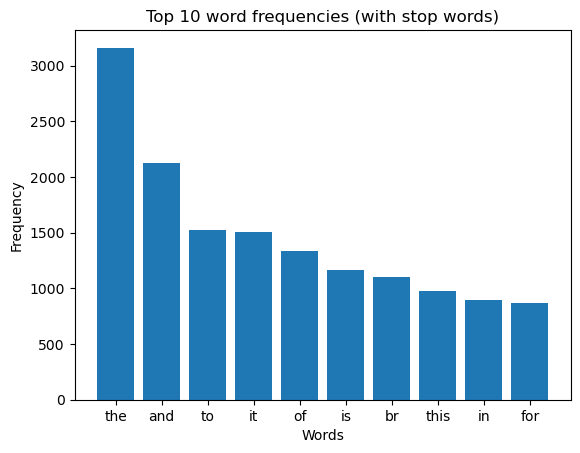

NameError: name 'top_words_without_stopwords' is not defined

<Figure size 640x480 with 0 Axes>

In [18]:
import matplotlib.pyplot as plt
# Plot the frequencies with stop words
plt.bar(top_words_with_stopwords, top_counts_with_stopwords)
plt.title("Top 10 word frequencies (with stop words)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

# Plot the frequencies without stop words
plt.figure()
plt.bar(top_words_without_stopwords, top_counts_without_stopwords)
plt.title("Top 10 word frequencies (without stop words)")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

### TF-IDF vectorization

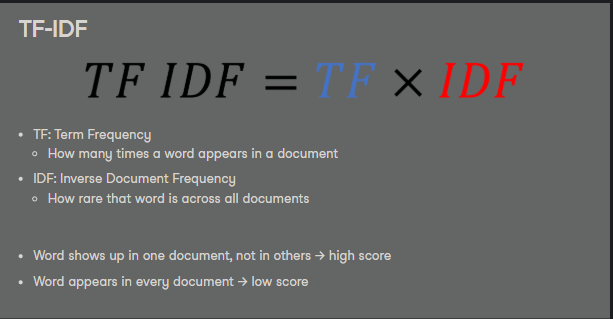

In [19]:
print(reviews)

['The product is fantastic! It works like a charm.', 'I hated the product. It broke after one use.', 'Product was okay, not the best, but fine overall.']


In [20]:
cleaned_reviews = [preprocess(review) for review in reviews]
print(cleaned_reviews)

NameError: name 'stop_words' is not defined

In [21]:
# TF-IDF with code
from sklearn.feature_extraction.text import TfidfTransformer
vectorizer = TfidfTransformer()
tfidf_matrix = vectorizer.fit_transform(cleaned_reviews)

ValueError: Expected 2D array, got 1D array instead:
array=['i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it smells better my labrador is finicky and she appreciates this product better than most'
 "product arrived labeled as jumbo salted peanuts ... the peanuts were actually small sized unsalted not sure if this was an error or if the vendor intended to represent the product as `` jumbo ''"
 "this is a confection that has been around a few centuries it is a light pillowy citrus gelatin with nuts in this case filberts and it is cut into tiny squares and then liberally coated with powdered sugar and it is a tiny mouthful of heaven not too chewy and very flavorful i highly recommend this yummy treat if you are familiar with the story of c.s lewis `` the lion the witch and the wardrobe '' this is the treat that seduces edmund into selling out his brother and sisters

In [22]:
print(tfidf_matrix.toarray())

NameError: name 'tfidf_matrix' is not defined

In [23]:
vectorizer.get_feature_names_out()

NotFittedError: This TfidfTransformer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

#### Visualizing scores as heatmap

In [ ]:
import pandas as pd

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df_tfidf, annot=True)
plt.title("TF-IDF Scores Across Reviews")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()

### TF-IDF representation of product feedback

In [24]:
from sklearn.feature_extraction.text import TfidfTransformer
reviews = ["The smart speaker is incredible. Clear sound and fast responses!",
           "I am disappointed with the smart bulb. It stopped working in a week.",
           "The thermostat is okay. Not too smart, but functional."]
cleaned_reviews = [preprocess(review) for review in reviews]

# Initialize the vectorizer
vectorizer = TfidfVectorizer()
# Transform the cleaned reviews
tfidf_matrix = vectorizer.fit_transform(cleaned_reviews)
# Create a DataFrame for TF-IDF
df = pd.DataFrame(
  tfidf_matrix.toarray(),
  columns=vectorizer.get_feature_names_out()
)
print(df.head())

NameError: name 'stop_words' is not defined